## Исследование датасета для проекта «Ценообразование жилой недвижимости с использованием методов машинного обучения на данных ЦИАН»

In [253]:
try:
    import gdown
except ImportError:
    !pip install gdown
    import gdown

import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns

from geopy.distance import geodesic
from IPython.display import Image, display
from scipy import stats
from matplotlib.patches import Patch

## Выводы



### 0. Приведите описание данных. Какие признаки количественные, категориальные, номинальные?


* **Количественные признаки:**
  - *price* (целевая переменная) — цена объекта
  - *total_area* – общая площадь
  - *living_area* – жилая площадь
  - *kitchen_area* – площадь кухни
  - *ceiling_height* – высота потолков
  - *floor* – этаж
  - *total_floors* – общее количество этажей
  - *combined_bathroom* – кол-во совмещенных санузлов
  - *separated_bathroom* – кол-во раздельных санузлов
  - *loggia_balcony* – кол-во балконов/лоджий
  - *year_of_construction* – год постройки `только для вторичек`
  - *passenger_elevator* – кол-во пассажирских лифтов
  - *cargo_elevator* – кол-во грузовых лифтов
  - *entrances* – количество подъездов `только для вторичек`
  - *fastest_minutes* - время до метро в минутах `только для вторичек`
  - *stations_nearby* - количество станций поблизости
  - *distance_from_mkad* - расстояние до мкад `только для вторичек`
  - *roads_nearby_count* - количество дорог поблизости

* **Категориальные признаки:**
  - *house_type* — тип дома (Блочный/Деревянный/Кирпичный/Монолитно-кирпичный/Монолитный/Панельный/Сталинский/NaN)
  - *view_from_the_windows* — вид из окна (Во двор/На улицу/На улицу и двор/NaN)
  - *repair* — ремонт (Без ремонта/Дизайнерский/Евроремонт/Косметический/NaN) `только для вторичек`
  - *heating* — отопление (Автономная котельная/Индивидуальный тепловой пункт/(Котел/Квартирное отопление)/Нет/Нет информации/Центральное/Электрическое/NaN) `только для вторичек`
  - *parking* — парковка (Многоуровневая/На крыше/Наземная/Открытая/Подземная/NaN)
  - *gas_supply* — газоснабжение (Автономное/Центральное/NaN) `только для вторичек`
  - *apartment* — Апартаменты/Пентхаус/NaN
  - *floor_type* — тип перекрытий (Деревянные/Железобетонные/Смешанные/NaN) `только для вторичек`
  - *finishing* — тип отделки (Без отделки/Нет информации/Под ключ/Предчистовая/С отделкой/Черновая/Чистовая/Чистовая с мебелью/NaN) `только для новостроек`
  - *rooms_count* — формально числовой, но содержит значения "Студия", "Доля", поэтому пока считаем категориальным.
  - *okrug* — округ Москвы (ЦАО, ЗАО, СЗАО, САО, СВАО, ВАО, ЮВАО, ЮАО, ЮЗАО, НАО)
  - *district* - район Москвы ('р-н даниловский', 'р-н головинский', nan, 'р-н некрасовка' и т.д.)
  - *metro_adress* - ближайшее метро ('серебряный бор', 'петровский парк', 'дмитровская' и т.д.) `только для вторичек`
  - *nearest_station* - ближайшее метро ('серебряный бор', 'петровский парк', 'дмитровская' и т.д.) `только для вторичек`
  - *seller_type* - продавец (None, 'агентство недвижимости', 'автор объявления', 'застройщик','собственник', 'консультант', 'представитель застройщика', 'управляющая компания') `только для новостроек`
  - *seller_name* - имя продавца (None, 'ордер', 'id 135186715', ..., 'ирина иванова', 'new day realty', 'владислав дворов'') `только для новостроек`
  - *fastest_mode* - как можно добраться до метро ('пешком', None, 'на машине') `только для вторичек`
  - *nearest_road* - ближайшее шоссе ('калужское шоссе', 'косинское шоссе', 'варшавское шоссе') `только для вторичек`

* **Бинарные признаки:**
  - *auction* — аукцион? (в датасете только "Н")
  - *new_biilding* — тип квартиры (Новостройка/Вторичка)
  - *garbage_chute* — мусоропровод (Д/NaN)
  - *concierge* — консьерж (Д/NaN)
  - *accident_rate* — аварийность (Д/Н/NaN) `только для вторичек`
  - *sold_with_furniture* — продается вместе с мебелью (Д/NaN) `только для вторичек`
  - *minor_owners* — несовершеннолетние собственники (Д/Н/NaN)
  - *maternity_capital* — использовался ли маткапитал при покупке (Д/Н/NaN)
  - *ramp* — пандус (Д/NaN) `только для новостроек`
  - *nearest_station_open* - открыта ли ближайшая станция метро (да/нет)

* **Дата и время:**
  - *publication_date* — дата публикации объявления
  - *request_time* — дата парсинга данных объявления

* **Геоданные:**
  - *lat* — широта
  - *lng* — долгота

* **Текстовые (смешанные) данные:**
  - *url* — url объявления
  - *address* — полный адрес объекта
  - *construction_series* — строительная серия `только для вторичек`
  - *metro_info* — информация о ближайших метро (возможно, имеет смысл вычленить только ближайшее метро и время до него, в списке стоит первым)
  - *highway_info* — информация о ближайших дорогах `только для вторичек`
  - *description* — описание объекта, которое заполняется продавцом
  - *seller* — застройщик `только для новостроек`
  - *photos_url* — 15 ссылок на фотографии из объявлений

### 1. Есть ли пропуски в данных? Какой процент они составляют от числа строк? Почему они могли появиться? Если есть пропуски, выберите способ обработки пропусков для каждого столбца. Расскажите, почему выбрали именно этот способ. Обработайте пропуски.

Помимо табличек есть картиночки, которые можно глянуть запустив код  
Таблица распределения пропусков по типам признаков  
**ДО ОБРАБОТКИ**
| Уровень пропусков | Количественные признаки | Категориальные признаки | Бинарные признаки | Текстовые данные | Дата/время |
|-------------------|-------------------------|-------------------------|-------------------|------------------|------------|
| **Очень высокий (>80%)** |`loggia` (81.4%)<br><br>`balcony` (81.2%) | `apartment` (88.4%)| `concierge` (98.7%)<br><br>`minor_owners` (97.1%)<br><br>`maternity_capital` (97.1%)<br><br>`ramp` (86.9%)<br><br>`garbage_chute` (82.3%) | `highway_info` (84.4%) | - |
| **Высокий (40-80%)** | `separated_bathroom` (68.5%)<br><br>`cargo_elevator` (48.9%)<br><br>`combined_bathroom` (42.9%) |`gas_supply` (79.0%)<br><br>`view_from_the_windows` (43.5%)| `sold_with_furniture` (64.4%) | - | - |
| **Средний (20-40%)** | `passenger_elevator` (29.5%)<br><br>`entrances` (28.5%)<br><br>`living_area` (24.3%)<br><br>`ceiling_height` (21.3%) | `floor_type` (38.4%)<br><br> `parking` (30.9%)<br><br> `finishing` (30.7%) | - | `construction_series` (37.0%) | - |
| **Низкий (1-20%)** | `kitchen_area` (18.4%)<br><br>`year_of_construction` (12.3%) | `house_type` (18.5%)<br><br>`heating` (12.2%)<br><br>`repair` (5.8%) | `accident_rate` (12.2%) | `photos_url` (3.7%)<br><br> `metro_info` (0.8%)<br><br> `seller` (0.1%)| - |
| **Без пропусков (0%)** | `price`<br><br>`station_nearby`<br><br>`roads_nearby_count`<br><br>`lat` (геоданные)<br><br>`lng` (геоданные)<br><br>`total_floors`<br><br>`floor`<br><br>`total_area` | `rooms_count` | `new_building`<br><br>`auction`<br><br> | `address`<br><br>`description`<br><br>`url` | `request_time`<br><br>`publication_date` |

**ПОСЛЕ ОБРАБОТКИ**

| Уровень пропусков | Количественные признаки | Категориальные признаки | Бинарные признаки | Текстовые данные | Дата/время |
|-------------------|-------------------------|-------------------------|-------------------|------------------|------------|
| **Очень высокий (>80%)** |- | - | - | - | - |
| **Высокий (40-80%)** | `loggia_balcony` (42.2%) |`view_from_the_windows` (44.0%)| - | - | - |
| **Средний (20-40%)** | `entrances` (28.6%) | `floor_type` (38.1%)<br><br>  `finishing` (31.1%) | - | `construction_series` (37.0%) | - |
| **Низкий (1-20%)** | `cargo_elevator` (19.7%)<br><br>`ceiling_height` (16.4%) | `parking` (16.1%)<br><br>`house_type` (15.7%) | - | `photos_url` (3.7%)| - |
| **Без пропусков (0%)** | `kitchen_area`<br><br>`living_area`<br><br>`total_area`<br><br>`separated_bathroom`<br><br> `combined_bathroom`<br><br>`passenger_elevator`<br><br>`price`<br><br>`station_nearby`<br><br>`roads_nearby_count`<br><br>`lat` (геоданные)<br><br>`lng` (геоданные)<br><br>`total_floors`<br><br>`floor`<br><br>`year_of_construction` | `rooms_count`<br><br>`apartment_newbuilding`<br><br>`heating`<br><br>`repair`| `new_building`<br><br>`auction`<br><br> `accident_rate` | `address`<br><br>`description`<br><br>`url`<br><br> `seller` | `request_time`<br><br>`publication_date` |

Пропуски в данных объясняются предметной областью. В объявлениях обязательным параметрами являются: адрес, цена, площадь, этаж. Остальные параметры не обязательны для заполнения

В ходе обработки пропусков были использованы следующие стратегии, последовательно
1. Чуток убрали явные выбросы, которые составляли менее 5% от всех записей
2. Здравый смысл: в комбинации с несколькими параметрами заполняется целевой, - нормативные акты, сан.правила. Например, для домов этажностью 6-9 обязателен один пассажирский лифт
3. Признаки с пропусками >= 50% - удаляем
4. Для каждого признака внутри группы определяется % пропуска, если он <= 15%, то пропуск группы заменяется на внутригруппы медиану/моду, в зависимости от типа признака

Т.о. удалось значительно уменьшить объем пропущенных значений:
- были удалены следующие колонки: `gas_supply`, `sold_with_furniture`, `ramp`, `garbage_chute`, `concierge`, `minor_owners`, `maternity_capital`
- колонки `loggia`, `balcony` были просуммированны в одну колонку `loggia_balcony`. Исходные колонки удалены
- колонка `apartment` была слита с колонкой `new_building` в одну колонку `apartment_newbuilding`. Исходная колонка `apartment` была удалена
- остальные признаки удалось снизить по уровню пропусков на 1-2 lvl  

**ОДИН ПРИЗНАК НЕ УБИРАЛИ**  
**highway_info** имеет заполненное значение всего в 5тыс.строк, но нам кажется этот признак интересным и полезным. Его можно отдельно пропробовать использовать в ml

### 2. Соответствуют ли типы данных в датасете тем, которые нужны (например, есть ли возраст в формате строки)? Исправьте это, если да.

В целом данные соответствовали, однако 4 признака было решено форматировать в другие

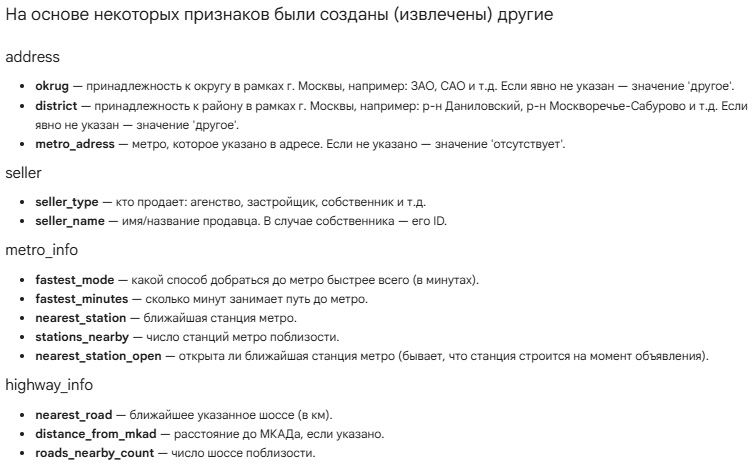

### 3. Посчитайте описательные статистики по всем переменным.

Графики с распределениями и боксплотами есть в коде

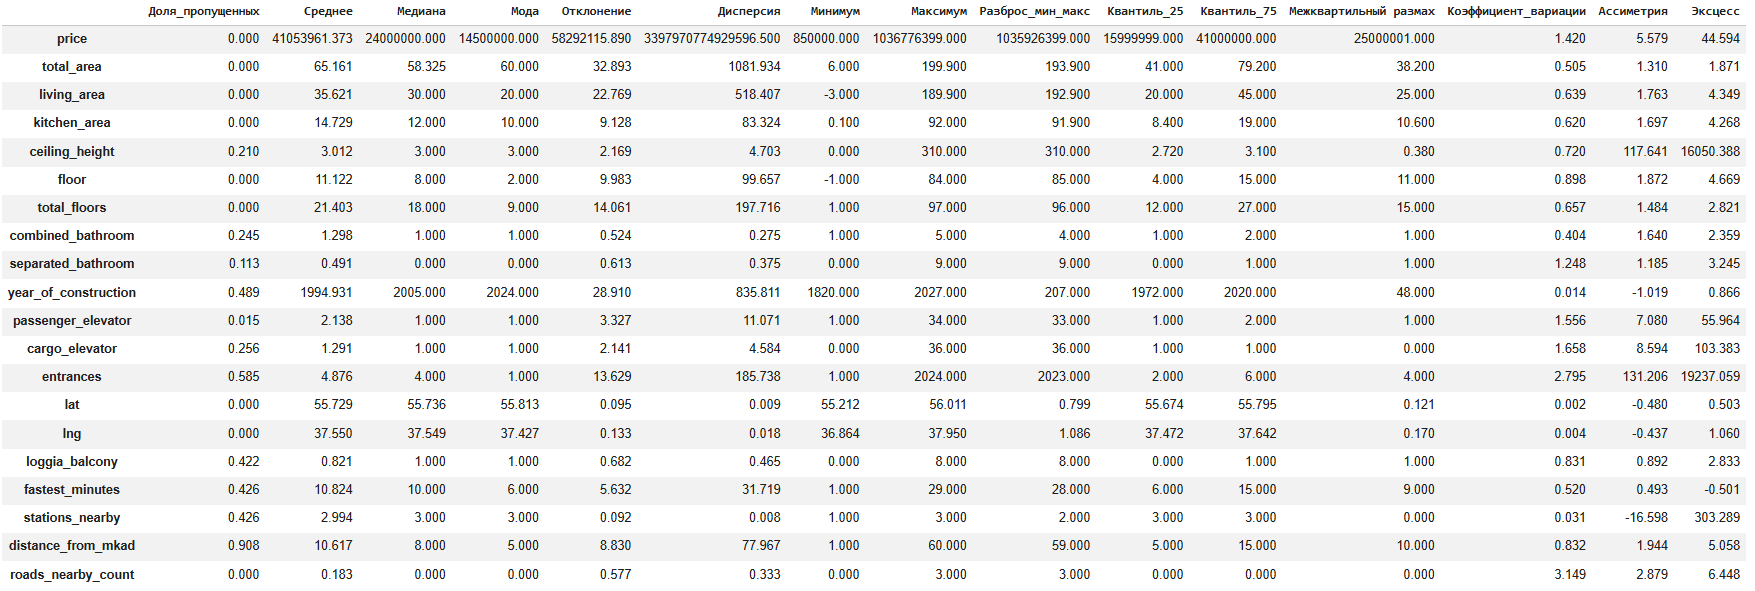

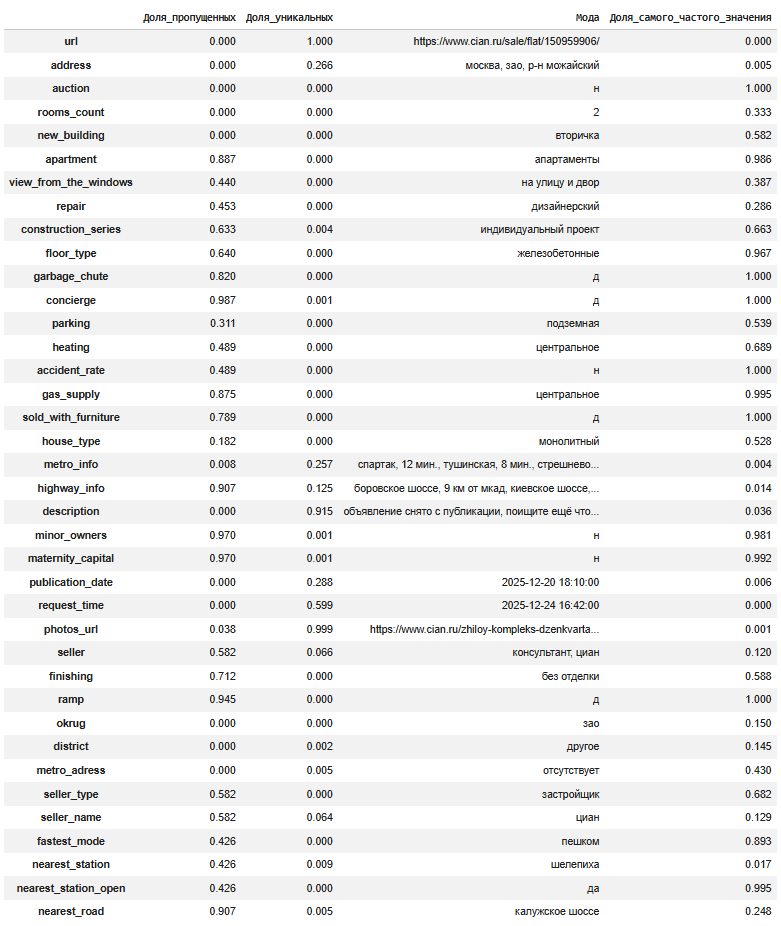

### 4. Изучите каждый признак. Какие значения он принимает?

Для числовых признаков:

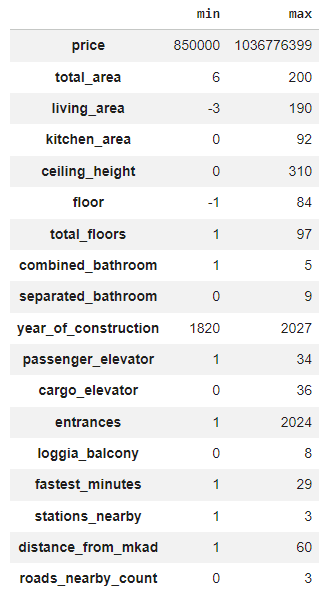

Для категориальных (количество уникальных значений):

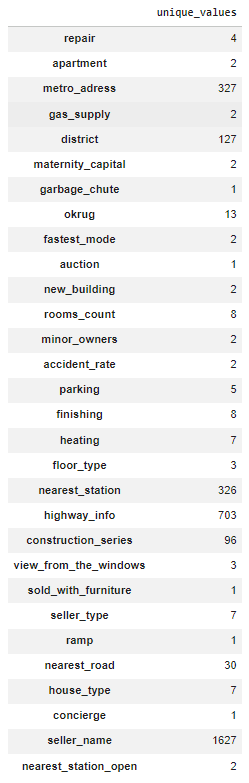

### 5. Есть ли в данных выбросы или ошибки (например, отрицательная цена)? Как вы их определяете? Обработайте выбросы.

Фильтры категориальных и числовых признаков подбирались опытным путём, глядя на боксплоты признаков (ч. Андрей) и барчарты (ч.Насти)

Итого:

Оригинальный размер датасета: (63365, 46)  
Размер датасета после среза по Percentile: (\~57000,52)  
В результате обработки выбросов размер итогового датасета: (\~28000,52)  
Процент отсечённых данных (относительно оригинального датасета): \~53%  

### 6. Постройте матрицу корреляций числовых переменных.

Со всей корреляционной матрицей можно ознакомиться в коде
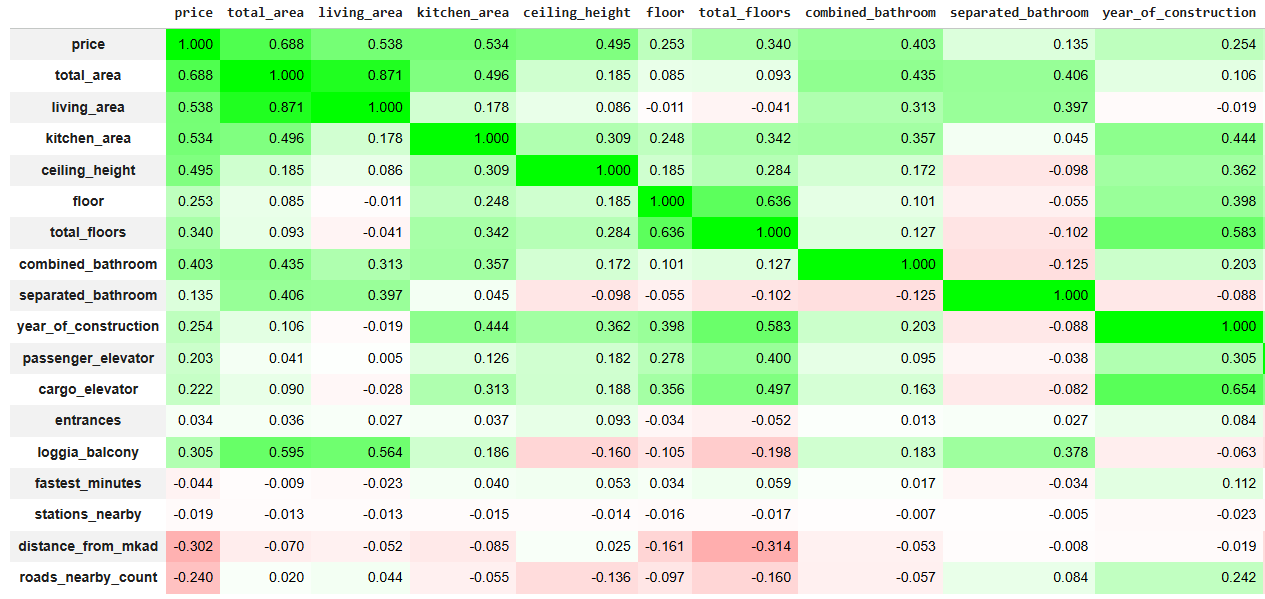

Корреляция переменных с целевой (price):  
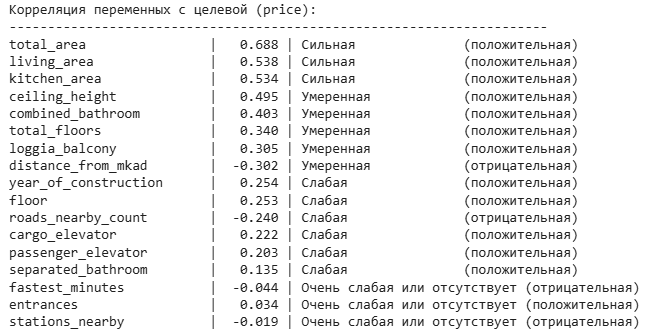


Сильная корреляция — от 0.5 до 0.7 (по модулю)  
Умеренная корреляция — от 0.3 до 0.5 (по модулю)  
Слабая корреляция — от 0.1 до 0.3 (по модулю)

---
Стоит отметить `total_area`, `living_area` **мультиколлинеарны**, у них сильная взаимосвязь (>0.8), что может негативно влиять на обучение модели  
Мультиколлинеарность легко объясняется природой данных: чем больше общая площадь, тем больше в ней будет жилая площадь

Нужно будет оставить более сильный предиктор - `total_area`


### 7. Визуализируйте данные (например, с помощью matplotlib и seaborn).

Судя по графикам распределения числовых признаков выбросы, на сколько разумно и возможно, убраны, что не оказывает сильного воздействия на корреляцию параметров

---
Скеттерплот использовать напрямую не очень информативно, т.к. записей очень много и получается огромное облако точек. В целом направления корреляции угадывается и соответсвует корр.матрице

---
В категориальных признаках выбросы тоже отсутсвуют, хотя `многоуровневый паркинг` имеет небольшое количество записей, но пока оставим

In [254]:
#распределение
display(Image('/content/distributions_histograms.png'))

FileNotFoundError: No such file or directory: '/content/distributions_histograms.png'

FileNotFoundError: No such file or directory: '/content/distributions_histograms.png'

<IPython.core.display.Image object>

In [255]:
#скеттерплот
display(Image('/content/scatter_matrix.png'))

FileNotFoundError: No such file or directory: '/content/scatter_matrix.png'

FileNotFoundError: No such file or directory: '/content/scatter_matrix.png'

<IPython.core.display.Image object>

In [256]:
#категориальные переменные
display(Image('/content/category.png'))

FileNotFoundError: No such file or directory: '/content/category.png'

FileNotFoundError: No such file or directory: '/content/category.png'

<IPython.core.display.Image object>

### 8. По возможности попробуйте задать какие-нибудь вопросы и ответить на них, используя ваши данные. Постройте необходимые сводные таблицы и графики.

### 9. Сделайте развернутые выводы.

### 10. Обогащение датасета (добавление новых признаков) – по результатам EDA, при необходимости

Добавлен признак distance_from_center - расстояние в км между квартирой и центром Москвы, корреляция с ценой порядка 0.28

## Начало работы

In [257]:
pd.set_option('display.max_columns', None)

In [258]:
#при запуске в первый раз скачает файл в директорию этого ноутбука
#файл слишком большой, поэтому при попытке открытия его просто по ссылке гугл выдает ошибку
#поэтому нужна доп библиотека down

link = 'https://drive.google.com/uc?id=1TgqL2u4rpwNORJ1yhjam9eVzl5-tTM5l'
output_file = 'cian_full_data.csv'

if not os.path.exists(output_file):
    gdown.download(link, output_file, quiet=False, fuzzy=True)

df = pd.read_csv(output_file, low_memory=False, encoding='utf-8-sig', sep=';')

df.head(1)

Downloading...
From (original): https://drive.google.com/uc?id=1TgqL2u4rpwNORJ1yhjam9eVzl5-tTM5l
From (redirected): https://drive.google.com/uc?id=1TgqL2u4rpwNORJ1yhjam9eVzl5-tTM5l&confirm=t&uuid=03f9a99c-280d-4855-85ae-561e0f5fa153
To: c:\Users\Никита\Desktop\Study\ВШЭ\course_project_1\proj_github\Abd_prj_25_26_team_40\cian_full_data.csv
100%|██████████| 241M/241M [00:09<00:00, 24.3MB/s] 


,url,address,price,auction,rooms_count,new_building,apartment,total_area,living_area,kitchen_area,ceiling_height,floor,total_floors,combined_bathroom,separated_bathroom,balcony,loggia,view_from_the_windows,repair,year_of_construction,construction_series,passenger_elevator,cargo_elevator,floor_type,entrances,garbage_chute,concierge,parking,heating,accident_rate,gas_supply,sold_with_furniture,house_type,metro_info,highway_info,description,lat,lng,minor_owners,maternity_capital,publication_date,request_time,photos_url,seller,finishing,ramp
0,https://www.cian.ru/sale/flat/324994191/,"Москва, ЮАО, р-н Даниловский, м. Автозаводская...",5350000,Н,Студия,Вторичка,Апартаменты,16,10,5,3,4,5,NaN,1,NaN,NaN,Во двор,Евроремонт,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Д,Кирпичный,"Автозаводская 5 мин. (пешком), ЗИЛ 9 мин. (пеш...",NaN,АПАРТАМЕНТЫ:\nПродаётся светлая и аккуратная с...,56,38,Н,Н,2025-12-19 12:29:00,2025-12-20 03:40:29,https://images.cdn-cian.ru/images/kvartira-mos...,NaN,NaN,NaN


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63365 entries, 0 to 63364
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   url                    63365 non-null  object 
 1   address                63365 non-null  object 
 2   price                  63365 non-null  int64  
 3   auction                63365 non-null  object 
 4   rooms_count            63365 non-null  object 
 5   new_building           63365 non-null  object 
 6   apartment              7367 non-null   object 
 7   total_area             63365 non-null  float64
 8   living_area            47957 non-null  float64
 9   kitchen_area           51724 non-null  float64
 10  ceiling_height         49867 non-null  float64
 11  floor                  63365 non-null  int64  
 12  total_floors           63365 non-null  int64  
 13  combined_bathroom      36205 non-null  float64
 14  separated_bathroom     19966 non-null  float64
 15  ba

# Алия

### Описание данных

Сюда также добавлены признаки, которые появлялись в ходе EDA


* **Количественные признаки:**
  - *price* (целевая переменная) — цена объекта
  - *total_area* – общая площадь
  - *living_area* – жилая площадь
  - *kitchen_area* – площадь кухни
  - *ceiling_height* – высота потолков
  - *floor* – этаж
  - *total_floors* – общее количество этажей
  - *combined_bathroom* – кол-во совмещенных санузлов
  - *separated_bathroom* – кол-во раздельных санузлов
  - *loggia_balcony* – кол-во балконов/лоджий
  - *year_of_construction* – год постройки `только для вторичек`
  - *passenger_elevator* – кол-во пассажирских лифтов
  - *cargo_elevator* – кол-во грузовых лифтов
  - *entrances* – количество подъездов `только для вторичек`
  - *fastest_minutes* - время до метро в минутах `только для вторичек`
  - *stations_nearby* - количество станций поблизости
  - *distance_from_mkad* - расстояние до мкад `только для вторичек`
  - *roads_nearby_count* - количество дорог поблизости

* **Категориальные признаки:**
  - *house_type* — тип дома (Блочный/Деревянный/Кирпичный/Монолитно-кирпичный/Монолитный/Панельный/Сталинский/NaN)
  - *view_from_the_windows* — вид из окна (Во двор/На улицу/На улицу и двор/NaN)
  - *repair* — ремонт (Без ремонта/Дизайнерский/Евроремонт/Косметический/NaN) `только для вторичек`
  - *heating* — отопление (Автономная котельная/Индивидуальный тепловой пункт/(Котел/Квартирное отопление)/Нет/Нет информации/Центральное/Электрическое/NaN) `только для вторичек`
  - *parking* — парковка (Многоуровневая/На крыше/Наземная/Открытая/Подземная/NaN)
  - *gas_supply* — газоснабжение (Автономное/Центральное/NaN) `только для вторичек`
  - *apartment* — Апартаменты/Пентхаус/NaN
  - *floor_type* — тип перекрытий (Деревянные/Железобетонные/Смешанные/NaN) `только для вторичек`
  - *finishing* — тип отделки (Без отделки/Нет информации/Под ключ/Предчистовая/С отделкой/Черновая/Чистовая/Чистовая с мебелью/NaN) `только для новостроек`
  - *rooms_count* — формально числовой, но содержит значения "Студия", "Доля", поэтому пока считаем категориальным.
  - *okrug* — округ Москвы (ЦАО, ЗАО, СЗАО, САО, СВАО, ВАО, ЮВАО, ЮАО, ЮЗАО, НАО)
  - *district* - район Москвы ('р-н даниловский', 'р-н головинский', nan, 'р-н некрасовка' и т.д.)
  - *metro_adress* - ближайшее метро ('серебряный бор', 'петровский парк', 'дмитровская' и т.д.) `только для вторичек`
  - *nearest_station* - ближайшее метро ('серебряный бор', 'петровский парк', 'дмитровская' и т.д.) `только для вторичек`
  - *seller_type* - продавец (None, 'агентство недвижимости', 'автор объявления', 'застройщик','собственник', 'консультант', 'представитель застройщика', 'управляющая компания') `только для новостроек`
  - *seller_name* - имя продавца (None, 'ордер', 'id 135186715', ..., 'ирина иванова', 'new day realty', 'владислав дворов'') `только для новостроек`
  - *fastest_mode* - как можно добраться до метро ('пешком', None, 'на машине') `только для вторичек`
  - *nearest_road* - ближайшее шоссе ('калужское шоссе', 'косинское шоссе', 'варшавское шоссе') `только для вторичек`

* **Бинарные признаки:**
  - *auction* — аукцион? (в датасете только "Н")
  - *new_biilding* — тип квартиры (Новостройка/Вторичка)
  - *garbage_chute* — мусоропровод (Д/NaN)
  - *concierge* — консьерж (Д/NaN)
  - *accident_rate* — аварийность (Д/Н/NaN) `только для вторичек`
  - *sold_with_furniture* — продается вместе с мебелью (Д/NaN) `только для вторичек`
  - *minor_owners* — несовершеннолетние собственники (Д/Н/NaN)
  - *maternity_capital* — использовался ли маткапитал при покупке (Д/Н/NaN)
  - *ramp* — пандус (Д/NaN) `только для новостроек`
  - *nearest_station_open* - открыта ли ближайшая станция метро (да/нет)

* **Дата и время:**
  - *publication_date* — дата публикации объявления
  - *request_time* — дата парсинга данных объявления

* **Геоданные:**
  - *lat* — широта
  - *lng* — долгота

* **Текстовые (смешанные) данные:**
  - *url* — url объявления
  - *address* — полный адрес объекта
  - *construction_series* — строительная серия `только для вторичек`
  - *metro_info* — информация о ближайших метро (возможно, имеет смысл вычленить только ближайшее метро и время до него, в списке стоит первым)
  - *highway_info* — информация о ближайших дорогах `только для вторичек`
  - *description* — описание объекта, которое заполняется продавцом
  - *seller* — застройщик `только для новостроек`
  - *photos_url* — 15 ссылок на фотографии из объявлений

# Настя

### Изучение пропусков

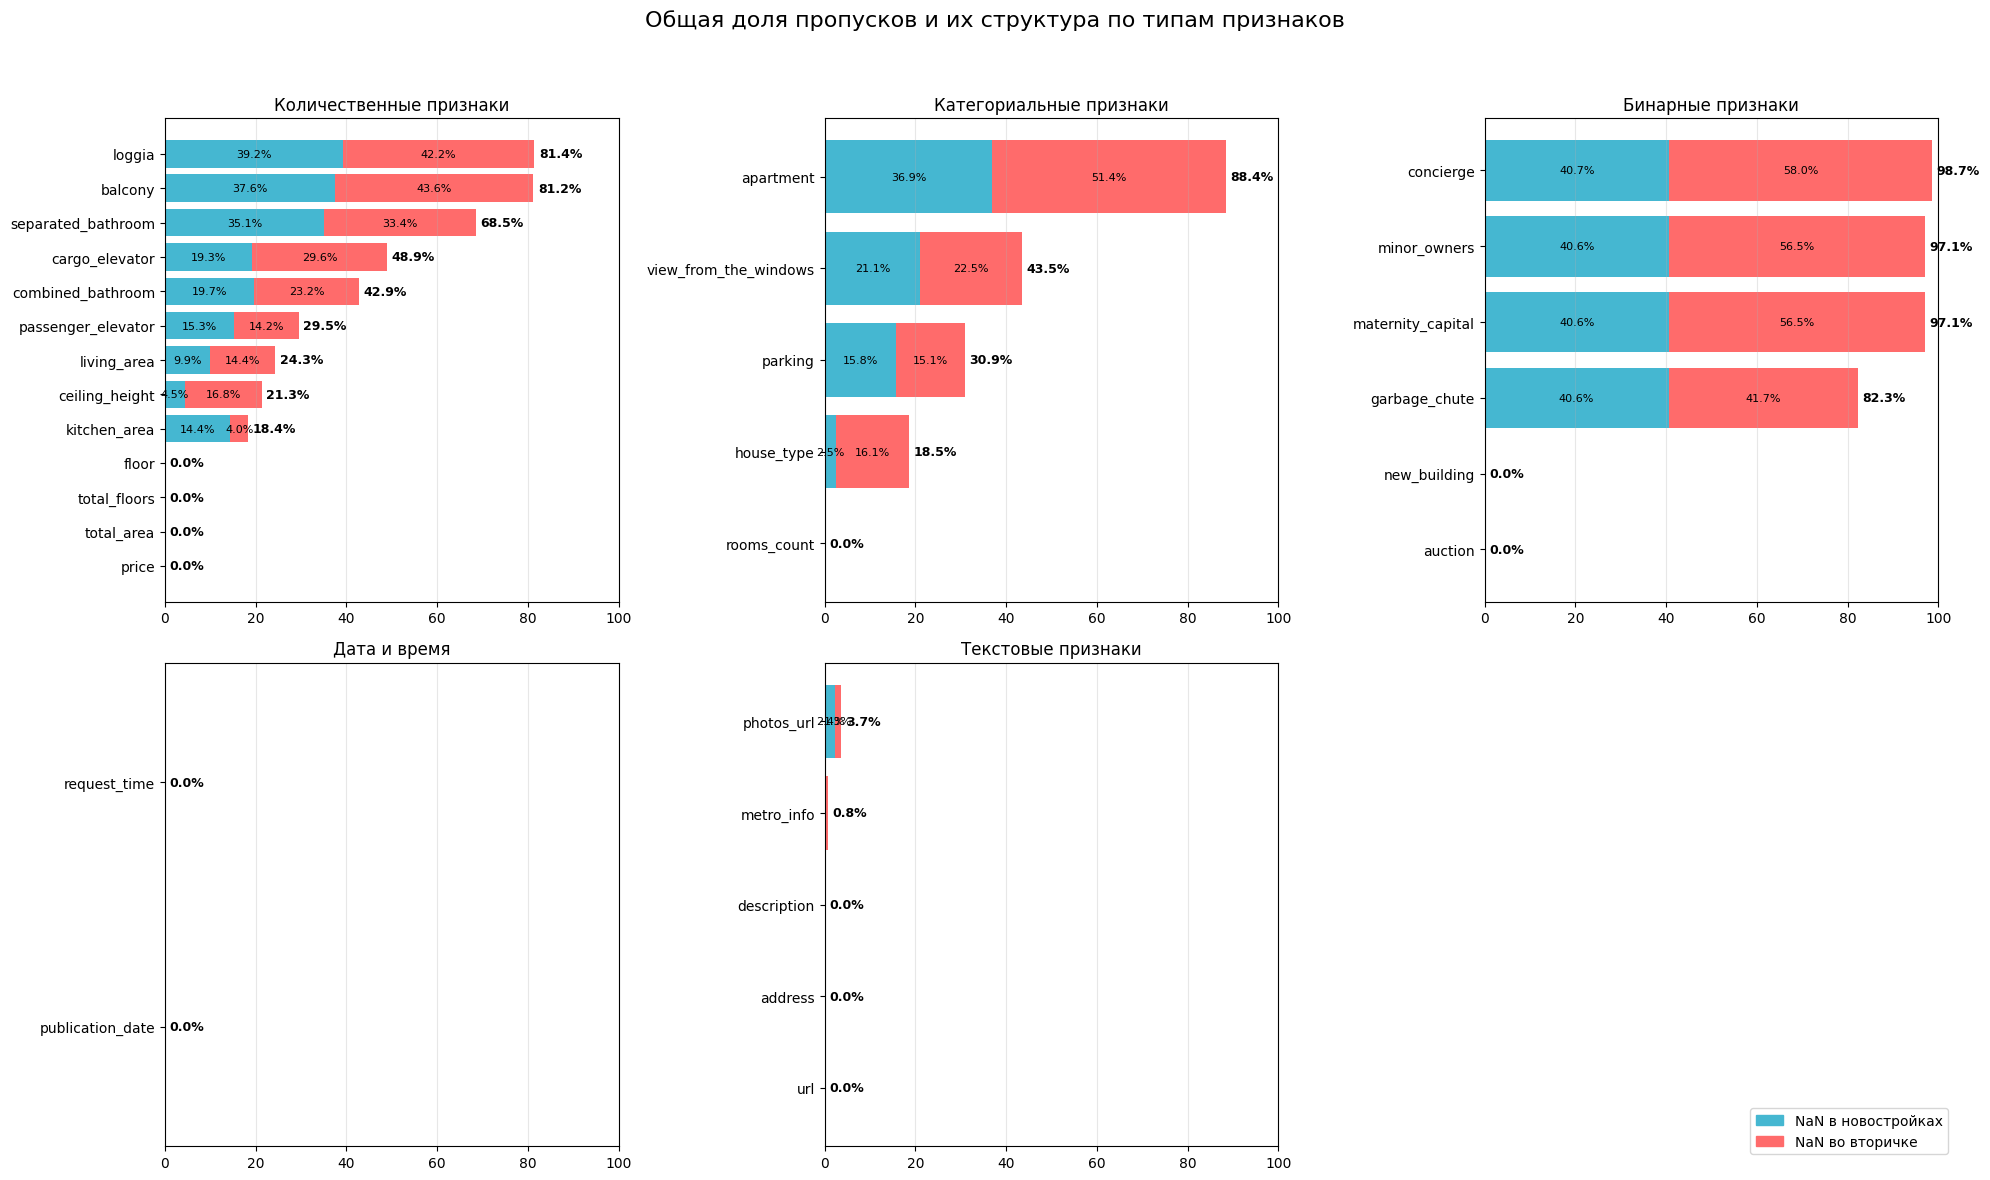

In [260]:
only_new = df['new_building'] == 'Новостройка'
only_sec = df['new_building'] == 'Вторичка'
n_total = len(df)

# Создаем словарь для классификации признаков
quantitative = [
    'price', 'total_area', 'living_area', 'kitchen_area', 'ceiling_height',
    'floor', 'total_floors', 'combined_bathroom', 'separated_bathroom',
    'passenger_elevator', 'loggia', 'balcony', 'cargo_elevator'
]

categorical = [
    'house_type', 'view_from_the_windows', 'parking',
    'apartment', 'rooms_count'
]

binary = [
    'auction', 'new_building', 'garbage_chute', 'concierge',
    'minor_owners', 'maternity_capital'
]

datetime = ['publication_date', 'request_time']

geodata = ['lat', 'lng']

text = [
    'url', 'address',
    'description', 'photos_url','metro_info'
]

# --- функция подготовки данных ---
def prepare_stacked_nan_data(feature_list):
    rows = []

    for col in feature_list:
        nan_new = df.loc[only_new, col].isna().sum() / n_total * 100
        nan_sec = df.loc[only_sec, col].isna().sum() / n_total * 100

        rows.append({
            'Column': col,
            'NaN_new': nan_new,
            'NaN_sec': nan_sec,
            'Total_NaN': nan_new + nan_sec
        })

    return (
        pd.DataFrame(rows)
        .sort_values('Total_NaN', ascending=True)
    )

# --- данные по типам признаков ---
data_quantitative = prepare_stacked_nan_data(quantitative)
data_categorical = prepare_stacked_nan_data(categorical)
data_binary = prepare_stacked_nan_data(binary)
data_datetime = prepare_stacked_nan_data(datetime)
data_text = prepare_stacked_nan_data(text)

# --- функция построения одного графика ---
def plot_stacked_bars(ax, data, title):
    if data.empty:
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center')
        ax.set_title(title)
        return

    bars_new = ax.barh(
        data['Column'],
        data['NaN_new'],
        color='#45B7D1',
        label='NaN в новостройках'
    )

    bars_sec = ax.barh(
        data['Column'],
        data['NaN_sec'],
        left=data['NaN_new'],
        color='#FF6B6B',
        label='NaN во вторичке'
    )

    for _, row in data.iterrows():
        if row['NaN_new'] > 1:
            ax.text(
                row['NaN_new'] / 2,
                row['Column'],
                f"{row['NaN_new']:.1f}%",
                va='center',
                ha='center',
                fontsize=8
            )

        if row['NaN_sec'] > 1:
            ax.text(
                row['NaN_new'] + row['NaN_sec'] / 2,
                row['Column'],
                f"{row['NaN_sec']:.1f}%",
                va='center',
                ha='center',
                fontsize=8
            )

        ax.text(
            row['Total_NaN'] + 1,
            row['Column'],
            f"{row['Total_NaN']:.1f}%",
            va='center',
            ha='left',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_xlim(0, 100)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)


# --- сетка сабплотов ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

plot_stacked_bars(axes[0], data_quantitative, 'Количественные признаки')
plot_stacked_bars(axes[1], data_categorical, 'Категориальные признаки')
plot_stacked_bars(axes[2], data_binary, 'Бинарные признаки')
plot_stacked_bars(axes[3], data_datetime, 'Дата и время')
plot_stacked_bars(axes[4], data_text, 'Текстовые признаки')

axes[5].axis('off')

# общая легенда
handles = [
    plt.Rectangle((0, 0), 1, 1, color='#45B7D1'),
    plt.Rectangle((0, 0), 1, 1, color='#FF6B6B')
]

labels = ['NaN в новостройках', 'NaN во вторичке']

fig.legend(
    handles,
    labels,
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    frameon=True
)

plt.suptitle(
    'Общая доля пропусков и их структура по типам признаков',
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

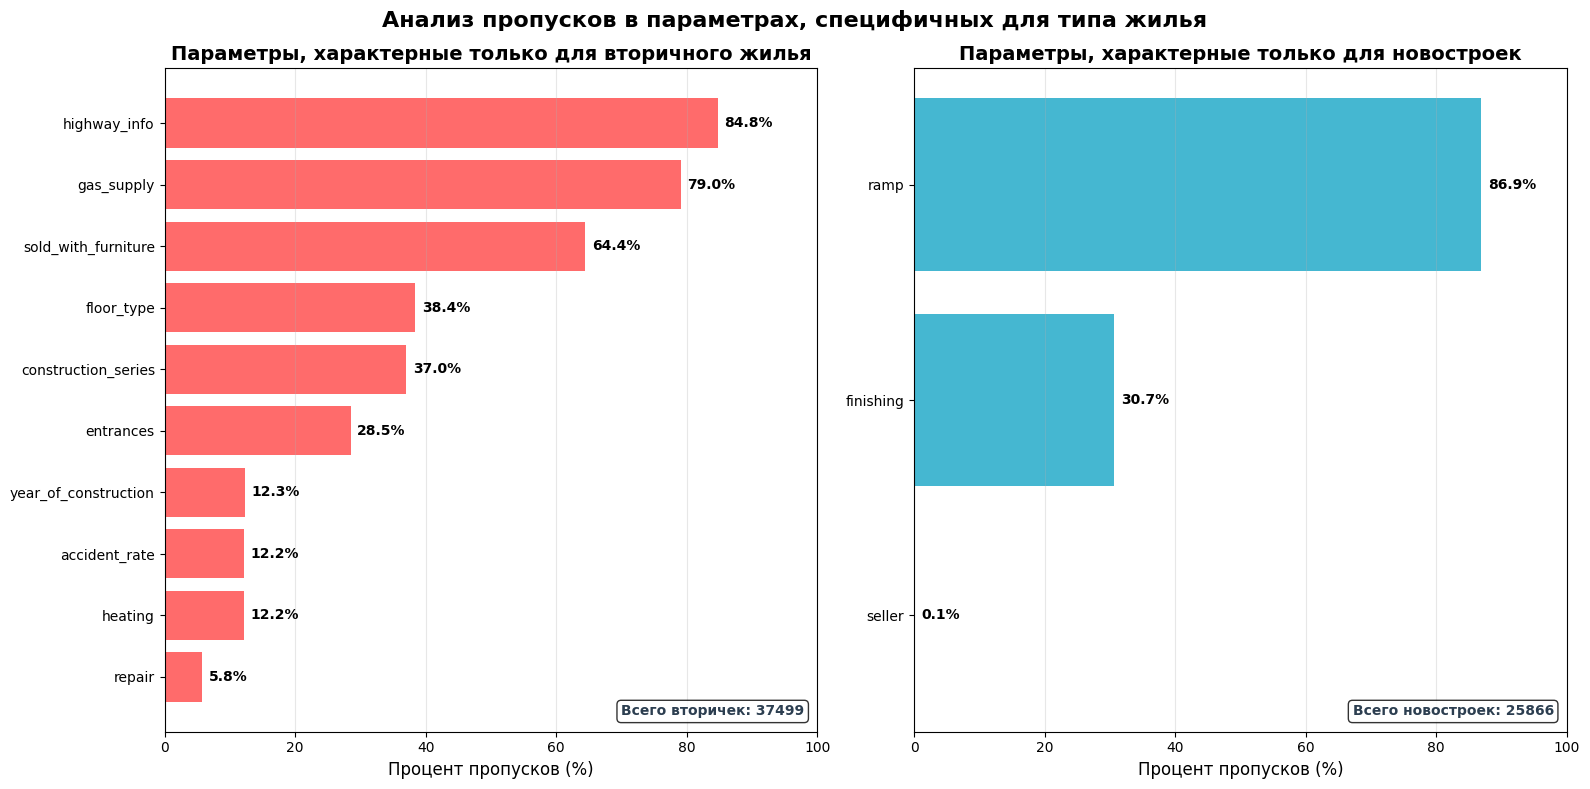

In [261]:
# Фильтры для новостроек и вторичек
only_new = df['new_building'] == 'Новостройка'
only_sec = df['new_building'] == 'Вторичка'

n_new = len(df[only_new])  # Количество новостроек
n_sec = len(df[only_sec])  # Количество вторичек

# --- Параметры для вторичек (как в прошлом графике) ---
params_secondary_only = [
    'year_of_construction',
    'entrances',
    'repair',
    'heating',
    'gas_supply',
    'floor_type',
    'accident_rate',
    'sold_with_furniture',
    'construction_series',
    'highway_info'
]

# --- Параметры для новостроек ---
params_new_only = [
    'finishing',
    'ramp',
    'seller'
]

# Расчет процента пропусков для вторичек
rows_sec = []
for col in params_secondary_only:
    nan_sec = df.loc[only_sec, col].isna().sum() / n_sec * 100
    rows_sec.append({
        'Column': col,
        'NaN_pct': nan_sec,
        'Type': 'Вторичка'
    })

# Расчет процента пропусков для новостроек
rows_new = []
for col in params_new_only:
    nan_new = df.loc[only_new, col].isna().sum() / n_new * 100
    rows_new.append({
        'Column': col,
        'NaN_pct': nan_new,
        'Type': 'Новостройка'
    })

# Создание DataFrame'ов и сортировка
data_sec = pd.DataFrame(rows_sec).sort_values('NaN_pct', ascending=True)
data_new = pd.DataFrame(rows_new).sort_values('NaN_pct', ascending=True)

# Создание полотна с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- График для вторичек (слева) ---
bars1 = ax1.barh(
    data_sec['Column'],
    data_sec['NaN_pct'],
    color='#FF6B6B',
    label='NaN во вторичке'
)

# Добавление подписей значений для вторичек
for i, (_, row) in enumerate(data_sec.iterrows()):
    if row['NaN_pct'] > 0:
        ax1.text(
            row['NaN_pct'] + 1,
            row['Column'],
            f"{row['NaN_pct']:.1f}%",
            va='center',
            ha='left',
            fontsize=10,
            fontweight='bold'
        )

# Настройка левого графика
ax1.set_xlim(0, 100)
ax1.set_xlabel('Процент пропусков (%)', fontsize=12)
ax1.set_title('Параметры, характерные только для вторичного жилья',
             fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.text(0.98, 0.02, f'Всего вторичек: {n_sec}',
         transform=ax1.transAxes, ha='right', va='bottom',
         fontsize=10, fontweight='bold', color='#2C3E50',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- График для новостроек (справа) ---
bars2 = ax2.barh(
    data_new['Column'],
    data_new['NaN_pct'],
    color='#45B7D1',
    label='NaN в новостройках'
)

# Добавление подписей значений для новостроек
for i, (_, row) in enumerate(data_new.iterrows()):
    if row['NaN_pct'] > 0:
        ax2.text(
            row['NaN_pct'] + 1,
            row['Column'],
            f"{row['NaN_pct']:.1f}%",
            va='center',
            ha='left',
            fontsize=10,
            fontweight='bold'
        )

# Настройка правого графика
ax2.set_xlim(0, 100)
ax2.set_xlabel('Процент пропусков (%)', fontsize=12)
ax2.set_title('Параметры, характерные только для новостроек',
             fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.text(0.98, 0.02, f'Всего новостроек: {n_new}',
         transform=ax2.transAxes, ha='right', va='bottom',
         fontsize=10, fontweight='bold', color='#2C3E50',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Общий заголовок
plt.suptitle('Анализ пропусков в параметрах, специфичных для типа жилья',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### step0 Обработка пропусков

Значения для подставновки в пропуски определено в ходе ручного изучения фотографий в объявлениях и сопоставления параметров между собой + информация из внешних источников, частичная очистка данных от выбросов для изучения распределения имеющихся данных

**чуток чистим выбросы**

In [262]:
# Считаем процентное распределение (включая NaN)
value_counts = df['rooms_count'].value_counts(dropna=False)
percentages = (value_counts / len(df) * 100).round(2)

# Сводная таблица
summary_df = pd.DataFrame({
    'Количество': value_counts,
    'Процент': percentages
})
summary_df.sort_values('Процент',ascending=False).head(10)

#Cразу выкинем из датафрейма квартиры со значенинием признака: 'Многокомнатная', 'Доля', 'Свободная', '5'
#Они в общем массе составляют 5% - это очень мало от всего объема данных, но они имеют много пропусков в параметрах
df = df[~df['rooms_count'].isin(['Многокомнатная', 'Доля', 'Свободная', '5'])]

#также уберем квартиры площадью более 200 кв.м
df = df[df['total_area']<200.0]

**year_of_construction (год постройки), entrances(подъезды), ceiling_height(высота потолков)**

In [263]:
'''
Перечисленные выше параметры практически не зависят от других параметров
По косвенным признакам, здравому смыслу и информации из общедоступных источников нет возможности обработать данные пропуски
'''

'\nПеречисленные выше параметры практически не зависят от других параметров\nПо косвенным признакам, здравому смыслу и информации из общедоступных источников нет возможности обработать данные пропуски\n'

**apartment**

In [264]:
'''
В ходе диалога в команде подсветили, что при сборе данных этот признак был разбит на атомарные составляющие
apartment + new_building

Соеденим их обратно, при этом сам признак apartment не будем удалять
'''

#  Создание новой колонки с объединенными значениями
df['apartment_newbuilding'] = df['apartment'].fillna('').astype(str) + ' ' + df['new_building'].fillna('').astype(str)

# Удаление лишних пробелов (если были NaN)
df['apartment_newbuilding'] = df['apartment_newbuilding'].str.strip()

**separated_bathroom**

In [265]:
'''
Пропуск в separated_bathroom заменяем на 0, если
- в combined_bathroom значение заполнено
- combined_bathroom <> 0, т.к. хотя бы один туалет уже есть
- общая площадь квартиры от 35 кв.м, раздельный санузел в квартирах побольше бывает
'''
df.loc[(df['separated_bathroom'].isna())
& (df['combined_bathroom'].notna())
& (df['combined_bathroom'] != 0)
& (df['total_area'] >= 35.0), 'separated_bathroom'] = 0


'''
В объявлениях есть продажи долей квартир или коммуналок, но это не отменяет наличия в них туалетов
- если общая площадь квартиры/комнаты/доли меньше 35 кв.м --> заменяем пропуск на 1
'''
df.loc[(df['separated_bathroom'].isna()) & (df['total_area'] < 35.0), 'separated_bathroom'] = 0

'''
В квартирах > 70 кв.м делают два туалета, 1 раздельный, 1 совмещенный
- если combined_bathroom >= 1 и total_area > 70 --> заменяем пропуск на 1
'''
df.loc[(df['separated_bathroom'].isna()) & (df['total_area'] > 70.0), 'separated_bathroom'] = 1

'''
В квартирах > 100 кв.м делают минимум три туалета, ~2 совмещенных, 1 раздельный
- если combined_bathroom >= 2 и total_area > 100 --> заменяем пропуск на 1
'''
df.loc[(df['separated_bathroom'].isna()) & (df['total_area'] > 100.0), 'separated_bathroom'] = 1

'''
В квартирах > 300 кв.м делают минимум пять туалетов, ~4 совмещенных, 1 раздельный
- если combined_bathroom >= 4 и total_area > 300 --> заменяем пропуск на 1
'''
df.loc[(df['separated_bathroom'].isna()) & (df['total_area'] > 300.0), 'separated_bathroom'] = 1

**combined_bathroom** - совмещенный санузел

In [266]:
'''
Пропуск в combined_bathroom заменяем на 1, если separated_bathroom = 0, ибо хотя бы один туалет должен быть
'''
df.loc[(df['combined_bathroom'].isna()) & (df['separated_bathroom'] == 0), 'combined_bathroom'] = 1

'''
В объявлениях есть продажи долей квартир или коммуналок, но это не отменяет наличия в них туалетов
- если общая площадь квартиры/комнаты/доли меньше 35 кв.м --> заменяем пропуск на 1
'''
df.loc[(df['combined_bathroom'].isna()) & (df['total_area'] < 35.0), 'combined_bathroom'] = 1

'''
В квартирах > 300 кв.м делают минимум пять туалетов, ~4 совмещенных, 1 раздельный
- если combined_bathroom >= 4 и total_area > 300 --> заменяем пропуск на 1
'''
df.loc[(df['combined_bathroom'].isna()) & (df['total_area'] > 300.0), 'combined_bathroom'] = 4

'''
В квартирах > 100 кв.м делают минимум три туалета, ~2 совмещенных, 1 раздельный
- если combined_bathroom >= 2 и total_area > 100 --> заменяем пропуск на 1
'''
df.loc[(df['combined_bathroom'].isna()) & (df['total_area'] > 100.0), 'combined_bathroom'] = 2

'''
В квартирах > 70 кв.м делают два туалета, 1 раздельный, 1 совмещенный
- если combined_bathroom >= 1 и total_area > 70 --> заменяем пропуск на 1
'''
df.loc[(df['combined_bathroom'].isna()) & (df['total_area'] > 70.0), 'combined_bathroom'] = 1

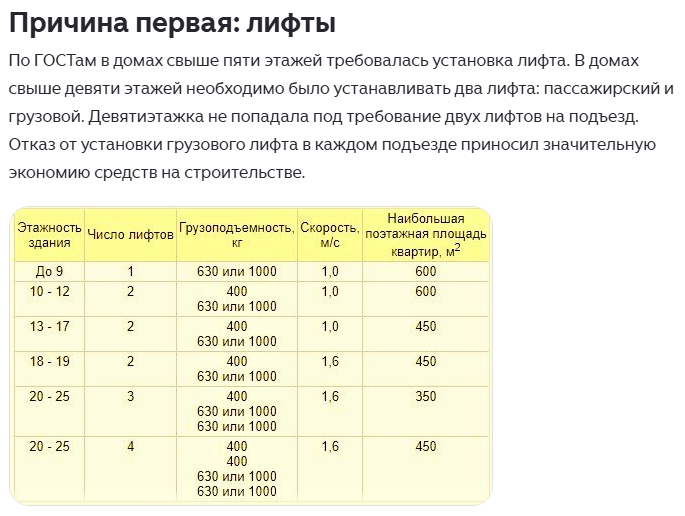

**cargo_elevator**                

In [267]:
'''
В начале 1970-х годов начали строить точечные кирпичные четырнадцатиэтажки серии 1-528КП-80, в которых впервые применили планировочное решение с двумя лифтами, один из которых грузовой
Для домой страше этого года заменяем пропуски на 0
Ну, думаю можно еще лет 5 накинуть, пока фичу сделали массовой
'''
df.loc[(df['cargo_elevator'].isna()) & (df['year_of_construction'] <= 1975), 'cargo_elevator'] = 0

'''
В пятиэтажных домах и меньше нет грузовых лифтов, для них не было места
'''
df.loc[(df['cargo_elevator'].isna()) & (df['total_floors'] <= 5), 'cargo_elevator'] = 0

'''
Допустим с 1990 во всех домах строят грузовый лифт. + Опираемся на картинку выше и говорим, что дом должен быть 10 этажным
'''
df.loc[(df['cargo_elevator'].isna()) & (df['year_of_construction'] >= 1990) & (df['total_floors'] >= 10), 'cargo_elevator'] = 1

**passenger_elevator**

In [268]:
'''
Беру условия из картинки выше
По опыту грузовой лифт всегда один, а остальные пассажирские
'''
# Для домов с 25 и более этажами
df.loc[(df['passenger_elevator'].isna()) & (df['total_floors'] >= 25), 'passenger_elevator'] = 3

# Для домов от 20 до 24 этажей
df.loc[(df['passenger_elevator'].isna()) & (df['total_floors'] >= 20) & (df['total_floors'] < 25), 'passenger_elevator'] = 2

# Для домов от 5 до 19 этажей
df.loc[(df['passenger_elevator'].isna()) & (df['total_floors'] >= 5) & (df['total_floors'] < 20), 'passenger_elevator'] = 1

**living_area**

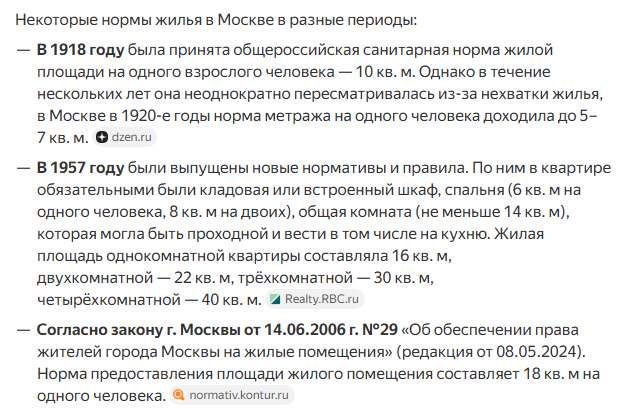

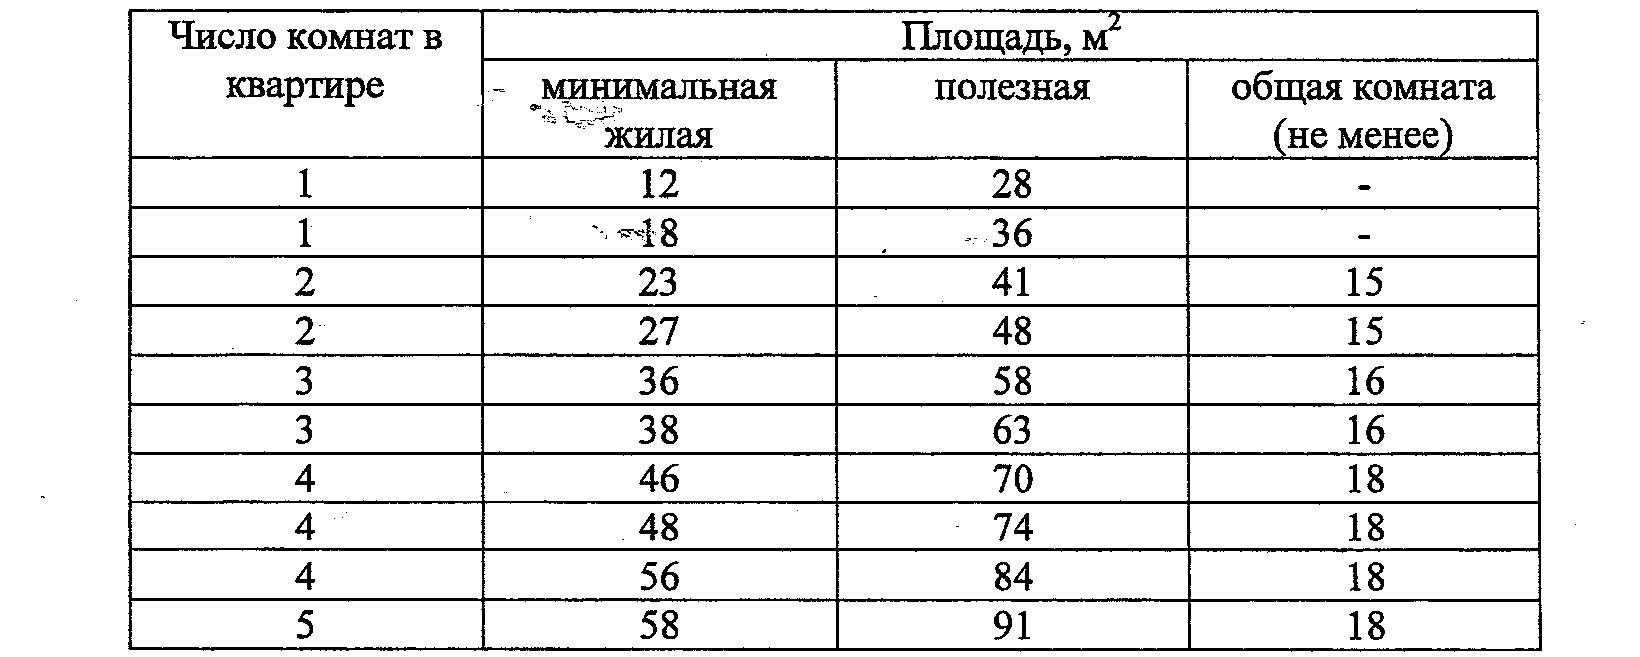

In [269]:
'''
Опираемся на данные с приведенных выше картинок
- 1 (ответ из поиска в яндекса). При чем в 18кв.м. жилой входит спальня и гостинная
- 2 (картинка соотношения жилой - общей - гостинной площади)

Выкинем из данных для проверки Апартаменты, потому что там может все что угодно
Начнем с тех норм, которые точно известны!
'''


'''
Для 1-комнатных и Студий (рассчитаны на 1го человека), жилая площадь на человека все также 18 кв.м., дом не старше 2006
В целом в объявлениях примерно так и выходит: комната 10-13 метров и гостинная 8-5 метров....господи, если бы еще кавартиры норм проектировали, то бестолковые коридоры бы не крали стооолько полезного места
Сделаем 20 кв.м. в среднем, т.к. 2-3 метра еще присоединяют гардеробную к спальне
'''
df.loc[(df['apartment'].isna())
& (df['living_area'].isna())
& (df['year_of_construction'] >= 2006.0)
& ((df['rooms_count'] == '1') | (df['rooms_count'] == 'Студия')), 'living_area'] = 20

'''
для 2х комнатных должно быть 36кв.м, дом не старше 2006
'''
df.loc[(df['apartment'].isna())
& (df['living_area'].isna())
& (df['year_of_construction'] >= 2006.0)
& ((df['rooms_count'] == '2')), 'living_area'] = 36

'''
для 3х комнатных возьмем 45кв.м
'''
df.loc[(df['apartment'].isna())
& (df['living_area'].isna())
& (df['year_of_construction'] >= 2006.0)
& ((df['rooms_count'] == '2')), 'living_area'] = 45

'''
для 4х комнатных возьмем 45кв.м
'''
df.loc[(df['apartment'].isna())
& (df['living_area'].isna())
& (df['year_of_construction'] >= 2006.0)
& ((df['rooms_count'] == '2')), 'living_area'] = 45

'''
для 4х комнатных возьмем 45кв.м
'''
df.loc[(df['apartment'].isna())
& (df['living_area'].isna())
& (df['year_of_construction'] >= 2006.0)
& ((df['rooms_count'] == '2')), 'living_area'] = 75

'''
рассмотрим в целом маленькие квартиры и АПАРТАМЕНТЫ от 15 до 25 кв.м, не привязываясь к году постройки
20 метров (в среднем) - 3 метра (санузел) - 3 метра (коридор) - 4 метра (кухня) = 10 метров
'''
df.loc[(df['total_area'] >= 15) & (df['total_area'] <= 25) & (df['living_area'].isna()) , 'living_area'] = 10

'''
еще вычисления
общая площадь - площадь кухни - 3 метра * кол-во совмещенных санузлов - 3 метра * кол-во раздельных санузлов
'''
df.loc[(df['living_area'].isna()), 'living_area'] = df['total_area'] - df['kitchen_area'] - 3*df['separated_bathroom'] - 3*df['combined_bathroom']


'''
не для апартаментов
но для тех у кого кроме общей площадь больше ничего нет, давай за жилую площадь возьмем 0,4 от общей (для кухни в следующем шаге 0,3, для прочих штук тоже 0.3)
'''
df.loc[(df['living_area'].isna()), 'living_area'] = round(0.4*df['total_area'], 0)

**kitchen_area**

In [270]:
df.loc[(df['kitchen_area'].isna()), 'kitchen_area'] = round(0.3*df['total_area'], 0)

**loggia, balcony**

In [271]:
'''
ну, лоджия и балкон типо отличаются, но как будто различия между ними не играю большой разницы для цены
поэтому объединим их в колонку loggia_balcony (БЛ) и будем обрабатывать их  вместе
'''

temp_sum = df['loggia'].fillna(0) + df['balcony'].fillna(0)
# Условия для NaN
df['loggia_balcony'] = np.where(
    df['loggia'].isna() & df['balcony'].isna(),  # если оба NaN
    np.nan,                                      # то результат NaN
    temp_sum                                     # иначе сумма
)

'''
уберем признак лоджии и балкона, т.к. они по отдельности больше не нужны
'''
df = df.drop(columns=['balcony', 'loggia'])

'''
ну, в квартирах/апартах до 30 кв.м БЛ врятли будет
'''
df.loc[(df['total_area']<=30.0) & (df['loggia_balcony'].isna()), 'loggia_balcony'] = 0

'''
для объявлений с площадью  от 30 до 40, у которых пропуск в loggia_balcony поставим loggia_balcony=1 с вероятностью 0.3
я видела квартира на 30 метров, но с БЛ!!! удивлению нет предела
'''
np.random.seed(42)
mask = (df['total_area'] >= 30) & (df['total_area'] <= 45) & (df['loggia_balcony'].isna())
random_values = np.random.choice([0, 1], size=mask.sum(), p=[0.7, 0.3])
df.loc[mask, 'loggia_balcony'] = random_values

### step1 Пропуски более 50% - убираем признак

In [272]:
# Создаем словарь для классификации признаков
quantitative = [
    'price', 'total_area', 'living_area', 'kitchen_area', 'ceiling_height',
    'floor', 'total_floors', 'combined_bathroom', 'separated_bathroom',
    'passenger_elevator', 'loggia_balcony', 'cargo_elevator'
]

# Параметры с общими признаками
all_features = (
    quantitative +
    categorical +
    binary +
    datetime +
    geodata +
    text
)

nan_share = df[all_features].isna().mean()

cols_to_drop = nan_share[nan_share > 0.5].index.tolist()

df = df.drop(columns=cols_to_drop)

In [273]:
# Параметры с признаками характерными только для первички или вторички

# Списки для удаления
cols_to_drop = []

#удаляем из списка признак highway_info, его интересно изучить потом
params_secondary_only.remove('highway_info')

# --- Проверка вторички ---
for col in params_secondary_only:
    nan_pct = df.loc[only_sec, col].isna().mean() * 100
    if nan_pct > 50:
        cols_to_drop.append(col)

# --- Проверка новостроек ---
for col in params_new_only:
    nan_pct = df.loc[only_new, col].isna().mean() * 100
    if nan_pct > 50:
        cols_to_drop.append(col)

df = df.drop(columns=cols_to_drop)

### step2 Пропуски <= 15% - заполняем статистикой

In [274]:
'''
Заполняем признаки, где % пропусков для каждой из групп по отдельности (первичка/вторичка) составляют не более 15%
Признак будет заполнен медианой/модой, т.к. эти статистики менее подвержены выбросам - она стабильнее
'''

'\nЗаполняем признаки, где % пропусков для каждой из групп по отдельности (первичка/вторичка) составляют не более 15%\nПризнак будет заполнен медианой/модой, т.к. эти статистики менее подвержены выбросам - она стабильнее\n'

In [275]:
# Порог для заполнения пропусков
threshold = 15.0

# Функция для заполнения пропусков в группе
def fill_missing_in_group(df, feature_list, group_mask, group_name, fill_type='median'):
    """
    Заполняет пропуски в группе медианой или модой, если % пропусков < 15%
    % считается от n_total, заполнение - статистикой внутри группы
    """
    for col in feature_list:
        if col not in df.columns:
            continue

        # Считаем % пропусков от n_total (твоя логика)
        nan_pct = df.loc[group_mask, col].isna().sum() / n_total * 100

        if nan_pct > 0 and nan_pct < threshold:
            if fill_type == 'median':
                # Заполняем медианой ВНУТРИ ГРУППЫ
                fill_value = df.loc[group_mask, col].median()
                df.loc[group_mask & df[col].isna(), col] = fill_value

            elif fill_type == 'mode':
                # Заполняем модой ВНУТРИ ГРУППЫ
                mode_series = df.loc[group_mask, col].mode()
                if len(mode_series) > 0:
                    fill_value = mode_series[0]
                    df.loc[group_mask & df[col].isna(), col] = fill_value



fill_missing_in_group(df, quantitative, only_new, 'Новостройка', fill_type='median')
fill_missing_in_group(df, categorical, only_new, 'Новостройка', fill_type='mode')
fill_missing_in_group(df, binary, only_new, 'Новостройка', fill_type='mode')
fill_missing_in_group(df, quantitative, only_sec, 'Вторичка', fill_type='median')
fill_missing_in_group(df, categorical, only_sec, 'Вторичка', fill_type='mode')
fill_missing_in_group(df, binary, only_sec, 'Вторичка', fill_type='mode')

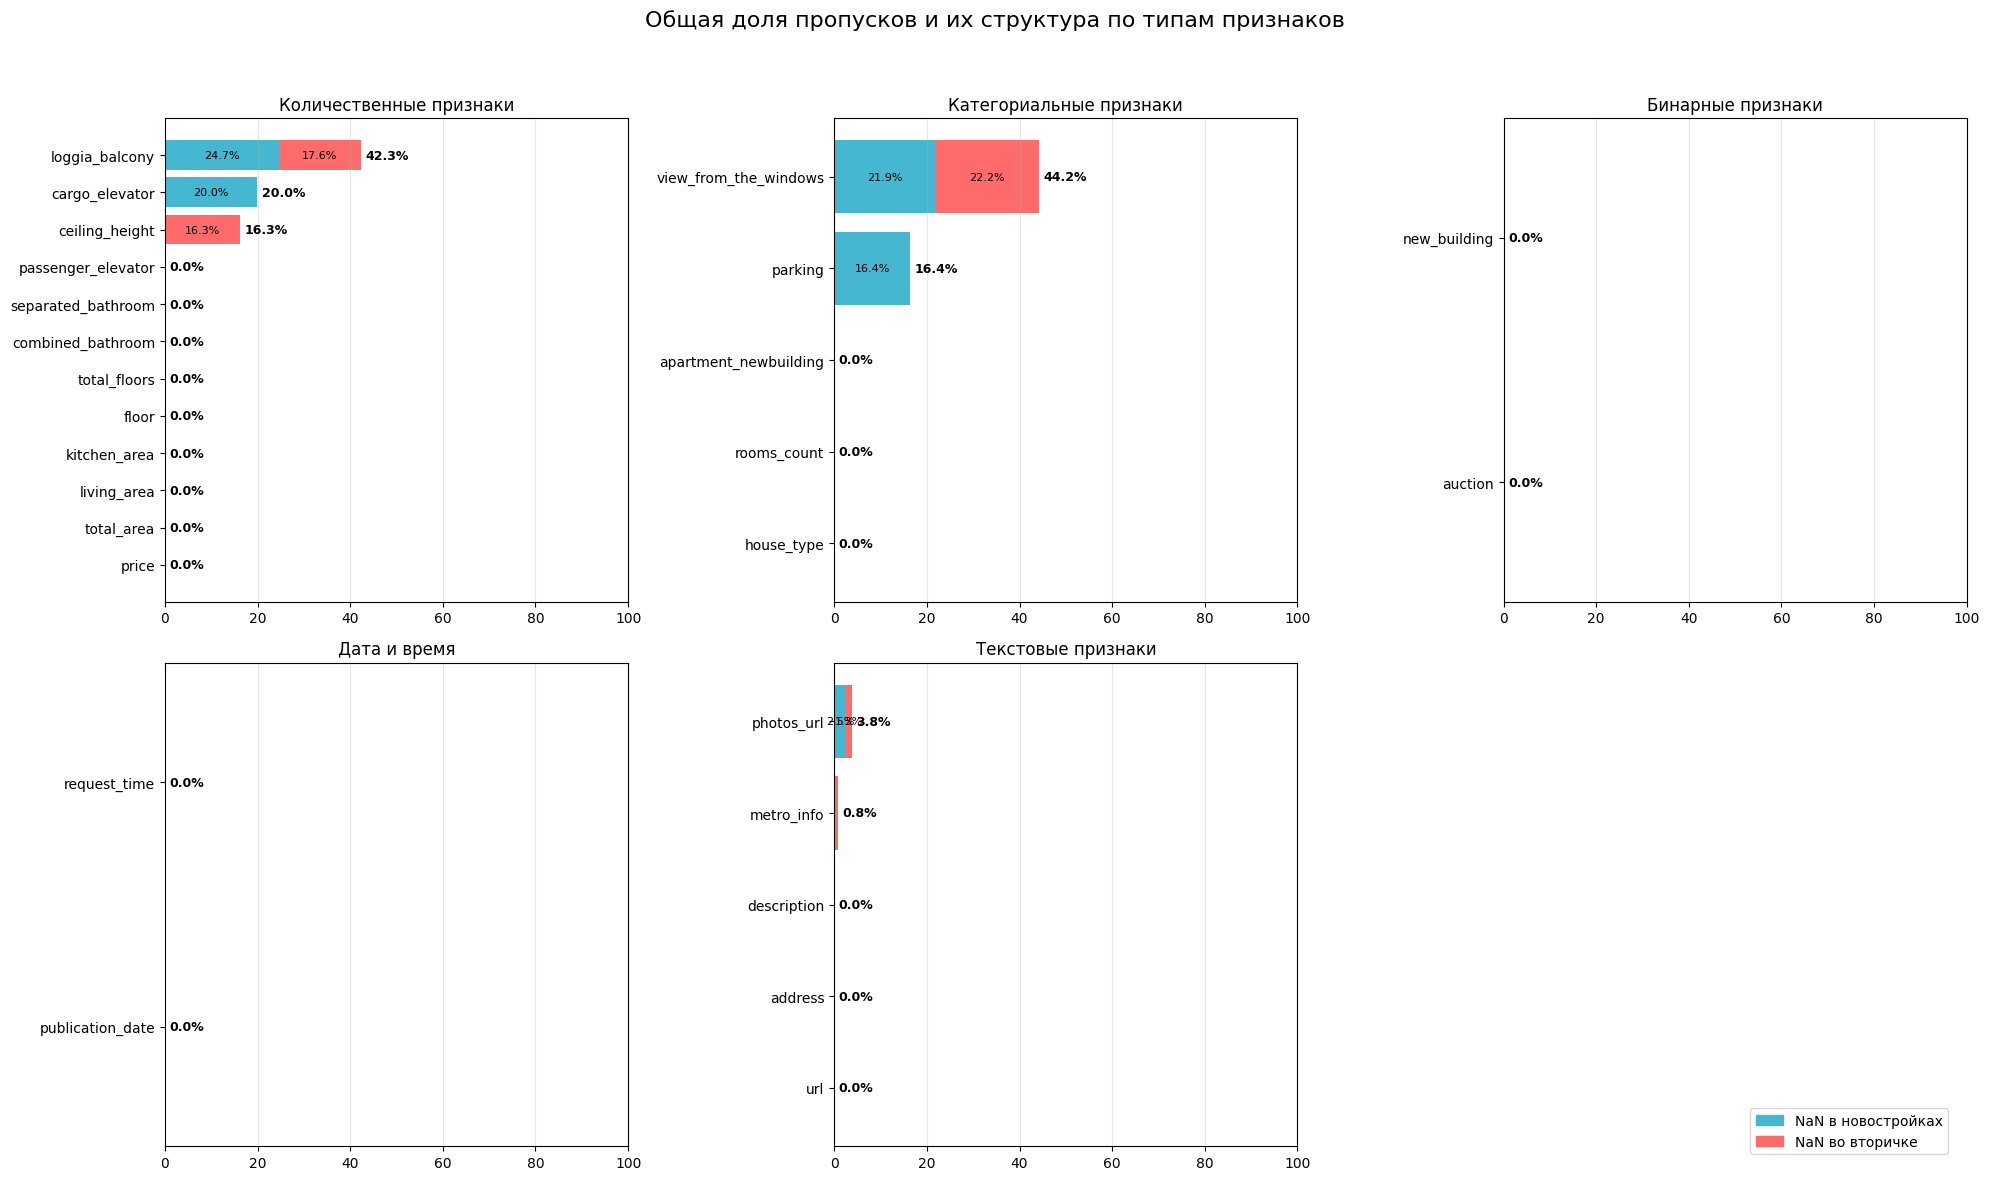

In [276]:
only_new = df['new_building'] == 'Новостройка'
only_sec = df['new_building'] == 'Вторичка'
n_total = len(df)

# Создаем словарь для классификации признаков
quantitative = [
    'price', 'total_area', 'living_area', 'kitchen_area', 'ceiling_height',
    'floor', 'total_floors', 'combined_bathroom', 'separated_bathroom',
    'passenger_elevator', 'loggia_balcony', 'cargo_elevator'
]

categorical = [
    'house_type', 'view_from_the_windows', 'parking',
    'rooms_count', 'apartment_newbuilding'
]

binary = [
    'auction', 'new_building'
]

datetime = ['publication_date', 'request_time']

geodata = ['lat', 'lng']

text = [
    'url', 'address',
    'description', 'photos_url', 'metro_info'
]

# --- функция подготовки данных ---
def prepare_stacked_nan_data(feature_list):
    rows = []

    for col in feature_list:
        nan_new = df.loc[only_new, col].isna().sum() / n_total * 100
        nan_sec = df.loc[only_sec, col].isna().sum() / n_total * 100

        rows.append({
            'Column': col,
            'NaN_new': nan_new,
            'NaN_sec': nan_sec,
            'Total_NaN': nan_new + nan_sec
        })

    return (
        pd.DataFrame(rows)
        .sort_values('Total_NaN', ascending=True)
    )

# --- данные по типам признаков ---
data_quantitative = prepare_stacked_nan_data(quantitative)
data_categorical = prepare_stacked_nan_data(categorical)
data_binary = prepare_stacked_nan_data(binary)
data_datetime = prepare_stacked_nan_data(datetime)
data_text = prepare_stacked_nan_data(text)

# --- функция построения одного графика ---
def plot_stacked_bars(ax, data, title):
    if data.empty:
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center')
        ax.set_title(title)
        return

    bars_new = ax.barh(
        data['Column'],
        data['NaN_new'],
        color='#45B7D1',
        label='NaN в новостройках'
    )

    bars_sec = ax.barh(
        data['Column'],
        data['NaN_sec'],
        left=data['NaN_new'],
        color='#FF6B6B',
        label='NaN во вторичке'
    )

    for _, row in data.iterrows():
        if row['NaN_new'] > 1:
            ax.text(
                row['NaN_new'] / 2,
                row['Column'],
                f"{row['NaN_new']:.1f}%",
                va='center',
                ha='center',
                fontsize=8
            )

        if row['NaN_sec'] > 1:
            ax.text(
                row['NaN_new'] + row['NaN_sec'] / 2,
                row['Column'],
                f"{row['NaN_sec']:.1f}%",
                va='center',
                ha='center',
                fontsize=8
            )

        ax.text(
            row['Total_NaN'] + 1,
            row['Column'],
            f"{row['Total_NaN']:.1f}%",
            va='center',
            ha='left',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_xlim(0, 100)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)


# --- сетка сабплотов ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

plot_stacked_bars(axes[0], data_quantitative, 'Количественные признаки')
plot_stacked_bars(axes[1], data_categorical, 'Категориальные признаки')
plot_stacked_bars(axes[2], data_binary, 'Бинарные признаки')
plot_stacked_bars(axes[3], data_datetime, 'Дата и время')
plot_stacked_bars(axes[4], data_text, 'Текстовые признаки')

axes[5].axis('off')

# общая легенда
handles = [
    plt.Rectangle((0, 0), 1, 1, color='#45B7D1'),
    plt.Rectangle((0, 0), 1, 1, color='#FF6B6B')
]

labels = ['NaN в новостройках', 'NaN во вторичке']

fig.legend(
    handles,
    labels,
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    frameon=True
)

plt.suptitle(
    'Общая доля пропусков и их структура по типам признаков',
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [277]:
# Порог для заполнения пропусков
threshold = 15.0

# Функция для заполнения пропусков в специфичных параметрах
def fill_missing_specific_params(df, feature_list, group_mask, n_group, group_name):
    """
    Заполняет пропуски в группе медианой или модой, если % пропусков < 15%
    % считается от размера конкретной группы (n_group)
    """
    for col in feature_list:
        if col not in df.columns:
            continue

        # Считаем % пропусков от размера группы
        nan_pct = df.loc[group_mask, col].isna().sum() / n_group * 100

        if nan_pct > 0 and nan_pct < threshold:
            # Определяем тип признака и выбираем метод заполнения
            if df[col].dtype in ['int64', 'float64']:
                # Количественный признак → медиана
                fill_value = df.loc[group_mask, col].median()
                df.loc[group_mask & df[col].isna(), col] = fill_value
            else:
                # Категориальный признак → мода
                mode_series = df.loc[group_mask, col].mode()
                if len(mode_series) > 0:
                    fill_value = mode_series[0]
                    df.loc[group_mask & df[col].isna(), col] = fill_value


fill_missing_specific_params(df, params_secondary_only, only_sec, n_sec, 'Вторичка')
fill_missing_specific_params(df, params_new_only, only_new, n_new, 'Новостройка')

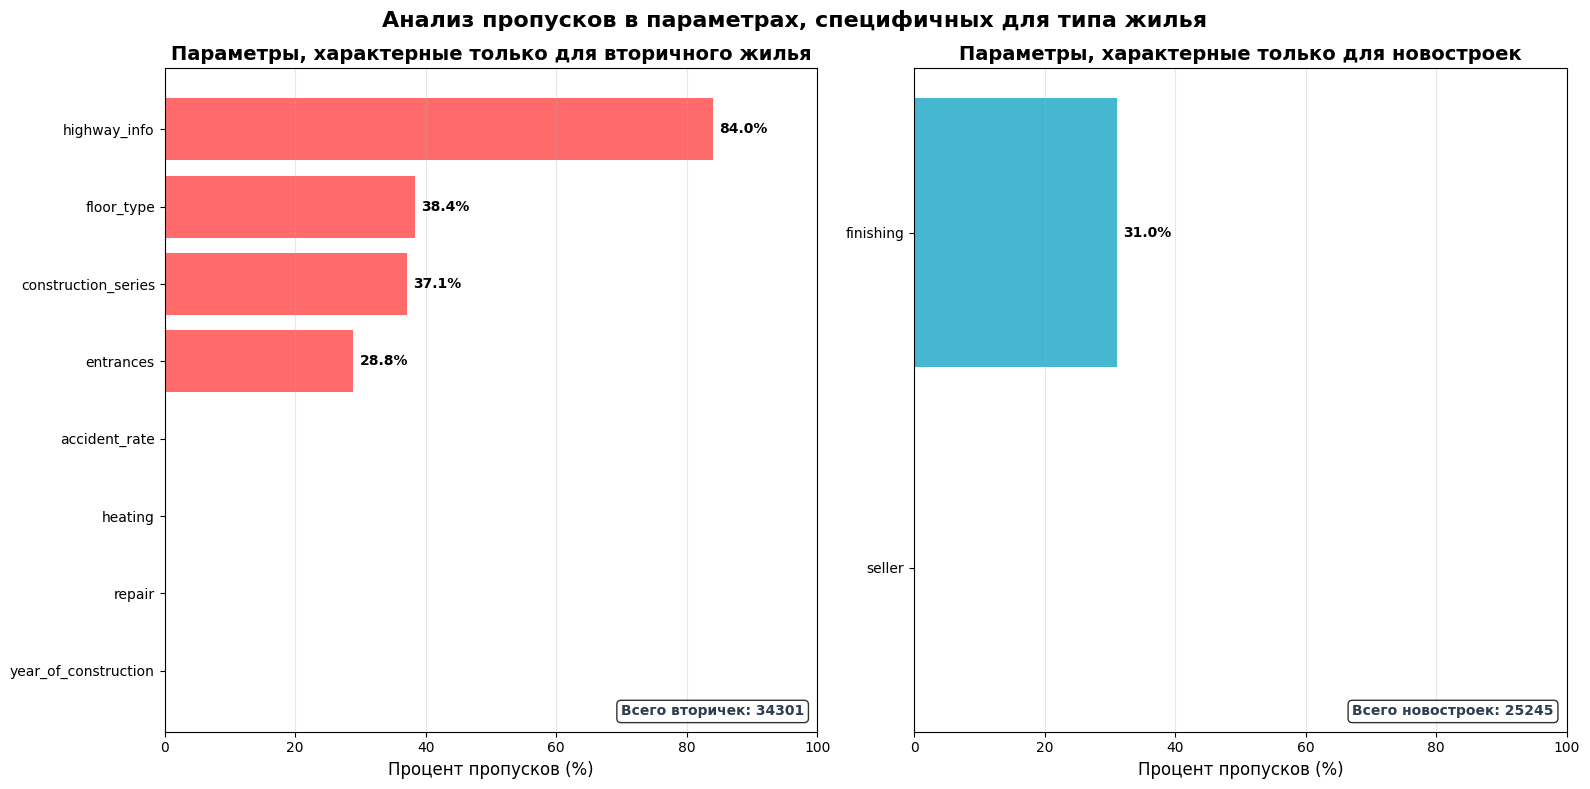

In [278]:
# Фильтры для новостроек и вторичек
only_new = df['new_building'] == 'Новостройка'
only_sec = df['new_building'] == 'Вторичка'

n_new = len(df[only_new])  # Количество новостроек
n_sec = len(df[only_sec])  # Количество вторичек

# --- Параметры для вторичек (как в прошлом графике) ---
params_secondary_only = [
    'year_of_construction',
    'entrances',
    'repair',
    'heating',
    'floor_type',
    'accident_rate',
    'construction_series',
    'highway_info'
]

# --- Параметры для новостроек ---
params_new_only = [
    'finishing',
    'seller'
]

# Расчет процента пропусков для вторичек
rows_sec = []
for col in params_secondary_only:
    nan_sec = df.loc[only_sec, col].isna().sum() / n_sec * 100
    rows_sec.append({
        'Column': col,
        'NaN_pct': nan_sec,
        'Type': 'Вторичка'
    })

# Расчет процента пропусков для новостроек
rows_new = []
for col in params_new_only:
    nan_new = df.loc[only_new, col].isna().sum() / n_new * 100
    rows_new.append({
        'Column': col,
        'NaN_pct': nan_new,
        'Type': 'Новостройка'
    })

# Создание DataFrame'ов и сортировка
data_sec = pd.DataFrame(rows_sec).sort_values('NaN_pct', ascending=True)
data_new = pd.DataFrame(rows_new).sort_values('NaN_pct', ascending=True)

# Создание полотна с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- График для вторичек (слева) ---
bars1 = ax1.barh(
    data_sec['Column'],
    data_sec['NaN_pct'],
    color='#FF6B6B',
    label='NaN во вторичке'
)

# Добавление подписей значений для вторичек
for i, (_, row) in enumerate(data_sec.iterrows()):
    if row['NaN_pct'] > 0:
        ax1.text(
            row['NaN_pct'] + 1,
            row['Column'],
            f"{row['NaN_pct']:.1f}%",
            va='center',
            ha='left',
            fontsize=10,
            fontweight='bold'
        )

# Настройка левого графика
ax1.set_xlim(0, 100)
ax1.set_xlabel('Процент пропусков (%)', fontsize=12)
ax1.set_title('Параметры, характерные только для вторичного жилья',
             fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.text(0.98, 0.02, f'Всего вторичек: {n_sec}',
         transform=ax1.transAxes, ha='right', va='bottom',
         fontsize=10, fontweight='bold', color='#2C3E50',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- График для новостроек (справа) ---
bars2 = ax2.barh(
    data_new['Column'],
    data_new['NaN_pct'],
    color='#45B7D1',
    label='NaN в новостройках'
)

# Добавление подписей значений для новостроек
for i, (_, row) in enumerate(data_new.iterrows()):
    if row['NaN_pct'] > 0:
        ax2.text(
            row['NaN_pct'] + 1,
            row['Column'],
            f"{row['NaN_pct']:.1f}%",
            va='center',
            ha='left',
            fontsize=10,
            fontweight='bold'
        )

# Настройка правого графика
ax2.set_xlim(0, 100)
ax2.set_xlabel('Процент пропусков (%)', fontsize=12)
ax2.set_title('Параметры, характерные только для новостроек',
             fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.text(0.98, 0.02, f'Всего новостроек: {n_new}',
         transform=ax2.transAxes, ha='right', va='bottom',
         fontsize=10, fontweight='bold', color='#2C3E50',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Общий заголовок
plt.suptitle('Анализ пропусков в параметрах, специфичных для типа жилья',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Андрей

## Исследуем соответствуют ли типы данных в датасете необходимым.

###Первичный обзор

In [279]:
def overview(df):
    exclude_cols = ['url', 'description', 'photos_url', 'index', 'price']
    text_df = df.select_dtypes(include = ['object', 'string'])
    cols_to_analyze = [c for c in text_df.columns if c not in exclude_cols]

    fin_df = []
    total_rows = len(df)

    for col in cols_to_analyze:
        col_series = df[col]
        unique_values = col_series.dropna().unique()

        n_nan = col_series.isna().sum()
        n_filled = total_rows - n_nan
        n_unique = len(unique_values)
        zap = (n_unique/n_filled*100) if n_filled > 0 else 0

        examples = list(unique_values[:5])
        examples_str = " || ".join(map(str, examples))

        fin_df.append({"Признак": col,
            "Заполнено": n_filled,
            "Пропущено": n_nan,
            "Уникальных": n_unique,
            "Разнообразие в проц": round(zap, 2),
            "Примеры": examples_str})

    return pd.DataFrame(fin_df).set_index("Признак")

In [280]:
overview(df)

,Заполнено,Пропущено,Уникальных,Разнообразие в проц,Примеры
Признак,,,,,
address,59546,0,15799,27,"Москва, ЮАО, р-н Даниловский, м. Автозаводская..."
auction,59546,0,1,0,Н
rooms_count,59546,0,5,0,Студия || 1 || 2 || 3 || 4
new_building,59546,0,2,0,Вторичка || Новостройка
view_from_the_windows,33255,26291,3,0,Во двор || На улицу || На улицу и двор
repair,34301,25245,4,0,Евроремонт || Косметический || Без ремонта || ...
construction_series,21566,37980,96,0,Индивидуальный проект || П-3М || 1-511 || ГМС-...
floor_type,21143,38403,3,0,Железобетонные || Деревянные || Смешанные
parking,49788,9758,5,0,Наземная || Открытая || Многоуровневая || Подз...


Как видим, некоторые признаки имеют излишнюю уникальность, которая может негативно повлиять на точность модели.
В нашем случае очевидно, что признаки:

1.   metro_info
2.   highway_info
3.   seller
4.   address

могут быть разбиты на несколько признаков, объекты которых будут значительно более подходящими для категориальных признаков по характеру значений - количество уникальных значений будет значительно меньшим, а также некоторые признаки выделенные будут числовыми - к примеру, расстояние до ближайшего шоссе или метро.

Начнем с анализа содержимого адреса.

###Парсинг признака **address**

In [281]:
df.address.unique()[:30]

array(['Москва, ЮАО, р-н Даниловский, м. Автозаводская, Автозаводская улица, 19К1',
       'Москва, САО, р-н Головинский, м. Моссельмаш, Сенежская улица, 3',
       'Москва, ТАО (Троицкий), пос. Рогово, улица Школьная, 17',
       'Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, Покровская улица, 31',
       'Москва, ТАО (Троицкий), пос. ЛМС, Центральный мкр, 7',
       'Москва, ВАО, р-н Измайлово, м. Измайловская, 4-я Парковая улица, 24',
       'Москва, ТАО (Троицкий), м. Троицк, с. Былово, Былово кп, улица Радужная, 2',
       'Москва, САО, р-н Ховрино, м. Грачёвская, Клинская улица, 8С1',
       'Москва, ТАО (Троицкий), Витро Вилладж База отдыха, к4',
       'Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, Рождественская улица, 21к5',
       'Москва, ТАО (Троицкий), Витро Вилладж База отдыха, к7',
       'Москва, ТАО (Троицкий), м. Троицк, Троицк, улица Городская, 20',
       'Москва, ВАО, р-н Преображенское, м. Электрозаводская, 1-й Электрозаводский переулок, 4',
       'Москва, ТАО (Тр

Очевидно логично выделить из адреса три признака: метро указанное в адресе, округ и район. Число уникальных объектов в данных признаках будет достаточно малым.

In [282]:
def parse_address(addr):
    if not isinstance(addr, str):
        return pd.Series([np.nan, np.nan, np.nan])

    valid_okrugs = ['цао', 'сао', 'свао', 'вао', 'ювао', 'юао', 'юзао',
                    'зао', 'сзао', 'зелао', 'тао', 'нао']

    s = addr.lower()

    okrug = np.nan
    okrug_pattern = r'москва,\s*(' + '|'.join(valid_okrugs) + r')(?:\s*\([^\)]+\))?'
    okrug_match = re.search(okrug_pattern, s)
    if okrug_match:
        okrug = okrug_match.group(1).strip()

    district = np.nan
    district_match = re.search(r'р-н\s+([а-яё\-\s]+?)(?:,|$)', s)
    if district_match:
        district = f"р-н {district_match.group(1).strip()}"

    metro = np.nan
    metro_match = re.search(r'м\.\s*([а-яё\s\-—]+?)(?:,|$)', s)
    if metro_match:
        metro = metro_match.group(1).strip()

    return pd.Series([okrug, district, metro])

In [283]:
df[["okrug", "district", "metro_adress"]] = df["address"].apply(parse_address)

In [284]:
df[["address","okrug", "district", "metro_adress"]].head(10)

,address,okrug,district,metro_adress
0,"Москва, ЮАО, р-н Даниловский, м. Автозаводская...",юао,р-н даниловский,автозаводская
1,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",сао,р-н головинский,моссельмаш
2,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",сао,р-н головинский,моссельмаш
3,"Москва, ТАО (Троицкий), пос. Рогово, улица Шко...",тао,NaN,NaN
4,"Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, П...",ювао,р-н некрасовка,некрасовка
5,"Москва, ТАО (Троицкий), пос. ЛМС, Центральный ...",тао,NaN,NaN
6,"Москва, ВАО, р-н Измайлово, м. Измайловская, 4...",вао,р-н измайлово,измайловская
7,"Москва, ТАО (Троицкий), м. Троицк, с. Былово, ...",тао,NaN,троицк
8,"Москва, САО, р-н Ховрино, м. Грачёвская, Клинс...",сао,р-н ховрино,грачёвская
9,"Москва, ТАО (Троицкий), Витро Вилладж База отд...",тао,NaN,NaN


Как видим, метро или район в адресе могут быть не указаны. Добавим заглушки - в случае метро укажем "отсутствует" если метро поблизости нет, район - другой, если не относится к Московским районам, аналогично поступим с округом

In [285]:
df.metro_adress=df.metro_adress.fillna('отсутствует')
df.district=df.district.fillna('другое')
df.okrug=df.okrug.fillna('другое')

Проверим корректность замен через просмотр уникальных значений

In [286]:
df.metro_adress.unique()

array(['автозаводская', 'моссельмаш', 'отсутствует', 'некрасовка',
       'измайловская', 'троицк', 'грачёвская', 'электрозаводская',
       'беговая', 'нижегородская', 'нагорная', 'пятницкое шоссе',
       'озёрная', 'щёлковская', 'тульская', 'сходненская',
       'красные ворота', 'кунцевская', 'давыдково', 'потапово',
       'павелецкая', 'сокольники', 'отрадное', 'бунинская аллея', 'депо',
       'чухлинка', 'зеленоград — крюково', 'измайлово', 'белокаменная',
       'южная', 'селигерская', 'пражская', 'верхние котлы', 'лефортово',
       'преображенская площадь', 'варшавская', 'университет', 'динамо',
       'авиамоторная', 'апрелевка', 'лухмановская', 'филатов луг',
       'красный балтиец', 'окружная', 'бульвар рокоссовского',
       'яхромская', 'бауманская', 'подольск', 'ботанический сад',
       'владыкино', 'мякинино', 'саларьево', 'петровско-разумовская',
       'андроновка', 'санино', 'ольховая', 'говорово', 'вешняки',
       'стрешнево', 'зил', 'пыхтино', 'новокузнецкая',

In [287]:
df.district.unique()

array(['р-н даниловский', 'р-н головинский', 'другое', 'р-н некрасовка',
       'р-н измайлово', 'р-н ховрино', 'р-н преображенское',
       'р-н хорошевский', 'р-н нижегородский', 'р-н нагорный',
       'р-н митино', 'р-н очаково-матвеевское', 'р-н северное измайлово',
       'р-н южное тушино', 'р-н красносельский', 'р-н северное тушино',
       'р-н фили-давыдково', 'р-н замоскворечье', 'р-н сокольники',
       'р-н отрадное', 'р-н южное бутово', 'р-н печатники',
       'р-н рязанский', 'р-н крюково', 'р-н соколиная гора',
       'р-н богородское', 'р-н чертаново северное',
       'р-н западное дегунино', 'р-н чертаново центральное',
       'р-н донской', 'р-н лефортово', 'р-н нагатино-садовники',
       'р-н котловка', 'р-н ломоносовский', 'р-н беговой', 'р-н перово',
       'р-н косино-ухтомский', 'р-н войковский', 'р-н марфино',
       'р-н дмитровский', 'р-н басманный', 'р-н останкинский',
       'р-н кунцево', 'р-н тимирязевский', 'р-н солнцево', 'р-н вешняки',
       'р-н соко

In [288]:
df.okrug.unique()

array(['юао', 'сао', 'тао', 'ювао', 'вао', 'сзао', 'зао', 'цао', 'свао',
       'юзао', 'зелао', 'нао', 'другое'], dtype=object)

Продолжим. Разделим признак продавца на новые признаки: тип продавца и уникальное имя.

###Парсинг признака **seller**

In [289]:
df.seller.unique()

array([nan, 'Агентство недвижимости, Ордер',
       'Автор объявления, ID 135186715', ...,
       'Автор объявления, Ирина Иванова',
       'Агентство недвижимости, New Day Realty',
       'Автор объявления, Владислав Дворов'], dtype=object)

In [290]:
def parse_seller(cell):
    if not isinstance(cell, str) or cell.strip() == "":
        return pd.Series([None, None])
    parts = cell.split(",", 1)
    seller_type = parts[0].strip()
    seller_name = parts[1].strip() if len(parts)>1 else None
    return pd.Series([seller_type, seller_name])

df[["seller_type", "seller_name"]] = df["seller"].apply(parse_seller)

In [291]:
df[["seller","seller_type", "seller_name"]].dropna().head(5)

,seller,seller_type,seller_name
37499,"Агентство недвижимости, Ордер",Агентство недвижимости,Ордер
37500,"Автор объявления, ID 135186715",Автор объявления,ID 135186715
37501,"Автор объявления, ID 135186715",Автор объявления,ID 135186715
37502,"Автор объявления, ID 135186715",Автор объявления,ID 135186715
37503,"Автор объявления, ID 135186715",Автор объявления,ID 135186715


In [292]:
df.seller_type.unique()

array([None, 'Агентство недвижимости', 'Автор объявления', 'Застройщик',
       'Собственник', 'Консультант', 'Представитель застройщика',
       'Управляющая компания'], dtype=object)

In [293]:
df[df.seller_type.isna()&df.seller.notna()][['seller','seller_type','seller_name']][:30]

,seller,seller_type,seller_name


Как видим, типы продавца были определены корректно. Пропуски только там, где пропущено поле продавца<br>Просмотрим подробнее информацию о метро

###Парсинг признака **metro_info**

In [294]:
df["metro_info"].head(10)

0    Автозаводская 5 мин. (пешком), ЗИЛ 9 мин. (пеш...
1    Моссельмаш 10 мин. (пешком), Грачёвская 19 мин...
2    Моссельмаш 10 мин. (пешком), Грачёвская 19 мин...
3                                                  NaN
4    Некрасовка 3 мин. (пешком), Лухмановская 18 ми...
5                                                  NaN
6    Измайловская 12 мин. (пешком), Первомайская 12...
7    Троицк откроется в 2026 15 мин. (на машине), В...
8    Беломорская 18 мин. (пешком), Грачёвская 11 ми...
9                                                  NaN
Name: metro_info, dtype: object

Разобьем информацию о метро по аналогии на признаки: количество станций поблизости, ближайшая по скорости дороги, как добраться до ближайшей - на машине или пешком, и открыта ли ближайшая.

In [295]:
def parse_transport(cell):
    if not isinstance(cell, str) or cell.strip() == "":
        return pd.Series([None, None, None, None, None])

    pattern = r"(.+?)\s+(\d+)\s+мин\.\s+\((пешком|на машине)\)"
    matches = re.findall(pattern, cell)

    if not matches:
        return pd.Series([None, None, None, None, None])

    st, mins, mode = matches[0]

    st_name = st.strip().strip(", ")

    if "откроется в" in st_name:
        st_name = re.split(r"\s*откроется в\s*.*", st_name)[0].strip(", ")
        nearest_station_open = "нет"
    else:
        nearest_station_open = "да"

    return pd.Series([mode,
        int(mins),
        st_name,
        len(matches),
        nearest_station_open])

df[["fastest_mode",
    "fastest_minutes",
    "nearest_station",
    "stations_nearby",
    "nearest_station_open"]] = df["metro_info"].apply(parse_transport)

In [296]:
df[[ "metro_info",
    "fastest_mode",
    "fastest_minutes",
    "nearest_station",
    "stations_nearby",
    "nearest_station_open"]].head(5)

,metro_info,fastest_mode,fastest_minutes,nearest_station,stations_nearby,nearest_station_open
0,"Автозаводская 5 мин. (пешком), ЗИЛ 9 мин. (пеш...",пешком,5,Автозаводская,3,да
1,"Моссельмаш 10 мин. (пешком), Грачёвская 19 мин...",пешком,10,Моссельмаш,3,да
2,"Моссельмаш 10 мин. (пешком), Грачёвская 19 мин...",пешком,10,Моссельмаш,3,да
3,NaN,None,NaN,None,NaN,None
4,"Некрасовка 3 мин. (пешком), Лухмановская 18 ми...",пешком,3,Некрасовка,3,да


In [297]:
df.nearest_station.unique()

array(['Автозаводская', 'Моссельмаш', None, 'Некрасовка', 'Измайловская',
       'Троицк', 'Беломорская', 'Электрозаводская', 'Речной вокзал',
       'Беговая', 'Нижегородская', 'Нагорная', 'Пятницкое шоссе',
       'Озёрная', 'Щёлковская', 'Тульская', 'Сходненская',
       'Красные ворота', 'Славянский бульвар', 'Давыдково', 'Потапово',
       'Павелецкая', 'Сокольники', 'Отрадное', 'Бунинская аллея', 'Депо',
       'Чухлинка', 'Зеленоград — Крюково', 'Семёновская', 'Белокаменная',
       'Стахановская', 'Южная', 'Селигерская', 'Пражская', 'Лефортово',
       'Преображенская площадь', 'Варшавская', 'Новаторская', 'Динамо',
       'Авиамоторная', 'Апрелевка', 'Лухмановская', 'Филатов Луг',
       'Войковская', 'Окружная', 'Бульвар Рокоссовского', 'Ольховая',
       'Яхромская', 'Бауманская', 'Измайлово', 'Подольск',
       'Ботанический сад', 'Владыкино', 'Мякинино', 'Саларьево',
       'Петровско-Разумовская', 'Андроновка', 'Санино', 'Говорово',
       'Рязанский проспект', 'Сокол', '

In [298]:
df.fastest_minutes.unique()

array([ 5., 10., nan,  3., 12., 15., 18.,  9., 20., 11., 25.,  4.,  6.,
       13., 16.,  8.,  7., 17., 23., 19., 14., 27.,  2.,  1., 24., 21.,
       22., 26., 28., 29.])

In [299]:
df.fastest_mode.unique()

array(['пешком', None, 'на машине'], dtype=object)

Станции определились корректно.<br>Закончим выделение признаков в более дискретные или числовые на разделении информации о шоссе поблизости: выделим в числовую переменную расстояние до мкада, название ближайшего шоссе и количество шоссе поблизости.

###Парсинг признака **highway_info**

In [300]:
def parse_roads(cell):
    if not isinstance(cell, str) or cell.strip() == "":
        return pd.Series([None, None, 0])

    segments = [s.strip() for s in cell.split(',')]

    roads = []
    i = 0
    while i < len(segments):
        road_name = segments[i]
        distance = None

        if i + 1 < len(segments):
            next_seg = segments[i + 1]
            match = re.match(r'(\d+)\s*км от мкад', next_seg, re.IGNORECASE)
            if match:
                distance = int(match.group(1))
                i += 2
            else:
                i += 1
        else:
            i += 1

        roads.append((road_name, distance))

    if not roads:
        return pd.Series([None, None, 0])

    roads_with_distance = [r for r in roads if r[1] is not None]

    if roads_with_distance:
        nearest = min(roads_with_distance, key=lambda x: x[1])
        nearest_name = nearest[0]
        nearest_distance = nearest[1]
    else:
        nearest_name = roads[0][0]
        nearest_distance = None

    return pd.Series([nearest_name, nearest_distance, len(roads)])

In [301]:
df[["nearest_road", "distance_from_mkad", "roads_nearby_count"]] = df["highway_info"].apply(parse_roads)

In [302]:
df[["highway_info","nearest_road", "distance_from_mkad", "roads_nearby_count"]].head(10)

,highway_info,nearest_road,distance_from_mkad,roads_nearby_count
0,NaN,NaN,NaN,0
1,NaN,NaN,NaN,0
2,NaN,NaN,NaN,0
3,"Калужское шоссе, 59 км от МКАД, Симферопольско...",Калужское шоссе,59,2
4,"Новорязанское шоссе, 12 км от МКАД, Косинское ...",Косинское шоссе,5,2
5,"Калужское шоссе, 42 км от МКАД, Варшавское шос...",Калужское шоссе,42,2
6,NaN,NaN,NaN,0
7,"Калужское шоссе, 27 км от МКАД, Киевское шоссе...",Калужское шоссе,27,2
8,NaN,NaN,NaN,0
9,"Симферопольское шоссе, 39 км от МКАД, Варшавск...",Варшавское шоссе,34,2


In [303]:
df["nearest_road"].unique()

array([nan, 'Калужское шоссе', 'Косинское шоссе', 'Варшавское шоссе',
       'Пятницкое шоссе', 'Ленинградское шоссе', 'Киевское шоссе',
       'Новорижское шоссе', 'Сколковское шоссе', 'Боровское шоссе',
       'Минское шоссе', 'Щелковское шоссе', 'Алтуфьевское шоссе',
       'Носовихинское шоссе', 'Волоколамское шоссе',
       'Симферопольское шоссе', 'Дмитровское шоссе', 'Ярославское шоссе',
       'Новорязанское шоссе', 'Рязанское шоссе', 'Новоегорьевское шоссе',
       'Каширское шоссе', 'Осташковское шоссе', 'Каспий шоссе',
       'Новосходненское шоссе', 'Можайское шоссе', 'Рублевское шоссе',
       'Куркинское шоссе', 'M-11 шоссе', 'Машкинское шоссе',
       'Рублево-Успенское шоссе'], dtype=object)

In [304]:
df[["distance_from_mkad", "nearest_road"]].head()

,distance_from_mkad,nearest_road
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,59,Калужское шоссе
4,5,Косинское шоссе


In [305]:
df['nearest_road'].unique()

array([nan, 'Калужское шоссе', 'Косинское шоссе', 'Варшавское шоссе',
       'Пятницкое шоссе', 'Ленинградское шоссе', 'Киевское шоссе',
       'Новорижское шоссе', 'Сколковское шоссе', 'Боровское шоссе',
       'Минское шоссе', 'Щелковское шоссе', 'Алтуфьевское шоссе',
       'Носовихинское шоссе', 'Волоколамское шоссе',
       'Симферопольское шоссе', 'Дмитровское шоссе', 'Ярославское шоссе',
       'Новорязанское шоссе', 'Рязанское шоссе', 'Новоегорьевское шоссе',
       'Каширское шоссе', 'Осташковское шоссе', 'Каспий шоссе',
       'Новосходненское шоссе', 'Можайское шоссе', 'Рублевское шоссе',
       'Куркинское шоссе', 'M-11 шоссе', 'Машкинское шоссе',
       'Рублево-Успенское шоссе'], dtype=object)

###Приведем текстовые данные к стандартному формату.

In [306]:
def clean_text(cell):
    if not isinstance(cell, str):
        return cell
    cell = cell.strip()
    cell = cell.strip(" ")
    cell = cell.strip(",")
    cell = cell.lower()
    return cell

for col in df.select_dtypes(include = "object").columns:
    df[col] = df[col].apply(clean_text)

## Посчитаем описательные статистики

Так как задание не конкретизировано, выделим следующие описательные статистики - число и для числовых признаков:



1.   Доля_пропущенных

1.   Среднее

1.   Медиана

1.   Мода
2.   Отклонение (стандартное)


2.   Дисперсия


2.   Минимум


2.   Максимум


2.   Разброс минимума с максимумом (Разброс_мин_макс)


1.   Квантиль_25

1.   Квантиль_75

1.   Межквантильный_размах
2.   Коэффициент_вариации


2.   Ассиметрия


2.   Эксцесс

Для категориальных данных существует меньше статистик, выбраны следующие:


1.   Доля_пропущенных

1.   Доля_уникальных (из заполненных)
2.   Мода
3.   Доля_самого_частого_значения



In [307]:
def get_complete_stats(df):
    num_df = df.select_dtypes(include = [np.number])
    cat_df = df.select_dtypes(exclude = [np.number])
    total_rows = len(df)

    num_stats = pd.DataFrame()
    if len(num_df.columns) > 0:
        num_stats["Доля_пропущенных"] = num_df.isna().sum()/total_rows
        num_stats["Среднее"] = num_df.mean()
        num_stats["Медиана"] = num_df.median()
        try:
            num_stats["Мода"] = num_df.mode().iloc[0]
        except Exception:
            num_stats["Мода"] = np.nan
        num_stats["Отклонение"] = num_df.std()
        num_stats["Дисперсия"] = num_df.var()
        num_stats["Минимум"] = num_df.min()
        num_stats["Максимум"] = num_df.max()
        num_stats["Разброс_мин_макс"] = num_stats["Максимум"] - num_stats["Минимум"]
        num_stats["Квантиль_25"] = num_df.quantile(0.25)
        num_stats["Квантиль_75"] = num_df.quantile(0.75)
        num_stats["Межквартильный размах"] = num_stats["Квантиль_75"] - num_stats["Квантиль_25"]
        num_stats["Коэффициент_вариации"] = num_stats["Отклонение"]/num_stats["Среднее"]
        num_stats["Ассиметрия"] = num_df.skew()
        num_stats["Эксцесс"] = num_df.kurtosis()

    cat_stats = pd.DataFrame()
    if len(cat_df.columns) > 0:
        nan_cnt = cat_df.isna().sum()
        filled_cnt = total_rows - nan_cnt
        cat_stats["Доля_пропущенных"] = nan_cnt/total_rows
        cat_stats["Доля_уникальных"] = cat_df.nunique()/filled_cnt
        try:
            cat_stats["Мода"] = cat_df.mode().iloc[0]
        except Exception:
            cat_stats["Мода"] = np.nan
        top_part = []
        for col in cat_df.columns:
            s = cat_df[col].dropna()
            if len(s) == 0:
                top_part.append(0)
            else:
                top_part.append(s.value_counts(normalize = True).iloc[0])
        cat_stats["Доля_самого_частого_значения"] = top_part

    return num_stats, cat_stats

In [308]:
st=get_complete_stats(df)
pd.options.display.float_format = '{:.3f}'.format
st[0]

,Доля_пропущенных,Среднее,Медиана,Мода,Отклонение,Дисперсия,Минимум,Максимум,Разброс_мин_макс,Квантиль_25,Квантиль_75,Межквартильный размах,Коэффициент_вариации,Ассиметрия,Эксцесс
price,0.000,41159300.719,24156149.500,14500000.000,58296127.141,3398438439636246.500,1850000.000,1036776399.000,1034926399.000,16088750.250,41000000.000,24911249.750,1.416,5.593,44.683
total_area,0.000,64.926,58.280,60.000,32.598,1062.625,7.500,199.900,192.400,41.000,79.100,38.100,0.502,1.298,1.849
living_area,0.000,35.402,30.000,20.000,22.463,504.569,-3.000,189.900,192.900,19.900,44.800,24.900,0.635,1.746,4.307
kitchen_area,0.000,14.746,12.000,10.000,9.117,83.123,0.100,92.000,91.900,8.400,19.000,10.600,0.618,1.685,4.214
ceiling_height,0.163,3.010,3.000,3.000,2.100,4.412,0.000,310.000,310.000,2.740,3.100,0.360,0.698,123.582,17473.331
floor,0.000,11.166,8.000,2.000,10.001,100.017,-1.000,84.000,85.000,4.000,15.000,11.000,0.896,1.867,4.642
total_floors,0.000,21.502,18.000,9.000,14.075,198.105,1.000,97.000,96.000,12.000,27.000,15.000,0.655,1.479,2.808
combined_bathroom,0.000,1.224,1.000,1.000,0.472,0.222,1.000,5.000,4.000,1.000,1.000,0.000,0.385,2.079,4.189
separated_bathroom,0.000,0.431,0.000,0.000,0.595,0.354,0.000,9.000,9.000,0.000,1.000,1.000,1.381,1.352,3.622
year_of_construction,0.424,1996.539,2006.000,2006.000,27.196,739.645,1820.000,2027.000,207.000,1975.000,2019.000,44.000,0.014,-1.204,1.480


In [309]:
st[1]

,Доля_пропущенных,Доля_уникальных,Мода,Доля_самого_частого_значения
url,0.000,1.000,https://www.cian.ru/sale/flat/159979025/,0.000
address,0.000,0.265,"москва, зао, р-н можайский",0.005
auction,0.000,0.000,н,1.000
rooms_count,0.000,0.000,2,0.338
new_building,0.000,0.000,вторичка,0.576
view_from_the_windows,0.442,0.000,на улицу и двор,0.387
repair,0.424,0.000,дизайнерский,0.335
construction_series,0.638,0.004,индивидуальный проект,0.667
floor_type,0.645,0.000,железобетонные,0.968
parking,0.164,0.000,наземная,0.456


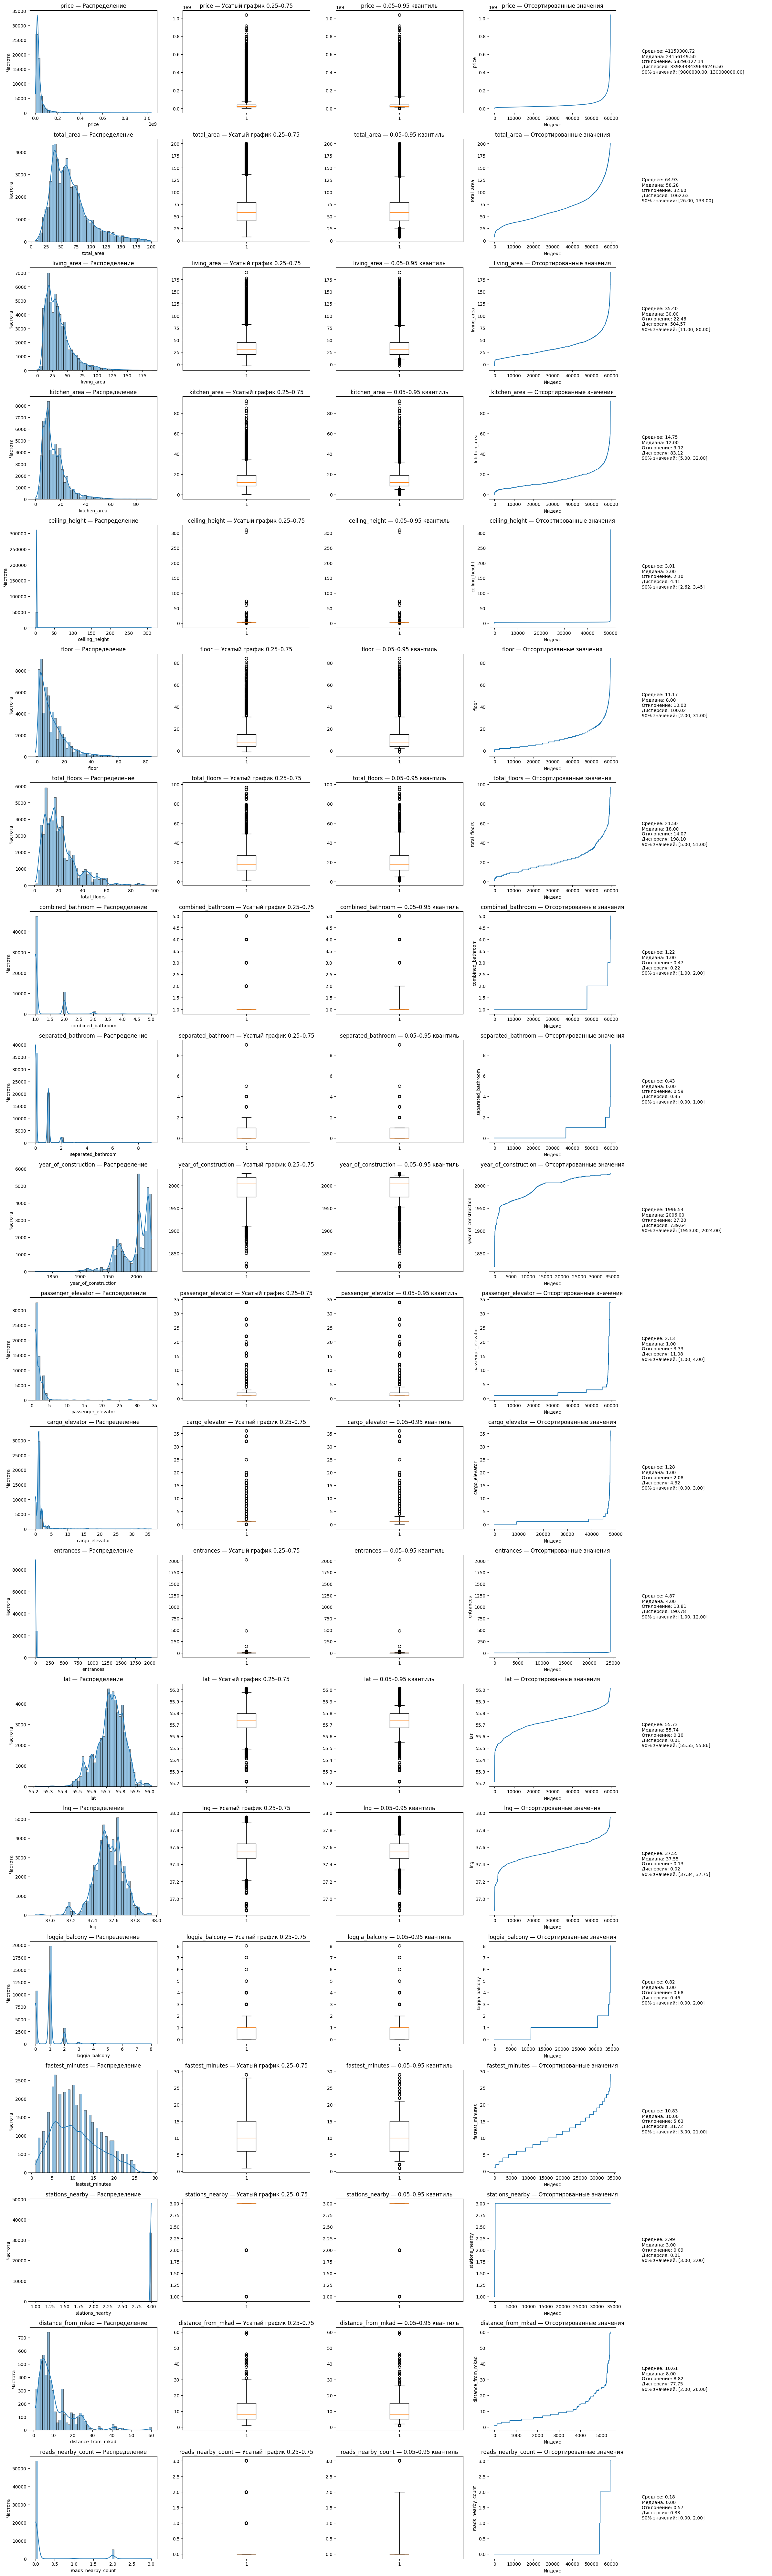

In [310]:
def plot_extras(df, stats):
    cols = df.select_dtypes(include=[np.number]).columns
    n = len(cols)

    fig, axes = plt.subplots(n, 5, figsize=(24, 4 * n))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(cols):
        data = df[col].dropna()

        sns.histplot(data, bins=50, kde=True, ax=axes[i][0])
        axes[i][0].set_title(f'{col} — Распределение')
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel('Частота')

        axes[i][1].boxplot(data)
        axes[i][1].set_title(f'{col} — Усатый график 0.25–0.75')

        p05 = data.quantile(0.05)
        p95 = data.quantile(0.95)
        axes[i][2].boxplot(data, whis=[5,95])
        axes[i][2].set_title(f'{col} — 0.05–0.95 квантиль')

        axes[i][3].plot(sorted(data))
        axes[i][3].set_title(f'{col} — Отсортированные значения')
        axes[i][3].set_xlabel('Индекс')
        axes[i][3].set_ylabel(col)

        mean = stats.loc[col, "Среднее"]
        median = stats.loc[col, "Медиана"]
        std = stats.loc[col, "Отклонение"]
        var = stats.loc[col, "Дисперсия"]

        text = (
            f"Среднее: {mean:.2f}\n"
            f"Медиана: {median:.2f}\n"
            f"Отклонение: {std:.2f}\n"
            f"Дисперсия: {var:.2f}\n"
            f"90% значений: [{p05:.2f}, {p95:.2f}]"
        )

        axes[i][4].axis('off')
        axes[i][4].text(0, 0.5, text, va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
plot_extras(df, st[0])

Добавим меру удаленности недвижимости от центра города.
Достаточно очевидно, что данная переменная будет иметь вес. Посмотрим какой формат у координат.

In [311]:
df.lat[:10]

0   55.704
1   55.859
2   55.859
3   55.213
4   55.705
5   55.314
6   55.795
7   55.448
8   55.869
9   55.337
Name: lat, dtype: float64

In [312]:
df.lng[:10]

0   37.653
1   37.516
2   37.516
3   37.073
4   37.922
5   37.177
6   37.786
7   37.246
8   37.497
9   37.326
Name: lng, dtype: float64

Возьмем координаты центра города как базовые, посчитаем расстояние специальной библиотекой

In [313]:
lat_cnt=round(55.7510713644617, 6)
lng_cnt=round(37.61758753747093, 6)

df['distance_from_center'] = df.apply(
    lambda row: geodesic((lat_cnt, lng_cnt), (row['lat'], row['lng'])).km,
    axis=1
)

In [314]:
df['distance_from_center'].corr(df['price'])

np.float64(-0.3583048471948174)

Подсчитаем те же описательные статистики что и для других числовых переменных

In [315]:
num_stats = {}
num_stats["Доля_пропущенных"] = df.distance_from_center.isna().sum()/len(df)
num_stats["Среднее"] = df.distance_from_center.mean()
num_stats["Медиана"] = df.distance_from_center.median()
try:
    num_stats["Мода"] = df.distance_from_center.mode().iloc[0]
except Exception:
    num_stats["Мода"] = np.nan
num_stats["Отклонение"] = df.distance_from_center.std()
num_stats["Дисперсия"] = df.distance_from_center.var()
num_stats["Минимум"] = df.distance_from_center.min()
num_stats["Максимум"] = df.distance_from_center.max()
num_stats["Разброс_мин_макс"] = num_stats["Максимум"] - num_stats["Минимум"]
num_stats["Квантиль_25"] = df.distance_from_center.quantile(0.25)
num_stats["Квантиль_75"] = df.distance_from_center.quantile(0.75)
num_stats["Межквартильный размах"] = num_stats["Квантиль_75"] - num_stats["Квантиль_25"]
num_stats["Коэффициент_вариации"] = num_stats["Отклонение"]/num_stats["Среднее"]
num_stats["Ассиметрия"] = df.distance_from_center.skew()
num_stats["Эксцесс"] = df.distance_from_center.kurtosis()

pd.DataFrame([num_stats]).T

,0
Доля_пропущенных,0.000
Среднее,11.978
Медиана,10.637
Мода,13.770
Отклонение,7.970
Дисперсия,63.519
Минимум,0.371
Максимум,69.241
Разброс_мин_макс,68.870
Квантиль_25,6.401


И построим те же описательные графики

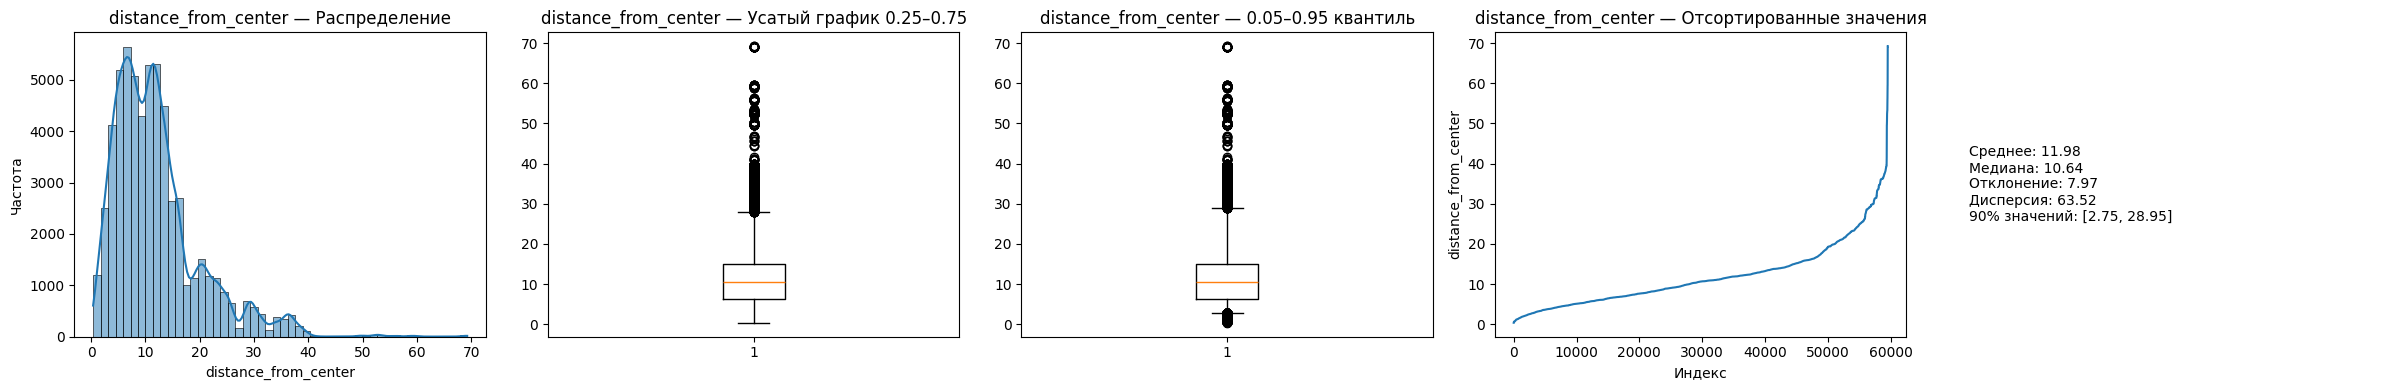

In [316]:
data = df.distance_from_center

fig, axes = plt.subplots(1, 5, figsize=(24, 4))

sns.histplot(data, bins=50, kde=True, ax=axes[0])
axes[0].set_title(f'distance_from_center — Распределение')
axes[0].set_xlabel('distance_from_center')
axes[0].set_ylabel('Частота')

axes[1].boxplot(data)
axes[1].set_title(f'distance_from_center — Усатый график 0.25–0.75')

p05 = data.quantile(0.05)
p95 = data.quantile(0.95)
axes[2].boxplot(data, whis=[5,95])
axes[2].set_title(f'distance_from_center — 0.05–0.95 квантиль')

axes[3].plot(sorted(data))
axes[3].set_title(f'distance_from_center — Отсортированные значения')
axes[3].set_xlabel('Индекс')
axes[3].set_ylabel('distance_from_center')

mean = num_stats["Среднее"]
median = num_stats["Медиана"]
std = num_stats["Отклонение"]
var = num_stats["Дисперсия"]

text = (
    f"Среднее: {mean:.2f}\n"
    f"Медиана: {median:.2f}\n"
    f"Отклонение: {std:.2f}\n"
    f"Дисперсия: {var:.2f}\n"
    f"90% значений: [{p05:.2f}, {p95:.2f}]"
)

axes[4].axis('off')
axes[4].text(0, 0.5, text, va='center', fontsize=10)

plt.tight_layout()
plt.show()

## На основе некоторых признаков были созданы (извлечены) другие

### address

- **okrug** — принадлежность к округу в рамках г. Москвы, например: ЗАО, САО и т.д. Если явно не указан — значение 'другое'.
- **district** — принадлежность к району в рамках г. Москвы, например: р-н Даниловский, р-н Москворечье-Сабурово и т.д. Если явно не указан — значение 'другое'.
- **metro_adress** — метро, которое указано в адресе. Если не указано — значение 'отсутствует'.

### seller

- **seller_type** — кто продает: агенство, застройщик, собственник и т.д.
- **seller_name** — имя/название продавца. В случае собственника — его ID.

### metro_info

- **fastest_mode** — какой способ добраться до метро быстрее всего (в минутах).
- **fastest_minutes** — сколько минут занимает путь до метро.
- **nearest_station** — ближайшая станция метро.
- **stations_nearby** — число станций метро поблизости.
- **nearest_station_open** — открыта ли ближайшая станция метро (бывает, что станция строится на момент объявления).

### highway_info

- **nearest_road** — ближайшее указанное шоссе (в км).
- **distance_from_mkad** — расстояние до МКАДа, если указано.
- **roads_nearby_count** — число шоссе поблизости.

### lat и lng

- **distance_from_center** - расстояние до центра

# Кирилл

## Значения признаков

In [317]:
data = df.copy()
data = data.drop(labels=['publication_date','request_time','lat','lng'],axis=1) # не несут в себе никакой смысловой нагрузки для min_max_range

stat = data.describe().T
concated_min_max_df = pd.concat([stat["min"],stat["max"]],axis=1)

pd.set_option('display.float_format', '{:.0f}'.format)
concated_min_max_df

,min,max
price,1850000,1036776399
total_area,8,200
living_area,-3,190
kitchen_area,0,92
ceiling_height,0,310
floor,-1,84
total_floors,1,97
combined_bathroom,1,5
separated_bathroom,0,9
year_of_construction,1820,2027


In [318]:
dig_columns = set(concated_min_max_df.index.tolist())
all_columns = set(data.columns.tolist())
object_columns = list(all_columns - dig_columns) # узнаём названия не числовых признаков и формируем из них список

In [319]:
data_object_columns = data[object_columns].copy()
data_object_columns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59546 entries, 0 to 63363
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   district               59546 non-null  object
 1   seller_type            25245 non-null  object
 2   nearest_road           5489 non-null   object
 3   construction_series    21566 non-null  object
 4   finishing              17414 non-null  object
 5   auction                59546 non-null  object
 6   seller_name            25245 non-null  object
 7   house_type             59546 non-null  object
 8   nearest_station        33837 non-null  object
 9   fastest_mode           33837 non-null  object
 10  rooms_count            59546 non-null  object
 11  metro_info             59081 non-null  object
 12  new_building           59546 non-null  object
 13  view_from_the_windows  33255 non-null  object
 14  accident_rate          34301 non-null  object
 15  metro_adress           5

In [320]:
#Избавляюсь от признаков object-typ'а, которые не несут информационной нагрузки для ...
#... выявления категориального диапазона в каждой колонке-признаке. Некоторые признаки...
#... были распарсены на предыдущем этапе EDA (address,metro_info,seller) -> избавляемся.

data_object_columns = data_object_columns.drop(labels=['address','description','url','photos_url','metro_info','seller'],axis=1)

In [321]:
data_object_uniques = data_object_columns.nunique(dropna=True)
data_object_uniques = data_object_uniques.to_frame().rename(columns= {0 : "unique_values"})
data_object_uniques

,unique_values
district,127
seller_type,7
nearest_road,30
construction_series,96
finishing,8
auction,1
seller_name,1597
house_type,7
nearest_station,325
fastest_mode,2


На количество уникальных значений для каждого рассматриваемого object-type признака датасета посмотрели, теперь выведем их уникальные значения на экран

In [322]:
# Считаем процентное распределение (включая NaN)
value_counts = df['construction_series'].value_counts(dropna=False)
percentages = (value_counts / len(df) * 100).round(2)

# Сводная таблица
summary_df = pd.DataFrame({
    'Количество': value_counts,
    'Процент': percentages
})

summary_df.sort_values('Процент',ascending=False).sort_values('Процент')

,Количество,Процент
construction_series,,
ii-29-160,1,0
п-23,1,0
п-4,1,0
ii-08,1,0
ii-68-03,1,0
...,...,...
ii-18,658,1
п-44,692,1
ii-49,872,1


In [323]:
df['construction_series'].unique()

array([nan, 'индивидуальный проект', 'п-3м', '1-511', 'гмс-1', 'ii-49',
       '1-515', 'и-209а', '1605-ам', '1-464', 'п-46м', 'ii-68', 'п-46',
       '1мг-601', 'ii-18-01/12', 'ii-18', 'ii-49д', '1-447', 'п-30',
       'ii-57', 'п-42', 'ii-05', '1-300', '1-464а', 'ii-29', 'п-44т',
       '111-90', 'и-700', 'п-44', 'и-580', '1-515/9м', 'и-155',
       'ii-68-01/16-83', 'п-47', 'копэ', 'ип-46с', 'п-55', 'ii-32', 'п-3',
       '1-510', 'ii-18-31/12', 'п-111м', '1-515/9юл', 'п-43', 'п-22',
       'п-44к', 'ii-18-31/12а', 'и-522а', 'и-209', 'и-491а',
       'башня вулыха', '1605-а', 'и-79-99', 'ii-68-01', 'пд-4',
       'ii-18-01/12а', 'ii-14', 'и-155мк', 'ii-68-01/12-83',
       'ii-29-41/37', 'ii-29-160', 'э-187', 'ii-20', 'и-241', '1-515/9',
       'ii-18-01/09', '1605-ам/12', '1-490', 'ii-28', 'п-22к', 'п-31',
       '111-м', 'п-44м', 'ii-03', 'и-700а', 'и-1724', 'ii-49п',
       'ii-68-02/16м', 'п-111', 'ii-18-02/12', 'п-44тм', 'ii-68-03',
       'п-55м', 'ii-17', 'пб-02', 'к-7', 'с-2

In [324]:
def get_unique_values(df : pd.DataFrame, column_name : str) -> np.ndarray:
  '''
  Function returns ndarray with unique values from column in pd.DataFrame object

  Args:
    :input: df -> pd.DataFrame object, column_name : str
    :returns: unique_values : np.ndarray
  '''

  data = df.copy()
  unique_values = data[column_name].unique()

  return unique_values

columns_to_collect = data_object_columns.columns.to_list()

for col in columns_to_collect:
  unique_values = get_unique_values(data_object_columns,col)
  print(f"{col}: {unique_values[:10]}")

district: ['р-н даниловский' 'р-н головинский' 'другое' 'р-н некрасовка'
 'р-н измайлово' 'р-н ховрино' 'р-н преображенское' 'р-н хорошевский'
 'р-н нижегородский' 'р-н нагорный']
seller_type: [None 'агентство недвижимости' 'автор объявления' 'застройщик'
 'собственник' 'консультант' 'представитель застройщика'
 'управляющая компания']
nearest_road: [nan 'калужское шоссе' 'косинское шоссе' 'варшавское шоссе'
 'пятницкое шоссе' 'ленинградское шоссе' 'киевское шоссе'
 'новорижское шоссе' 'сколковское шоссе' 'боровское шоссе']
construction_series: [nan 'индивидуальный проект' 'п-3м' '1-511' 'гмс-1' 'ii-49' '1-515'
 'и-209а' '1605-ам' '1-464']
finishing: [nan 'чистовая' 'нет информации' 'без отделки' 'предчистовая'
 'чистовая с мебелью' 'черновая' 'под ключ' 'с отделкой']
auction: ['н']
seller_name: [None 'ордер' 'id 135186715' 'брусника' 'moneyard' 'cristall group'
 'юрмаст' 'моя столица' 'этажи москва' 'смарент']
house_type: ['кирпичный' 'монолитный' 'панельный' 'блочный' 'сталинский' 'д

## Выбросы

In [325]:
#IQR, Z-Score, quantile

def processing_outliers_iqr(df: pd.DataFrame, column_name: str) -> pd.DataFrame():
    '''
    Function returns pd.DataFrame without outliers, calculated by IQR

    Args:
        :input: df -> pd.DataFrame, column_name : str
        :returns: data_wo_outliers : pd.DataFrame, data_with_outliers_flag : pd.DataFrame
    '''
    data = df.copy()

    Q1 = data[column_name].quantile(0.25)
    Q3 = data[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR * 1.5
    upper_bound = Q3 + IQR * 1.5

    non_outliers_mask = (data[column_name] >= lower_bound) & (data[column_name] <= upper_bound)

    data_wo_outliers = data[non_outliers_mask]

    return data_wo_outliers

def processing_outliers_z_score(df : pd.DataFrame, column_name : str, threshold : int = 3) -> pd.DataFrame:
  '''
  Function returns pd.DataFrame without outliers, calculated by Z-Score

  Args:
    :input: df -> pd.DataFrame, column_name : str, threshold : int
    :returns: data_wo_outliers : pd.DataFrame
  '''
  data = df.copy()
  z_scores = np.abs(stats.zscore(data[column_name].dropna()))
  mask = pd.Series(True, index=data.index)

  notna_mask = data[column_name].notna()
  mask[notna_mask] = z_scores < threshold

  data_wo_outliers = data[mask]
  return data_wo_outliers

def processing_outliers_percentile(df : pd.DataFrame, column_name : str, lower_percentile : int = 5, upper_percentile : int = 95) -> pd.DataFrame:
    '''
    Function returns pd.DataFrame without outliers, calculated by percentile

    Args:
      :input: df -> pd.DataFrame, column_name : str, lower_percentile : int, upper_percentile : int
      :returns: data_wo_outliers : pd.DataFrame
    '''

    data = df.copy()
    lower_bound = data[column_name].quantile(lower_percentile / 100)
    upper_bound = data[column_name].quantile(upper_percentile / 100)

    data_wo_outliers = data[(data[column_name] >= lower_bound) & (data[column_name] <= upper_bound)]

    return data_wo_outliers

def detect_categorical_outliers(df, column_name, threshold=0.01):
    '''
    Function returns pd.DataFrame without outliers

    Args:
      :input: df -> pd.DataFrame, column_name : str, threshold : int
      :returns: data_wo_outliers : pd.DataFrame
    '''
    data = df.copy()

    freq = df[column_name].value_counts(normalize=True)
    outlier_categories = freq[freq < threshold].index.tolist()

    data['outlier'] = df[column_name].isin(outlier_categories)

    return data, outlier_categories

df_with_outliers, outlier_categories = detect_categorical_outliers(data, 'finishing', threshold=0.01)

data_iqr = processing_outliers_iqr(data,"price")
df_clean_iqr = data_iqr.dropna(subset=['price'])

data_z_score = processing_outliers_z_score(data,"price")
df_clean_z_score = data_z_score.dropna(subset=['price'])

data_percentile = processing_outliers_percentile(data,"price",1,99)
df_clean_percentile = data_percentile.dropna(subset=['price'])

print(f"orig shape: {data.shape}")
print(f"IQR shape: {df_clean_iqr.shape}")
print(f"Z-Score shape: {df_clean_z_score.shape}")
print(f"Percentile shape: {df_clean_percentile.shape}")
print(f"\nPercentage of IQR outliers: {np.abs((((df_clean_iqr.shape[0] / data.shape[0]) * 100) - 100)):.2f}%")
print(f"Percentage of Z-Score outliers: {np.abs((((df_clean_z_score.shape[0] / data.shape[0]) * 100) - 100)):.2f}%")
print(f"Percentage of Percentile outliers: {np.abs((((df_clean_percentile.shape[0] / data.shape[0]) * 100) - 100)):.2f}%")

orig shape: (59546, 48)
IQR shape: (53486, 48)
Z-Score shape: (58315, 48)
Percentile shape: (58365, 48)

Percentage of IQR outliers: 10.18%
Percentage of Z-Score outliers: 2.07%
Percentage of Percentile outliers: 1.98%


Как можно заметить, наиболее высокие показатели выбросов в данных получаются из метерики IQR. С точки зрения теории, IQR должен давать примерно по 0,7 % среза с каждой стороны -> ~1.5%. Однако, большое значение указывает на неправильность выбора метода расчёта выбросов (12 процентов всего датасета - очень много для отсечения). Метрики Z-Score и Percentile дают примерно схожий результат в районе 1.8%.

Далее для отсечения выбрана метрика Percentile по несокльким причинам: 1) используя данную метрику мы отсекаем только ~2% данных по проценту с каждой стороны (нижняя и верхняя граница), интерпретируя: рассматриваем 98% данных по рынку недвижимости в г. Москва по данным cian. 2) Данная метрика независима от формы и закона распределения.



In [326]:
'''
Обрабатываем категориальные признаки
'''
problem_count = (
    df['house_type'].isin(['сталинка', 'деревянный', 'сталинский']).astype(int) +
    df['heating'].isin(['электрическое', 'нет', 'котел/квартирное отопление', 'автономная котельная']).astype(int) +
    (df['parking'] == 'на крыше').astype(int) +
    df['floor_type'].isin(['смешанные', 'деревянные']).astype(int) +
    df['finishing'].isin(['с отделкой', 'под ключ', 'чистовая с мебелью', 'черновая', 'нет информации']).astype(int) +
    df['seller_type'].isin(['управляющая компания', 'представитель застройщика']).astype(int) +
    df['apartment_newbuilding'].isin(['пентхаус вторичка', 'пентхаус новостройка']).astype(int)
)

orig_shape = df.shape
print(f"Оригинальный размер строк датасета: {orig_shape[0]}")
df = df[problem_count < 1]
df_filtered_shape = df.shape
print(f"Размер датасета после обработки проблемных строк: {df.shape[0]}")
print(f"Процент отсечённых значений: {np.abs((((df.shape[0] / orig_shape[0]) * 100) - 100)):.2f}%")

Оригинальный размер строк датасета: 59546
Размер датасета после обработки проблемных строк: 57431
Процент отсечённых значений: 3.55%


In [327]:
'''
Обрабатываем числовые признаки
'''
df = df[(df['price'] <= 60000000)
      & (df['total_area'] <= 150)
      & (df['living_area'] <= 110)
      & (df['kitchen_area'] <= 40)
      & (df['floor'] <= 50)
      & (df['total_floors'] <= 60)
      & (df['combined_bathroom'] <= 2)
      & (df['separated_bathroom'] <= 2)
      & ((df['year_of_construction'] >= 1950) | (df['year_of_construction'].isna()))
      & ((df['ceiling_height'] >= 2.5)
      & (df['ceiling_height'] <= 3.5))
      & (df['passenger_elevator'] <= 4)
      & (df['cargo_elevator'] <= 5)
      & (df['distance_from_center'] <= 40)
      & ((df['entrances'] <=100) | (df['entrances'].isna()))]

print(f"Размер датасета до обработки числовых признаков: {df_filtered_shape[0]}")
df = df[problem_count < 1]
print(f"Размер датасета после обработки проблемных строк: {df.shape[0]}")
print(f"Процент отсечённых строк: {np.abs((((df.shape[0] / df_filtered_shape[0]) * 100) - 100)):.2f}%")

Размер датасета до обработки числовых признаков: 57431
Размер датасета после обработки проблемных строк: 28185
Процент отсечённых строк: 50.92%


C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\1516105459.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[problem_count < 1]


# Настя

## Матрица корреляции числовых переменных

In [328]:
columns_list = [
    'price',
    'total_area',
    'living_area',
    'kitchen_area',
    'ceiling_height',
    'floor',
    'total_floors',
    'combined_bathroom',
    'separated_bathroom',
    'year_of_construction',
    'passenger_elevator',
    'cargo_elevator',
    'entrances',
    'loggia_balcony',
    'fastest_minutes',
    'stations_nearby',
    'distance_from_mkad',
    'roads_nearby_count'
]

In [329]:
#отбираем числовые значения
corr_matrix = df[columns_list].corr()

# Форматируем с 3 знаками после запятой и цветовой индикацией
def color_corr(val):
    # Получаем абсолютное значение корреляции
    abs_val = abs(val)

    # Чем ближе к 1, тем насыщеннее зеленый (для положительных) или красный (для отрицательных)
    if val >= 0:
        # От бледного зеленого к насыщенному зеленому
        intensity = int(255 * (1 - abs_val))
        return f'background-color: rgb({intensity}, 255, {intensity}); color: black'
    else:
        # От бледного красного к насыщенному красному
        intensity = int(255 * (1 - abs_val))
        return f'background-color: rgb(255, {intensity}, {intensity}); color: black'

# Применяем стиль и форматирование
corr_matrix = corr_matrix.round(3).style\
    .applymap(color_corr)\
    .format("{:.3f}")

# Отображаем
corr_matrix

C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\1924527273.py:21: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_corr)\


,price,total_area,living_area,kitchen_area,ceiling_height,floor,total_floors,combined_bathroom,separated_bathroom,year_of_construction,passenger_elevator,cargo_elevator,entrances,loggia_balcony,fastest_minutes,stations_nearby,distance_from_mkad,roads_nearby_count
price,1.000,0.699,0.549,0.534,0.492,0.248,0.335,0.402,0.145,0.244,0.201,0.214,0.046,0.318,-0.047,-0.025,-0.313,-0.241
total_area,0.699,1.000,0.871,0.496,0.185,0.084,0.093,0.435,0.405,0.104,0.041,0.091,0.039,0.595,-0.010,-0.014,-0.076,0.019
living_area,0.549,0.871,1.000,0.177,0.084,-0.012,-0.041,0.313,0.397,-0.023,0.006,-0.028,0.030,0.566,-0.026,-0.013,-0.061,0.043
kitchen_area,0.534,0.496,0.177,1.000,0.307,0.246,0.340,0.356,0.047,0.443,0.123,0.310,0.040,0.182,0.041,-0.016,-0.084,-0.056
ceiling_height,0.492,0.185,0.084,0.307,1.000,0.184,0.284,0.171,-0.097,0.363,0.181,0.185,0.101,-0.161,0.053,-0.016,0.021,-0.137
floor,0.248,0.084,-0.012,0.246,0.184,1.000,0.635,0.099,-0.054,0.398,0.276,0.353,-0.030,-0.101,0.033,-0.018,-0.162,-0.097
total_floors,0.335,0.093,-0.041,0.340,0.284,0.635,1.000,0.125,-0.100,0.583,0.398,0.493,-0.048,-0.194,0.061,-0.020,-0.315,-0.161
combined_bathroom,0.402,0.435,0.313,0.356,0.171,0.099,0.125,1.000,-0.125,0.202,0.094,0.162,0.017,0.182,0.014,-0.008,-0.061,-0.057
separated_bathroom,0.145,0.405,0.397,0.047,-0.097,-0.054,-0.100,-0.125,1.000,-0.086,-0.037,-0.079,0.025,0.380,-0.033,-0.003,-0.011,0.085
year_of_construction,0.244,0.104,-0.023,0.443,0.363,0.398,0.583,0.202,-0.086,1.000,0.307,0.653,0.090,-0.068,0.112,-0.026,-0.017,0.239


In [330]:
corr_matrix = df[columns_list].corr()
price_corr = corr_matrix['price'].drop('price')

# Функция для определения силы корреляции
def get_correlation_strength(corr_value):
    abs_corr = abs(corr_value)
    if abs_corr >= 0.7:
        return "Очень сильная"
    elif abs_corr >= 0.5:
        return "Сильная"
    elif abs_corr >= 0.3:
        return "Умеренная"
    elif abs_corr >= 0.1:
        return "Слабая"
    else:
        return "Очень слабая или отсутствует"

# Сортируем по абсолютному значению корреляции
price_corr_sorted = price_corr.sort_values(key=abs, ascending=False)

# Выводим таблицу
print("Корреляция переменных с целевой (price):")
print("-" * 70)

for var, corr_value in price_corr_sorted.items():
    strength = get_correlation_strength(corr_value)
    direction = "положительная" if corr_value > 0 else "отрицательная"
    print(f"{var:25} | {corr_value:7.3f} | {strength:20} ({direction})")

Корреляция переменных с целевой (price):
----------------------------------------------------------------------
total_area                |   0.699 | Сильная              (положительная)
living_area               |   0.549 | Сильная              (положительная)
kitchen_area              |   0.534 | Сильная              (положительная)
ceiling_height            |   0.492 | Умеренная            (положительная)
combined_bathroom         |   0.402 | Умеренная            (положительная)
total_floors              |   0.335 | Умеренная            (положительная)
loggia_balcony            |   0.318 | Умеренная            (положительная)
distance_from_mkad        |  -0.313 | Умеренная            (отрицательная)
floor                     |   0.248 | Слабая               (положительная)
year_of_construction      |   0.244 | Слабая               (положительная)
roads_nearby_count        |  -0.241 | Слабая               (отрицательная)
cargo_elevator            |   0.214 | Слабая               (пол

## Гистограмма распределения числовых переменных

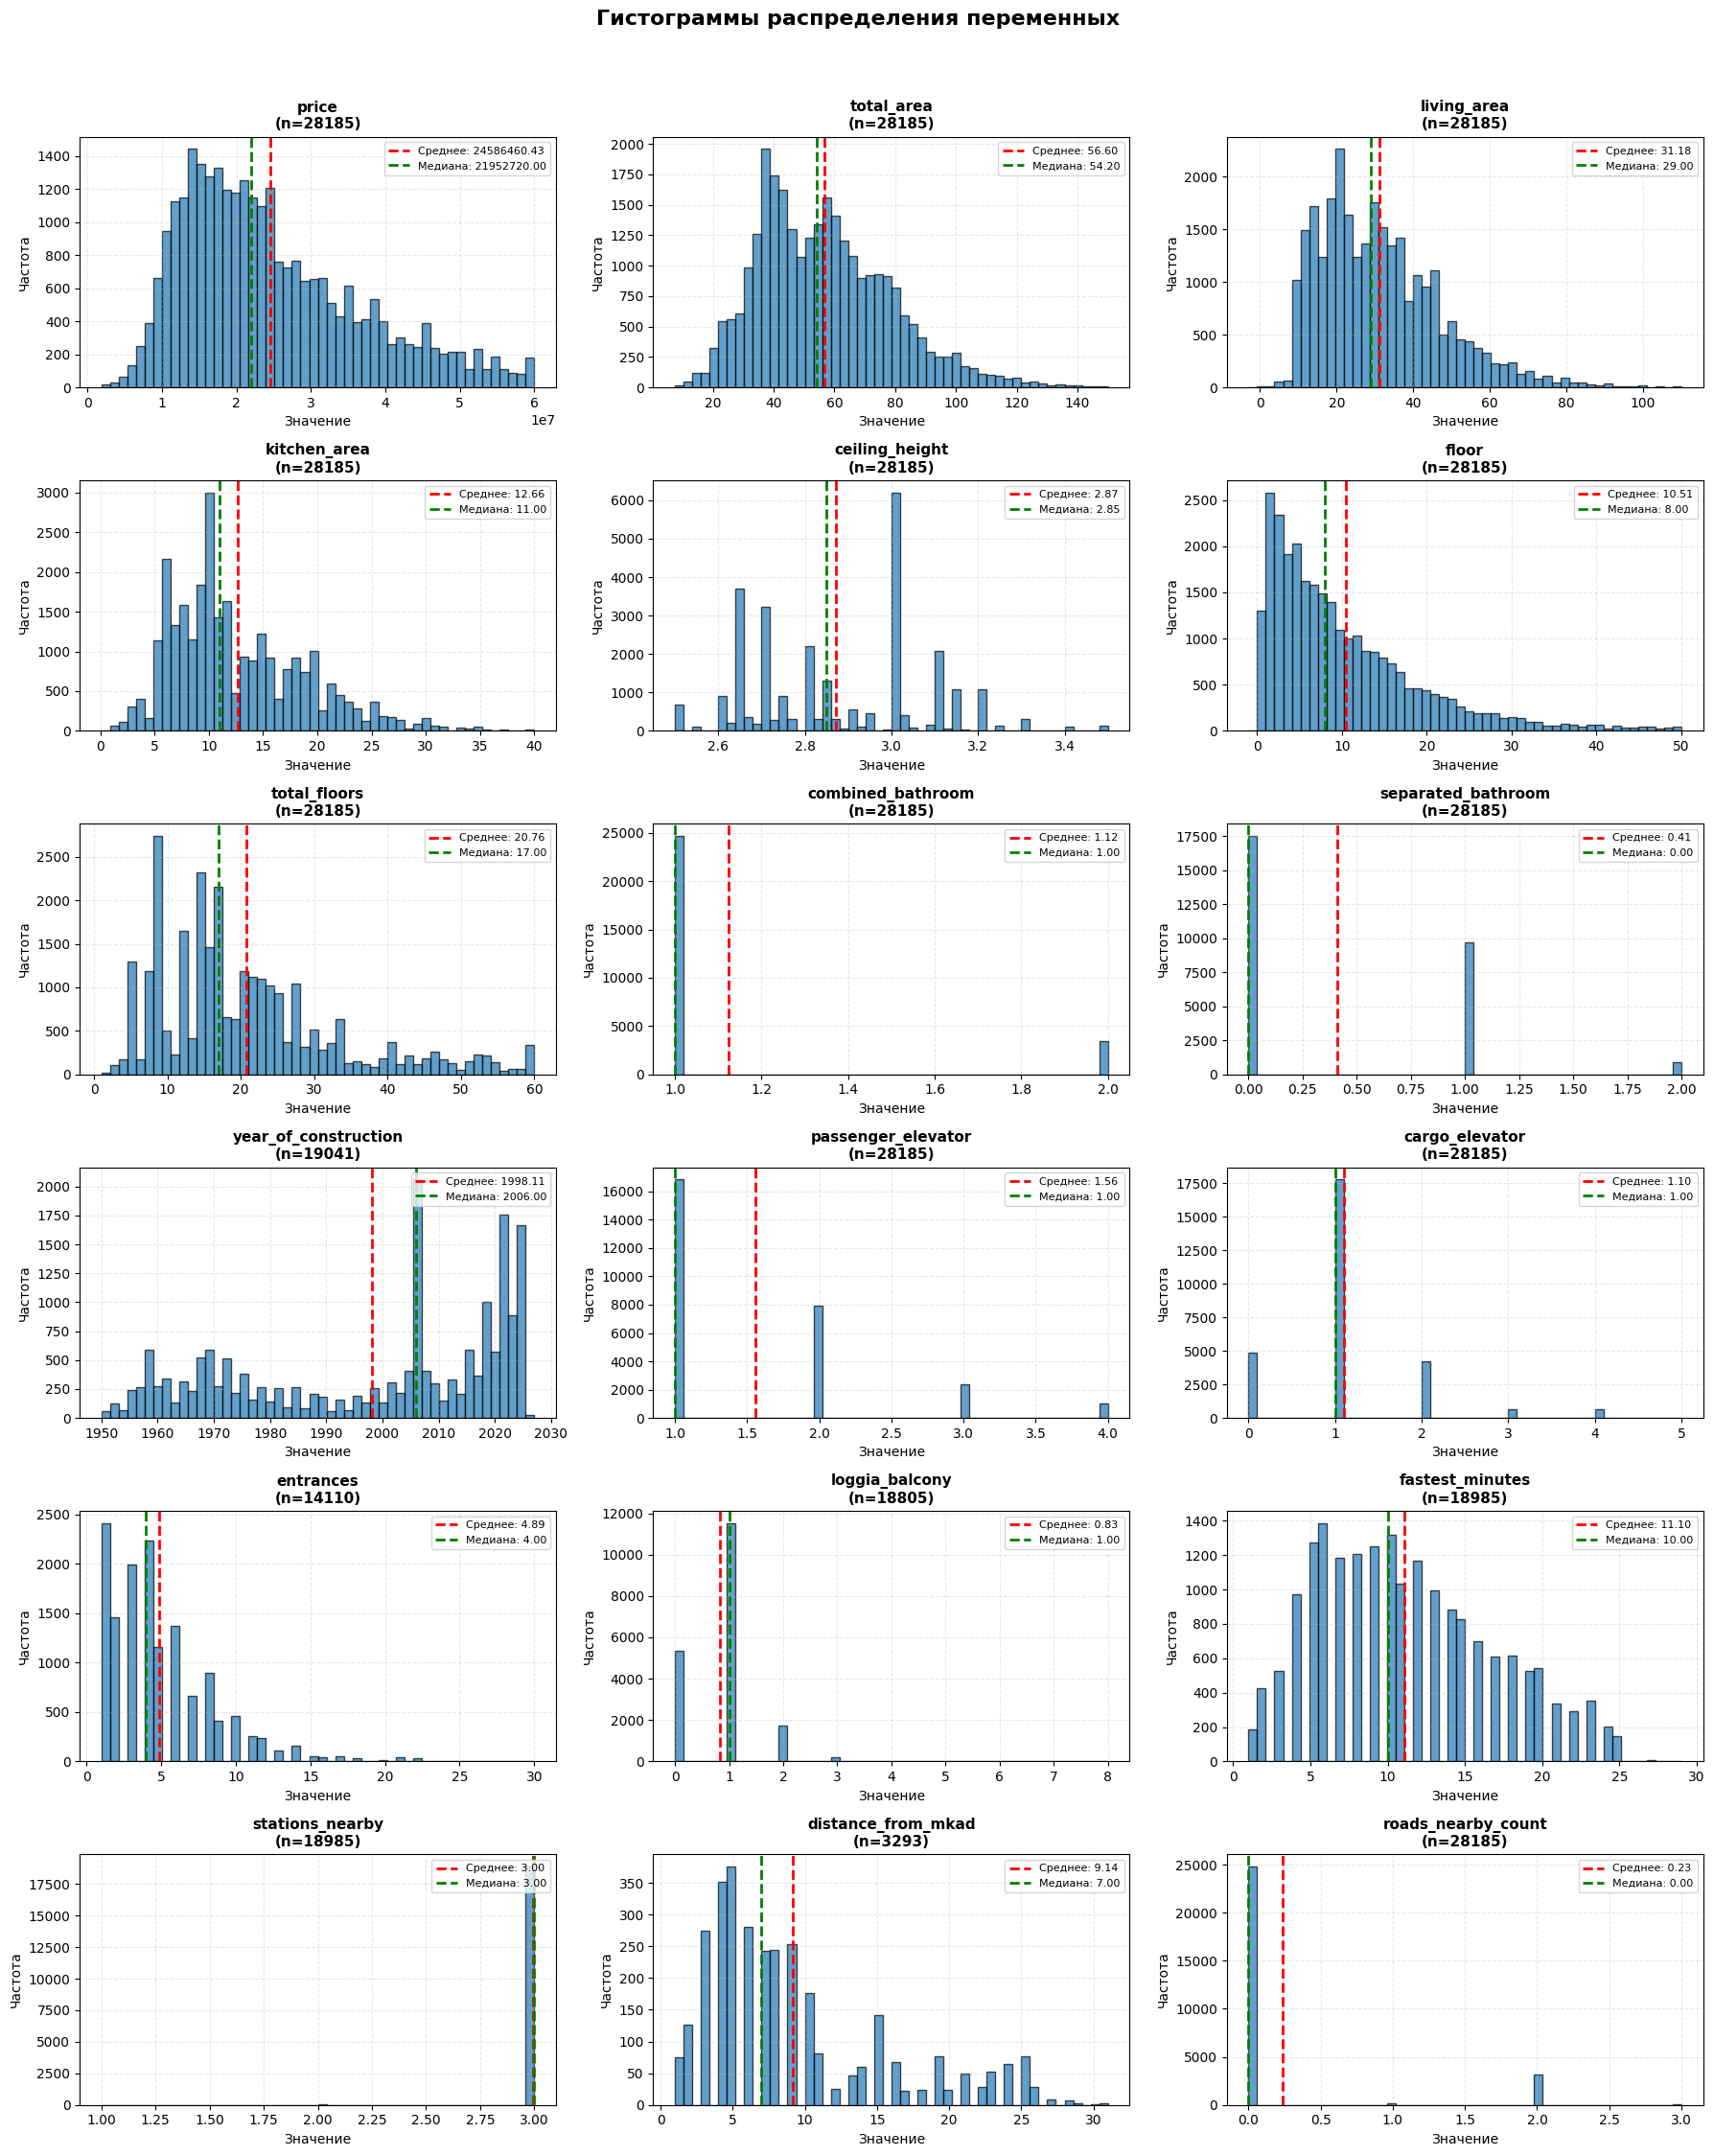

In [331]:
# Фильтруем только те колонки, которые есть в датафрейме
available_columns = df[columns_list]

fig, axes = plt.subplots(6, 3, figsize=(18, 22))
axes = axes.flatten()

for idx, col in enumerate(available_columns):
    if idx < len(axes):
        ax = axes[idx]

        # Удаляем пропуски
        data_no_nan = df[col].dropna()

        if len(data_no_nan) > 0:
            # Создаем гистограмму
            n, bins, patches = ax.hist(data_no_nan, bins=50, alpha=0.7,
                                      edgecolor='black', density=False)

            # Добавляем вертикальные линии для статистики
            mean_val = data_no_nan.mean()
            median_val = data_no_nan.median()

            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                      label=f'Среднее: {mean_val:.2f}')
            ax.axvline(median_val, color='green', linestyle='--', linewidth=2,
                      label=f'Медиана: {median_val:.2f}')

            # Настройка заголовка и меток
            ax.set_title(f'{col}\n(n={len(data_no_nan)})', fontsize=11, fontweight='bold')
            ax.set_xlabel('Значение')
            ax.set_ylabel('Частота')

            # Добавляем легенду
            ax.legend(loc='upper right', fontsize=8)

            # Настраиваем сетку
            ax.grid(True, alpha=0.3, linestyle='--')

            # Автоматическое форматирование оси X для больших чисел
            if data_no_nan.max() > 10000:
                ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        else:
            ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(col, fontsize=11, fontweight='bold')
            ax.set_axis_off()

# Скрываем пустые subplots
for idx in range(len(available_columns), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Гистограммы распределения переменных', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

## Парные распределения ключевых переменных

<Figure size 1400x1200 with 0 Axes>

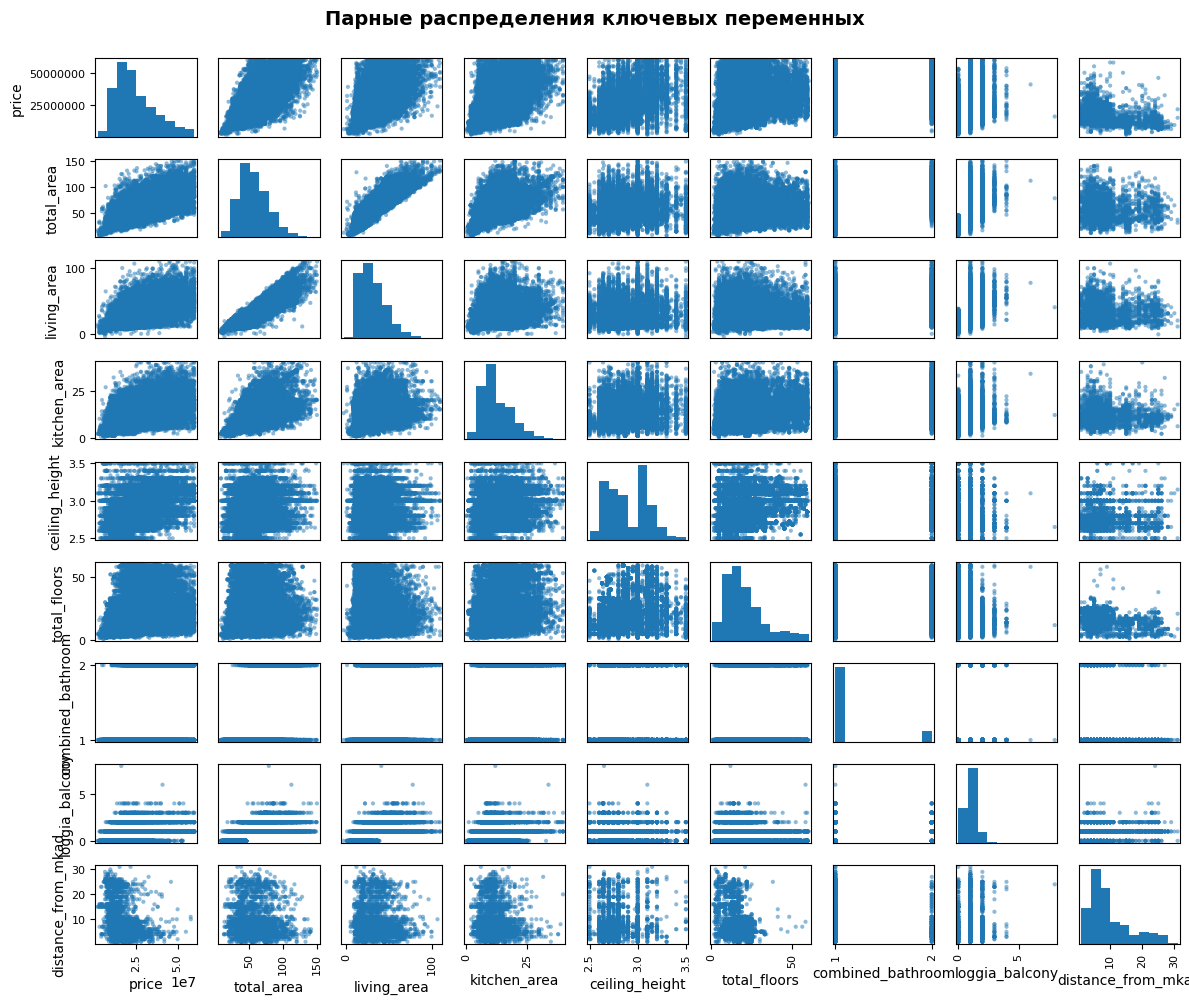

In [332]:
# Выбираем сильно и умеренно коррелированные с price переменные
top_vars = ['price'] + list(price_corr[abs(price_corr) >= 0.3].index)

fig = plt.figure(figsize=(14, 12))
pd.plotting.scatter_matrix(df[top_vars], diagonal='hist', alpha=0.5, figsize=(12, 10))
plt.suptitle('Парные распределения ключевых переменных', fontsize=14, fontweight='bold', y=1)
plt.tight_layout()
plt.savefig('scatter_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Категориальные переменные

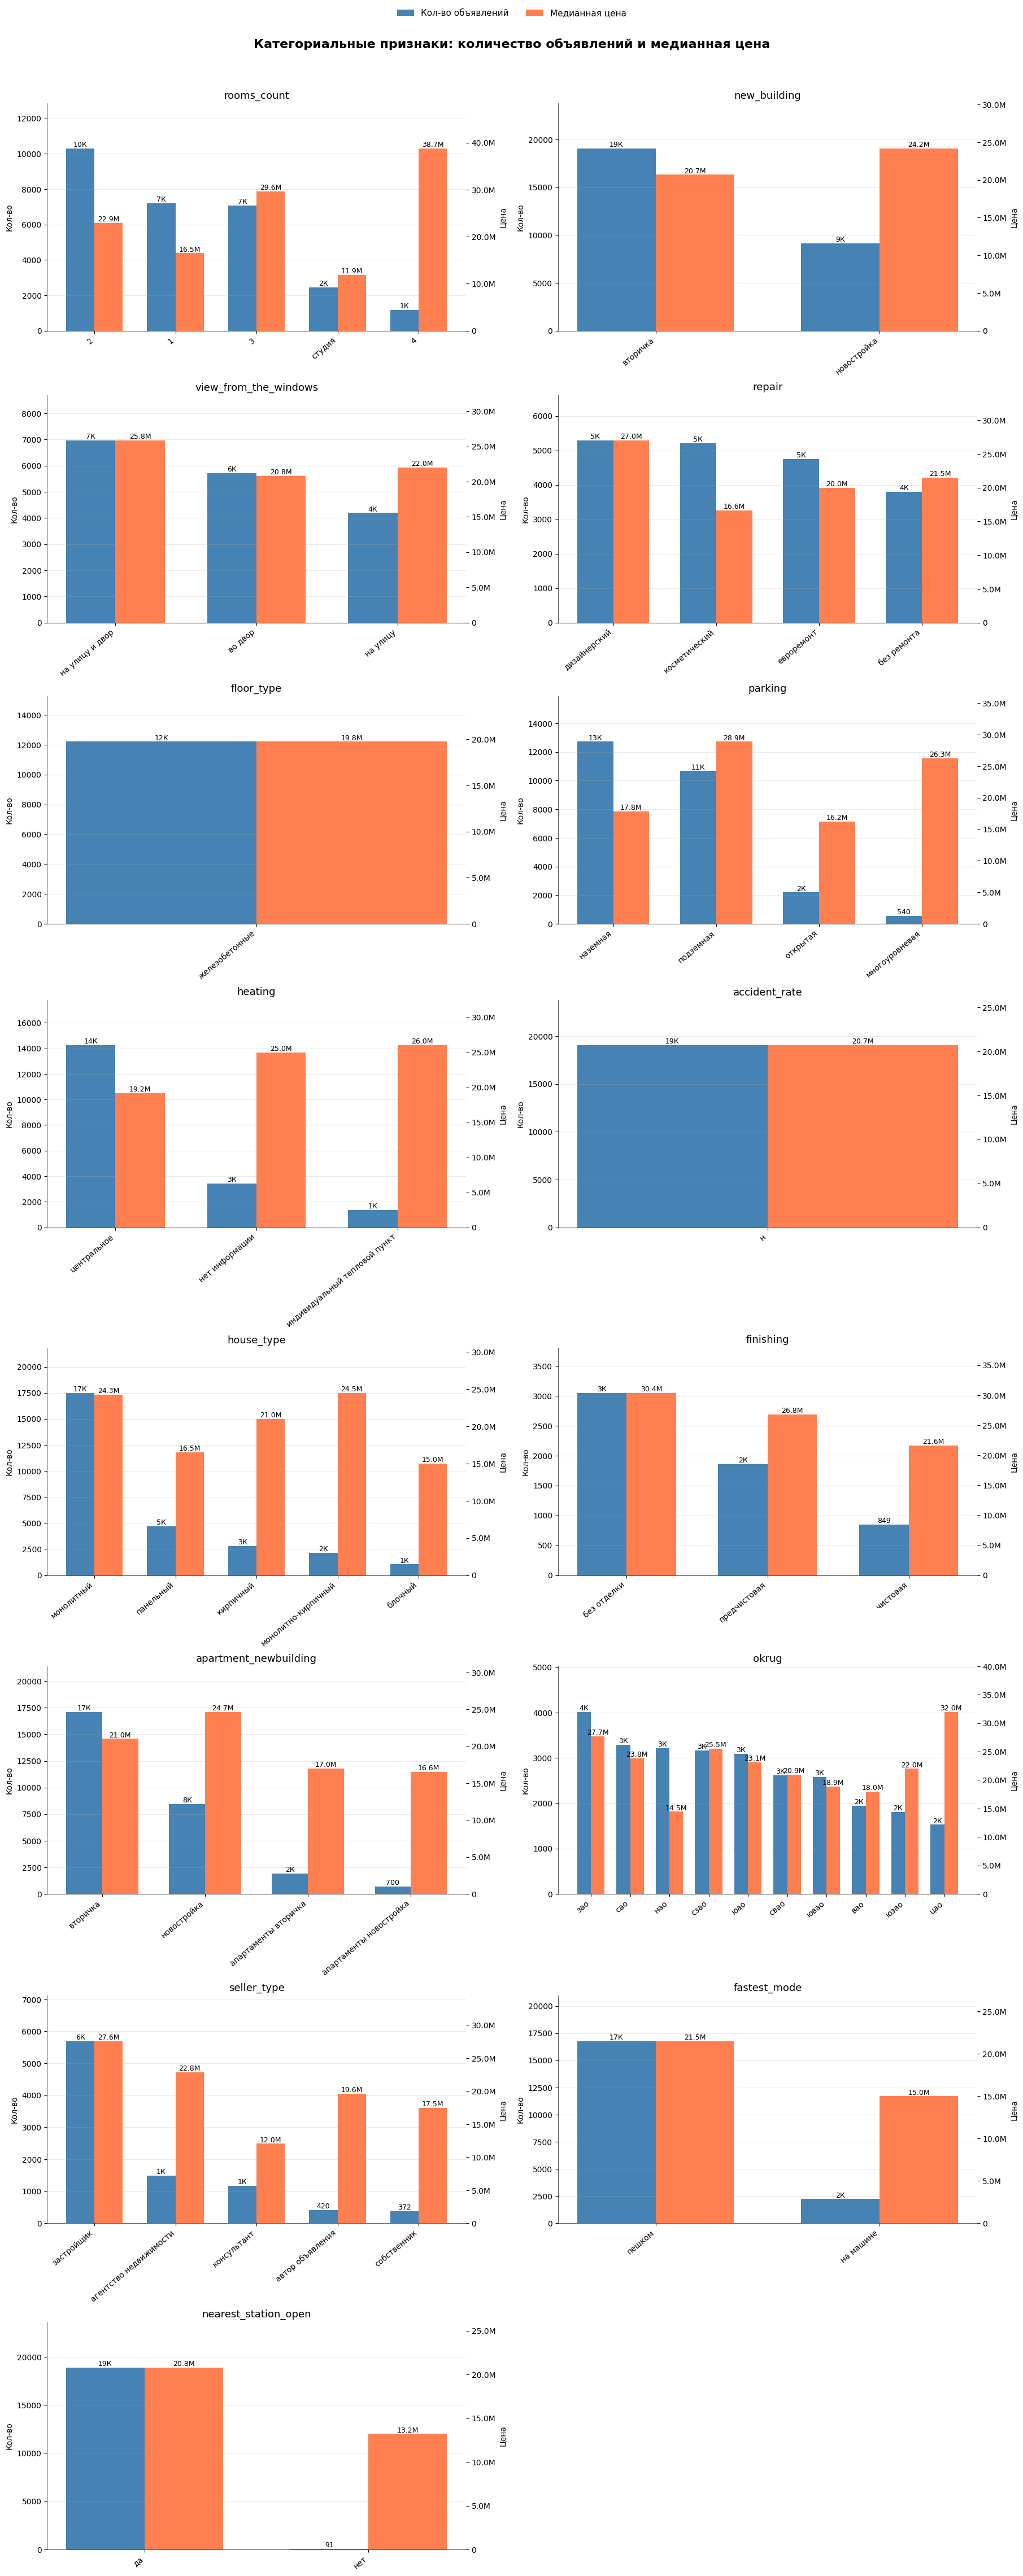

In [333]:
# Категориальные признаки
categorical_cols = [
    'rooms_count',
    'new_building',
    'view_from_the_windows',
    'repair',
    'floor_type',
    'parking',
    'heating',
    'accident_rate',
    'house_type',
    'finishing',
    'apartment_newbuilding',
    'okrug',
    'seller_type',
    'fastest_mode',
    'nearest_station_open'
]

# Форматирование чисел
def format_number(x):
    if abs(x) >= 1e6:
        return f'{x/1e6:.1f}М'
    elif abs(x) >= 1e3:
        return f'{x/1e3:.0f}К'
    else:
        return f'{x:.0f}'

# Параметры сетки
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5.5 * n_rows),
    constrained_layout=True
)

axes = axes.flatten()

fig.suptitle(
    'Категориальные признаки: количество объявлений и медианная цена',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

for idx, col in enumerate(categorical_cols):
    if col not in df.columns:
        continue

    ax1 = axes[idx]

    # Топ-10 категорий по количеству
    counts = df[col].value_counts().head(10)
    categories = counts.index

    # Медианная цена по тем же категориям
    median_price = (
        df[df[col].isin(categories)]
        .groupby(col)['price']
        .median()
        .reindex(categories)
    )

    x = np.arange(len(categories))
    width = 0.35

    # --- Количество объявлений ---
    bars_count = ax1.bar(
        x - width / 2,
        counts.values,
        width,
        color='steelblue'
    )

    ax1.set_ylabel('Кол-во')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=40, ha='right')
    ax1.grid(axis='y', alpha=0.25)
    ax1.set_ylim(0, counts.max() * 1.25)

    for bar, value in zip(bars_count, counts.values):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            format_number(value),
            ha='center',
            va='bottom',
            fontsize=9
        )

    # --- Вторая ось: медианная цена ---
    ax2 = ax1.twinx()

    bars_price = ax2.bar(
        x + width / 2,
        median_price.values,
        width,
        color='coral'
    )

    ax2.set_ylabel('Цена')
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: format_number(x))
    )
    ax2.set_ylim(0, median_price.max() * 1.25)

    for bar, value in zip(bars_price, median_price.values):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            format_number(value),
            ha='center',
            va='bottom',
            fontsize=9
        )

    # --- Косметика рамок ---
    for ax in (ax1, ax2):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_alpha(0.4)
        ax.spines['bottom'].set_alpha(0.4)

    ax1.set_title(col, fontsize=13)

# Отключаем пустые оси
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

# --- Общая легенда на всё полотно ---
legend_elements = [
    Patch(facecolor='steelblue', label='Кол-во объявлений'),
    Patch(facecolor='coral', label='Медианная цена')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=2,
    fontsize=11,
    frameon=False,
    bbox_to_anchor=(0.5, 1.035)
)

plt.savefig('category.png', dpi=300, bbox_inches='tight')
plt.show()

# Никита

Смотрел на данные и задавал вопросы/проверял гипотезы с точки зрения "бизнес"-задачи (т.е. вопросы больше не технического характера, а прикладного)

## Вопрос 1: Как влияет отделка на цену квартиры?

---

**а) Выгодно ли покупателю первички брать квартиру без отделки и делать ремонт самому? Или лучше брать с ремонтом от застройщика?**

In [334]:
df_new_buildings = df[df['new_building'] == 'новостройка']
df_new_buildings['finishing'].value_counts()

finishing
без отделки     3046
предчистовая    1855
чистовая         849
Name: count, dtype: int64

In [335]:
df_new_buildings['price_per_sq_m'] = df_new_buildings['price'] * 1.0 / df_new_buildings['total_area']

C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\3042942853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_buildings['price_per_sq_m'] = df_new_buildings['price'] * 1.0 / df_new_buildings['total_area']


In [336]:
# Оставим только тип отделки "без отделки", "чистовая" и "предчистовая" - в этих группах больше данных, сравнения корректнее
df_new_buildings = df_new_buildings[(df_new_buildings['finishing'] == 'без отделки') | (df_new_buildings['finishing'] == 'предчистовая') | (df_new_buildings['finishing'] == 'чистовая')]

C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\591722377.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='finishing', y='price', data=df_filtered, ax=ax1, palette=palette)
C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\591722377.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='finishing', y='price', data=df_filtered, ax=ax2, palette=palette, inner='quartile')
C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\591722377.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y):,}' for y in y_ticks])
C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\591722377

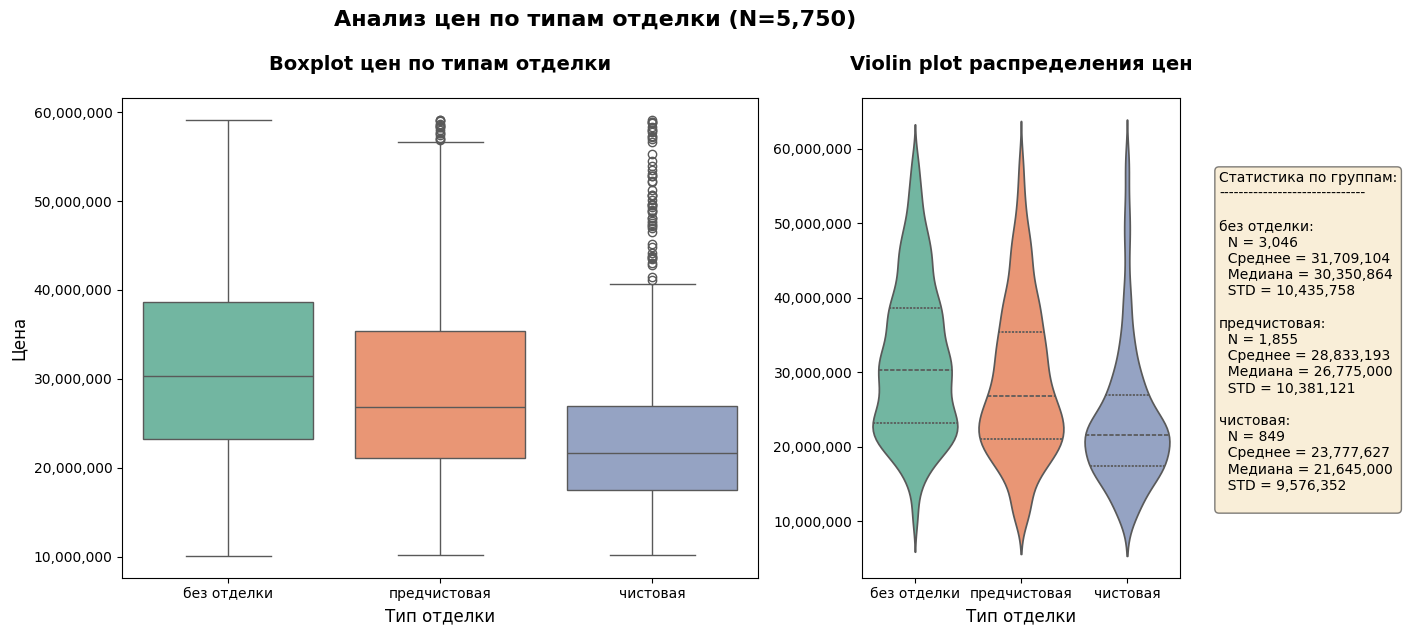

In [337]:
def plot_price_boxplots_by_finishing(df, figsize=(12, 6), show_stats=True, palette='Set2'):
    # Создаем фигуру и оси
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize,
                                    gridspec_kw={'width_ratios': [2, 1]})

    # Убираем выбросы для более читаемого графика
    # Используем межквартильный размах для определения выбросов
    Q1 = df['price'].quantile(0.25)
    Q3 = df['price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Фильтруем данные для boxplot (опционально, можно убрать)
    df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

    # 1. Boxplot с помощью seaborn (более красивый)
    sns.boxplot(x='finishing', y='price', data=df_filtered, ax=ax1, palette=palette)

    # Настройки первого графика
    ax1.set_title('Boxplot цен по типам отделки', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel('Тип отделки', fontsize=12)
    ax1.set_ylabel('Цена', fontsize=12)
    ax1.tick_params(axis='x', rotation=45 if len(df['finishing'].unique()) > 3 else 0)

    # 2. Violin plot для сравнения распределений (альтернатива boxplot)
    sns.violinplot(x='finishing', y='price', data=df_filtered, ax=ax2, palette=palette, inner='quartile')

    # Настройки второго графика
    ax2.set_title('Violin plot распределения цен', fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('Тип отделки', fontsize=12)
    ax2.set_ylabel('')
    ax2.tick_params(axis='x', rotation=45 if len(df['finishing'].unique()) > 3 else 0)

    # Форматирование осей Y (например, для денежных значений)
    for ax in [ax1, ax2]:
        # Форматируем подписи оси Y
        y_ticks = ax.get_yticks()
        if y_ticks.max() > 1000:
            # Форматируем большие числа
            ax.set_yticklabels([f'{int(y):,}' for y in y_ticks])

    # Если требуется, добавляем статистику
    if show_stats:
        # Вычисляем базовую статистику
        stats_text = "Статистика по группам:\n"
        stats_text += "-" * 30 + "\n"

        for finish_type in sorted(df['finishing'].unique()):
            group_data = df[(df['finishing'] == finish_type)]['price'].dropna()
            if len(group_data) > 0:
                stats_text += f"\n{finish_type}:\n"
                stats_text += f"  N = {len(group_data):,}\n"
                stats_text += f"  Среднее = {group_data.mean():,.0f}\n"
                stats_text += f"  Медиана = {group_data.median():,.0f}\n"
                stats_text += f"  STD = {group_data.std():,.0f}\n"

        # Добавляем текст со статистикой
        plt.figtext(1.02, 0.5, stats_text, fontsize=10,
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Настраиваем layout
    plt.tight_layout()

    # Добавляем общий заголовок
    plt.suptitle(f'Анализ цен по типам отделки (N={len(df):,})',
                 fontsize=16, fontweight='bold', y=1.05)

    return fig

f = plot_price_boxplots_by_finishing(df_new_buildings)
plt.show()

Получается немного контринтуитивная ситуация: квартиры без отделки стоят дороже, чем с отделкой.  
Однако это также зависит от округа: в ЦАО, например, всё выглядит логично (см. ниже)  

Предполагаю, так получается по следующим причинам:
- Есть зависимость от класса жилья. Элитная недвижимость продаётся без отделки, т.к. [будущие] владельцы отделывают под себя индивидуально.
- Большая часть квартир (порядка 60%) сдаются без отделки - выборка больше, цена "реальнее". Квартир с отделкой меньше, соответственно могут быть ошибочные данные
- Неконсистентность понятий: у разных застройщиков "без отделки" может означать разное

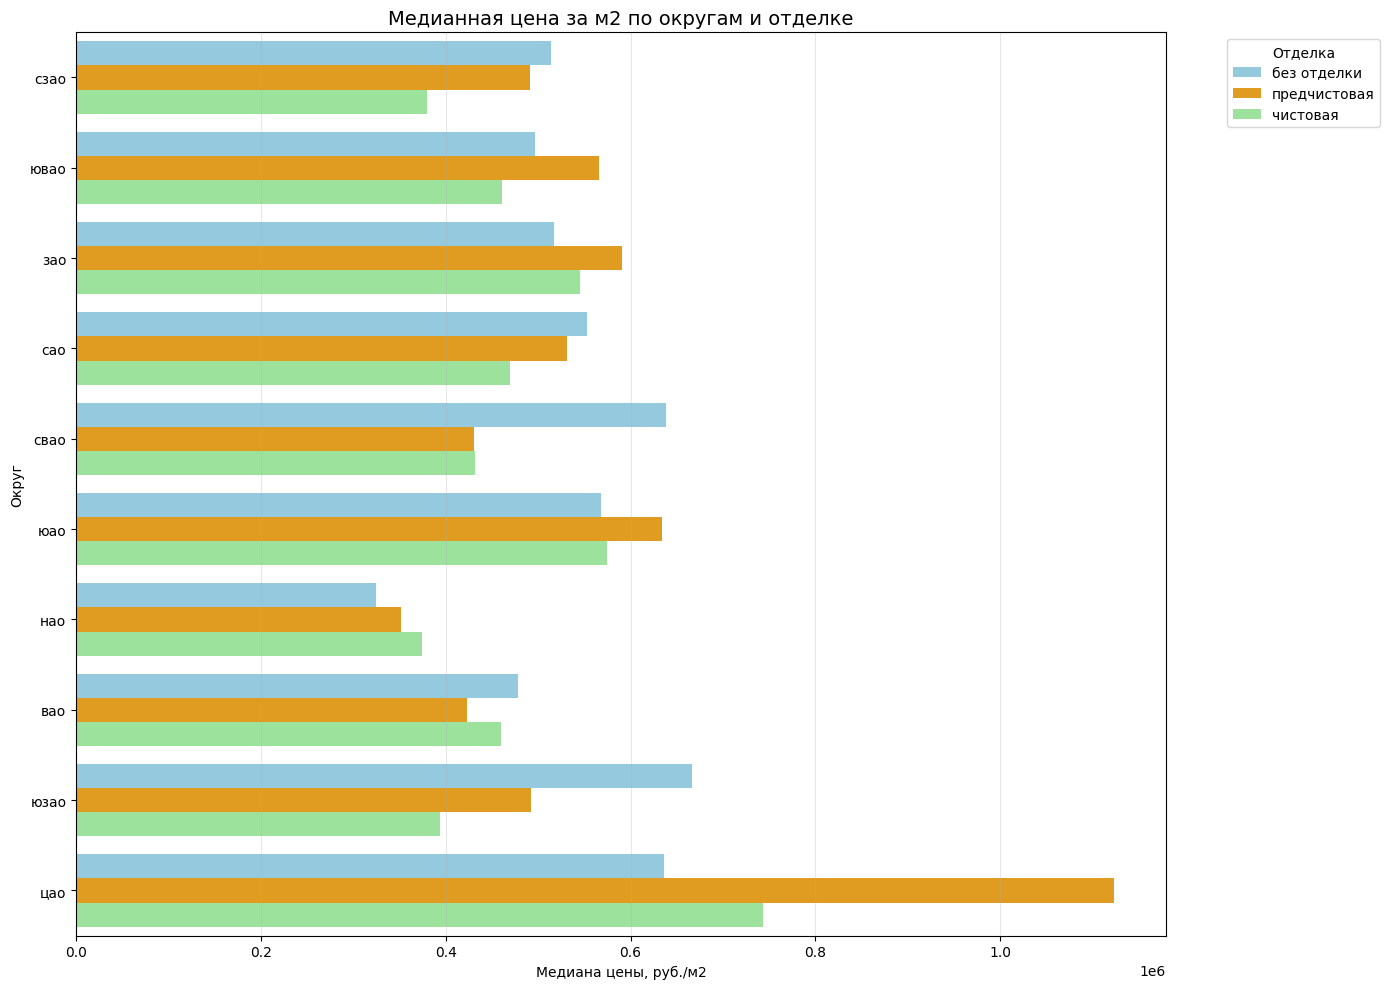

In [338]:
plt.figure(figsize=(14, 10))

# Горизонтальный barplot: y='okrug' (вертикально), x='price_per_sq_m', hue='finishing'
q25 = df_new_buildings['price_per_sq_m'].quantile(0.25)
q75 = df_new_buildings['price_per_sq_m'].quantile(0.75)
sns.barplot(data=df_new_buildings, y='okrug', x='price_per_sq_m',
            hue='finishing', estimator='median', errorbar=None,
            palette=['skyblue', 'orange', 'lightgreen'])

plt.title('Медианная цена за м2 по округам и отделке', fontsize=14)
plt.xlabel('Медиана цены, руб./м2')
plt.ylabel('Округ')
plt.legend(title='Отделка', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Выводы следующие:
- Есть некоторые зависимости от района
- В элитной недвижимости покупатели, скорее всего, будут брать квартиру без отделки
- В остальных сегментах (предположительно) большая часть квартир так или иначе продаётся только без отделки

Судя по разнице в медианной стоимости (в зависимости от района, конечно), иногда может быть выгодно взять пред/чистовую отделку от застройщика, снести её и сделать свою. "Базовая" стоимость квартиры будет ниже, при этом сохраняется возможность сделать качественный ремонт самостоятельно

---

**б) Выгодно ли продавцу вторички делать ремонт и повышать цену продажи?**

In [339]:
df_old_buildings = df[df['new_building'] == 'вторичка']

In [340]:
# Цена за м2
df_old_buildings['price_per_sq_m'] = df_old_buildings['price'] / df_old_buildings['total_area']

# Фильтр выбросов (как раньше)
q25 = df_old_buildings['price_per_sq_m'].quantile(0.25)
q75 = df_old_buildings['price_per_sq_m'].quantile(0.75)
df_old = df_old_buildings[df_old_buildings['price_per_sq_m'].between(q25*0.5, q75*2)].copy()

# Упрощаем repair (группируем редкие категории)
df_old['repair_simple'] = df_old['repair'].replace({
    np.nan: 'без ремонта'
}).fillna('без ремонта')

C:\Users\Никита\AppData\Local\Temp\ipykernel_20184\646107444.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_old_buildings['price_per_sq_m'] = df_old_buildings['price'] / df_old_buildings['total_area']


In [341]:
# Медианная цена за м2 по ремонту
median_prices = df_old.groupby('repair_simple')['price_per_sq_m'].median().round(0)
print("Медианная цена за м2 по типу ремонта:")
print(median_prices)

Медианная цена за м2 по типу ремонта:
repair_simple
без ремонта     396258
дизайнерский    475477
евроремонт      373184
косметический   327687
Name: price_per_sq_m, dtype: float64


Здесь тоже получается немного контринтуитивно - евроремонт и косметический стоят дешевле, чем без ремонта. Возможно, здесь влияние двух факторов: района (помним разницу между ЦАО и ВАО) и года постройки дома (немного косвенно, но всё же: посмотрите на евроремонт 90х-00х :) )

Изучим данные с 1990г

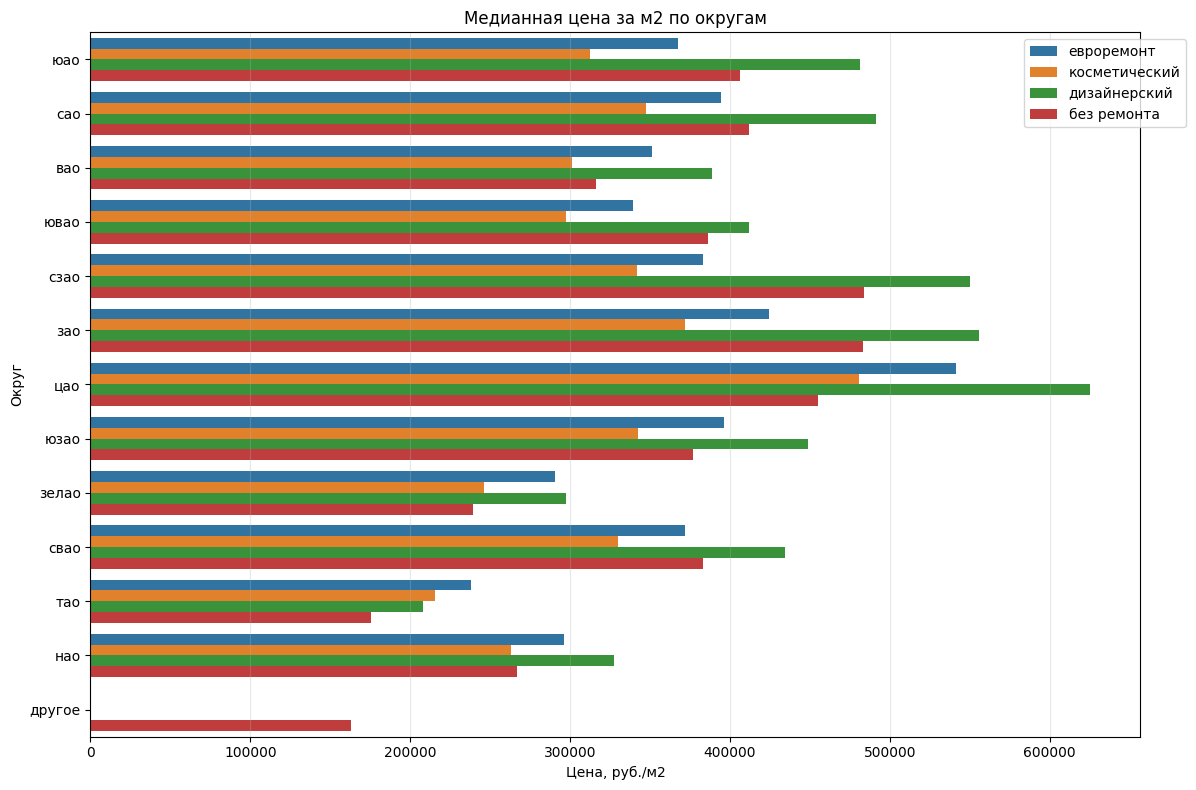

In [342]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df_old, y='okrug', x='price_per_sq_m', hue='repair_simple',
            estimator='median', errorbar=None)
plt.title('Медианная цена за м2 по округам')
plt.xlabel('Цена, руб./м2')
plt.ylabel('Округ')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [343]:
bins = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2026]
labels = ['1990-1994', '1995-1999', '2000-2004', '2005-2009',
          '2010-2014', '2015-2019', '2020-2025']

df_old['construction_period'] = pd.cut(df_old['year_of_construction'],
                                     bins=bins,
                                     labels=labels,
                                     right=False)

print("Объектов в интервалах:")
print(df_old['construction_period'].value_counts().sort_index())

Объектов в интервалах:
construction_period
1990-1994     374
1995-1999     576
2000-2004     852
2005-2009    2764
2010-2014     837
2015-2019    1940
2020-2025    4823
Name: count, dtype: int64


In [344]:
# 0. Pivot table: медиана цены за м2 по ремонту × период
pivot_prices = df_old.groupby(['construction_period', 'repair_simple'], observed=False, as_index=False)['price_per_sq_m'].median().round(0)

# 1. Создаём словарь базовых цен по периодам
base_prices = pivot_prices[pivot_prices['repair_simple'] == 'без ремонта'].set_index('construction_period')['price_per_sq_m'].to_dict()

# 2. Считаем премию для всех строк
pivot_prices['premium_pct'] = pivot_prices.apply(
    lambda row: ((row['price_per_sq_m'] - base_prices[row['construction_period']]) /
                 base_prices[row['construction_period']] * 100)
    if row['repair_simple'] != 'без ремонта' and row['construction_period'] in base_prices
    else 0.0, axis=1
)

# 3. Pivot для heatmap
pivot_premium = pivot_prices[pivot_prices['repair_simple'] != 'без ремонта'].pivot(
    index='construction_period', columns='repair_simple', values='premium_pct'
)

print("Премия за ремонт, %")
pivot_premium

Премия за ремонт, %


repair_simple,дизайнерский,евроремонт,косметический
construction_period,,,
1990-1994,24,18,4
1995-1999,29,16,4
2000-2004,19,10,3
2005-2009,11,-13,-24
2010-2014,22,4,-7
2015-2019,19,-5,-15
2020-2025,20,-13,-20


In [345]:
pivot_prices

,construction_period,repair_simple,price_per_sq_m,premium_pct
0,1990-1994,без ремонта,278290,0
1,1990-1994,дизайнерский,344156,24
2,1990-1994,евроремонт,327706,18
3,1990-1994,косметический,288223,4
4,1995-1999,без ремонта,288462,0
5,1995-1999,дизайнерский,371594,29
6,1995-1999,евроремонт,334201,16
7,1995-1999,косметический,300945,4
8,2000-2004,без ремонта,319753,0
9,2000-2004,дизайнерский,381579,19


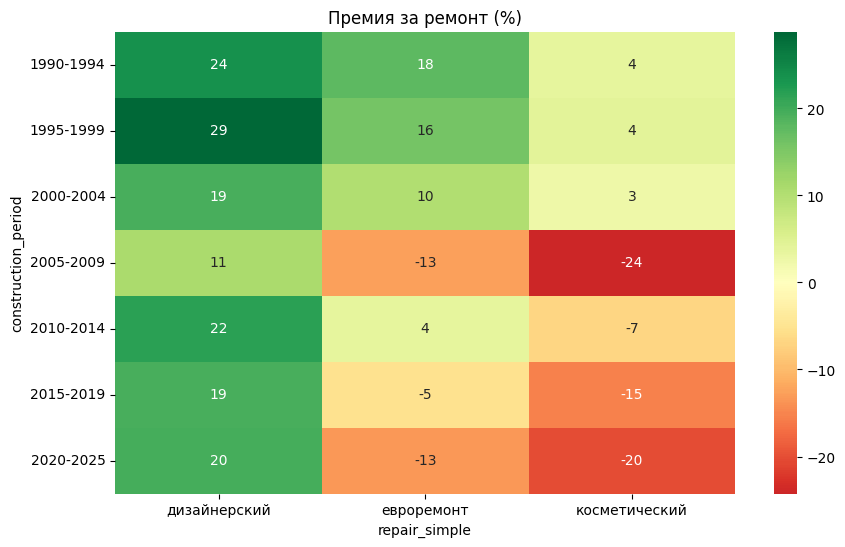

In [346]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_premium.fillna(0), annot=True, cmap='RdYlGn', center=0, fmt='.0f')
plt.title('Премия за ремонт (%)')
plt.show()

Выводы:  
В среднем ситуация такова, что выгоден только дизайнерский ремонт. В более свежих делать косметический и евроремонт нецелесообразно (они относительно "живы"). В старых же квартирах это поможет немного увеличить цену.  
Выгодность дизайнерского ремонта может быть в том, что его делают в премиум-сегменте (вспоминаем, что премиум-новостройки берут без отделки и ремонтируют под себя); а также в том, что словом "дизайнерский" называют в принципе любой красивый ремонт:

In [347]:
df_old.groupby(by='repair_simple', as_index=False)['url'].count()

,repair_simple,url
0,без ремонта,3744
1,дизайнерский,5211
2,евроремонт,4728
3,косметический,5196


## Вопрос 2: Имеют ли апартаменты более низкую (в том же районе) цену, чем обычные квартиры?

In [348]:
df_hyp = df.copy()
df_hyp['price_per_sqm'] = df_hyp['price'] * 1.0 / df_hyp['total_area']

In [349]:
# Медианная цена за м2 по типу жилья
apt_prices = df_hyp.groupby('apartment_newbuilding')['price_per_sqm'].agg(['median', 'count']).round(0)

print("Цена за м2 и объём по типу жилья:")
print(apt_prices)
print(f"\nОбщий объём: {len(df_hyp):,} квартир")

Цена за м2 и объём по типу жилья:
                         median  count
apartment_newbuilding                 
апартаменты вторичка     434967   1926
апартаменты новостройка  419448    700
вторичка                 377155  17115
новостройка              489770   8444

Общий объём: 28,185 квартир


In [350]:
# Базовая цена (обычные квартиры)
base_price = df_hyp['price_per_sqm'].median()

# Премия для апартаментов и пентхаусов
premiums = df_hyp.groupby('apartment_newbuilding')['price_per_sqm'].median()
premium_pct = ((premiums - base_price) / base_price * 100).round(1)

print(f"База (обычные квартиры): {base_price:,.0f} руб/м2")
for apt_type in premiums.index:
    if pd.notna(apt_type):
        prem = premium_pct[apt_type]
        print(f"{apt_type}: {premiums[apt_type]:,.0f} руб/м2 ({prem:+.1f}%)")


База (обычные квартиры): 413,585 руб/м2
апартаменты вторичка: 434,967 руб/м2 (+5.2%)
апартаменты новостройка: 419,448 руб/м2 (+1.4%)
вторичка: 377,155 руб/м2 (-8.8%)
новостройка: 489,770 руб/м2 (+18.4%)


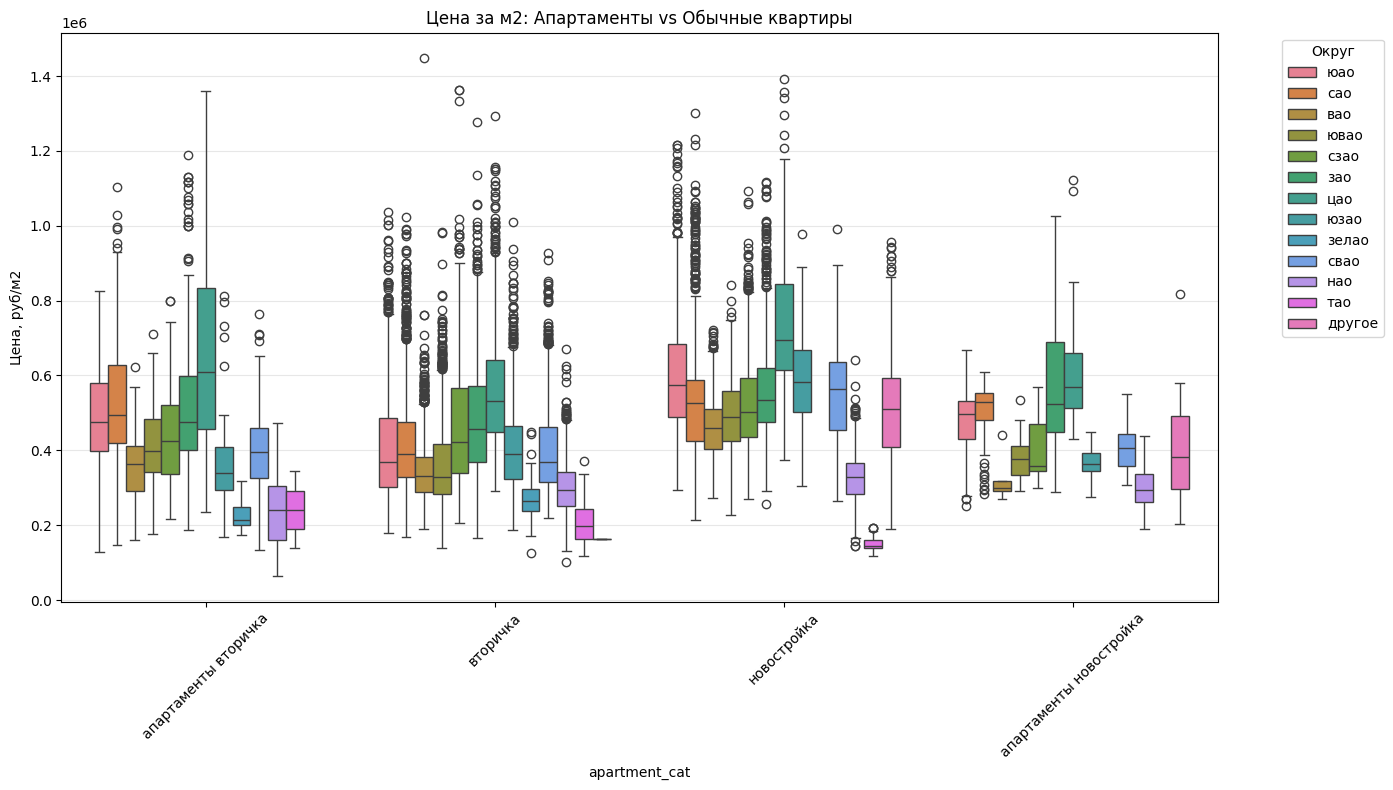

In [351]:
plt.figure(figsize=(14, 8))

# Создаём категорию для графика
df_hyp['apartment_cat'] = df_hyp['apartment_newbuilding'].fillna('Обычная квартира')

sns.boxplot(data=df_hyp, x='apartment_cat', y='price_per_sqm', hue='okrug')
plt.title('Цена за м2: Апартаменты vs Обычные квартиры')
plt.ylabel('Цена, руб/м2')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), title='Округ')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [352]:
# 1. Статистика по округам (безопасный способ)
stats_by_district = df_hyp.groupby(['okrug', 'apartment_cat'])['price_per_sqm'].agg(
    median='median', mean='mean', count='count'
).round(0)

# 2. Reset_index для плоской таблицы
stats_by_district = stats_by_district.reset_index()

print("Статистика по округам:")
print(stats_by_district.head())

Статистика по округам:
    okrug            apartment_cat  median   mean  count
0     вао     апартаменты вторичка  362435 352990    105
1     вао  апартаменты новостройка  300000 324507      5
2     вао                 вторичка  331633 345796   1387
3     вао              новостройка  460825 461063    448
4  другое  апартаменты новостройка  382593 408552     20


In [353]:
# Функция сопоставления базового сегмента
def get_base_segment(apartment_cat):
    if 'апартаменты вторичка' in apartment_cat:
        return 'вторичка'
    elif 'апартаменты новостройка' in apartment_cat:
        return 'новостройка'
    else:
        return None  # Для обычных квартир

# 1. Словарь базовых цен по округам для каждого сегмента
base_prices_vtor = stats_by_district[
    stats_by_district['apartment_cat'] == 'вторичка'
].set_index('okrug')['median'].to_dict()

base_prices_nov = stats_by_district[
    stats_by_district['apartment_cat'] == 'новостройка'
].set_index('okrug')['median'].to_dict()

# 2. Премия для каждого типа апартаментов
premiums = []
for _, row in stats_by_district.iterrows():
    segment = get_base_segment(row['apartment_cat'])
    
    if segment == 'вторичка' and row['okrug'] in base_prices_vtor:
        base = base_prices_vtor[row['okrug']]
        premium = ((row['median'] - base) / base * 100)
        premiums.append({
            'okrug': row['okrug'],
            'apartment_cat': row['apartment_cat'],
            'base_segment': 'вторичка',
            'median_price': row['median'],
            'premium_pct': premium,
            'count': row['count']
        })
    
    elif segment == 'новостройка' and row['okrug'] in base_prices_nov:
        base = base_prices_nov[row['okrug']]
        premium = ((row['median'] - base) / base * 100)
        premiums.append({
            'okrug': row['okrug'],
            'apartment_cat': row['apartment_cat'],
            'base_segment': 'новостройка',
            'median_price': row['median'],
            'premium_pct': premium,
            'count': row['count']
        })

df_premiums = pd.DataFrame(premiums)

print("ПРЕМИЯ АПАРТАМЕНТОВ ПО СЕГМЕНТАМ:")
print(df_premiums.sort_values('premium_pct', ascending=False).head(15))

# 3. Сводная статистика
print("СВОДКА ПО СЕГМЕНТАМ:")
summary = df_premiums.groupby(['base_segment', 'apartment_cat'])['premium_pct'].agg(['mean', 'count']).round(1)
print(summary)

# 4. ТОП по округам
print("\ТОП-5 ОКРУГОВ ПО ПРЕМИИ:")
print(df_premiums.nlargest(5, 'premium_pct')[['okrug', 'apartment_cat', 'base_segment', 'premium_pct', 'count']])


ПРЕМИЯ АПАРТАМЕНТОВ ПО СЕГМЕНТАМ:
   okrug            apartment_cat base_segment  median_price  premium_pct  \
17   юао     апартаменты вторичка     вторичка        475758           29   
8    сао     апартаменты вторичка     вторичка        494151           26   
14   тао     апартаменты вторичка     вторичка        241288           21   
19  ювао     апартаменты вторичка     вторичка        396944           21   
15   цао     апартаменты вторичка     вторичка        609137           14   
0    вао     апартаменты вторичка     вторичка        362435            9   
10  свао     апартаменты вторичка     вторичка        396455            7   
3    зао     апартаменты вторичка     вторичка        476744            4   
12  сзао     апартаменты вторичка     вторичка        425279            1   
9    сао  апартаменты новостройка  новостройка        528371            0   
4    зао  апартаменты новостройка  новостройка        524000           -2   
7    нао  апартаменты новостройка  новостр

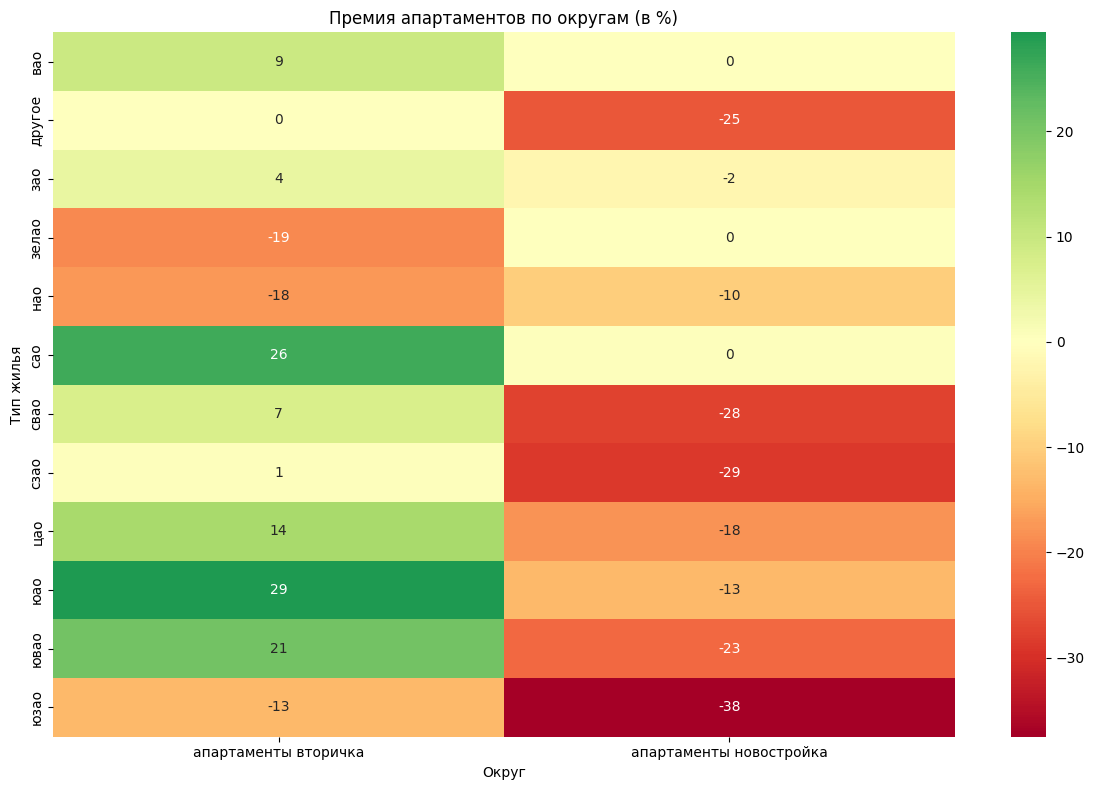

In [354]:
# Pivot только для апартаментов с count > 5
pivot_ready = df_premiums[df_premiums['count'] > 5].pivot_table(
    index='okrug', columns='apartment_cat',
    values='premium_pct', aggfunc='median'
).fillna(0).round(1)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_ready, annot=True, cmap='RdYlGn', center=0, fmt='.0f')
plt.title('Премия апартаментов по округам (в %)')
plt.xlabel('Округ')
plt.ylabel('Тип жилья')
plt.tight_layout()
plt.show()

Выводы:  
Апартаменты (в среднем по Москве) стоят столько же, сколько и обычные квартиры. Однако в разбивке по округам почти везде в новостройках цены на апартаменты ниже на 10-25% (наверное, это можно назвать проявлением парадокса Симпсона).  
Это вызвано несколькими факторами:
- Апартаменты юридически не являются жилыми помещениями, поэтому к ним не предъявляются требования к нормам освещённости, шумоизоляции, социальной инфраструктуре и пр.
- Апартаменты часто возводятся на земле, не предназначенной для жилого строительства
- Налог на имущество и ЖКХ у апартаментов выше

На вторичном рынке цены на апартаменты могут быть выше. Скорее всего, здесь играет роль ремонт (как мы помним, новостройки часто сдаются без ремонта)

## Вопрос 3: Насколько сильно удалённость от метро влияет на цену? Какую премию за близость получает владелец? Сколько теряет, если добираться на метро приходится на машине?
Гипотеза: `fastest_mode == "на машине"` дает дисконт >20% по сравнению с пешей доступностью при том же времени

In [355]:
df_valid_metro = df_hyp[df_hyp['fastest_minutes'].notna()].copy()

df_valid_metro['metro_time_cat'] = pd.cut(df_valid_metro['fastest_minutes'],
                                         bins=[0, 5, 10, 15, 30, 60],
                                         labels=['0-5мин', '5-10мин', '10-15мин', '15-30мин', '30-60мин'])

metro_stats_clean = df_valid_metro.groupby(['metro_time_cat', 'fastest_mode'], observed=False)['price_per_sqm'].agg(
    ['median', 'count']
).round(0).reset_index()

print("Статистика (только с данными о метро):")
print(metro_stats_clean.pivot(index='metro_time_cat', columns='fastest_mode', values='median'))

Статистика (только с данными о метро):
fastest_mode    на машине  пешком
metro_time_cat                   
0-5мин             325581  412879
5-10мин            289983  406321
10-15мин           254955  392562
15-30мин           228766  372093
30-60мин              NaN     NaN


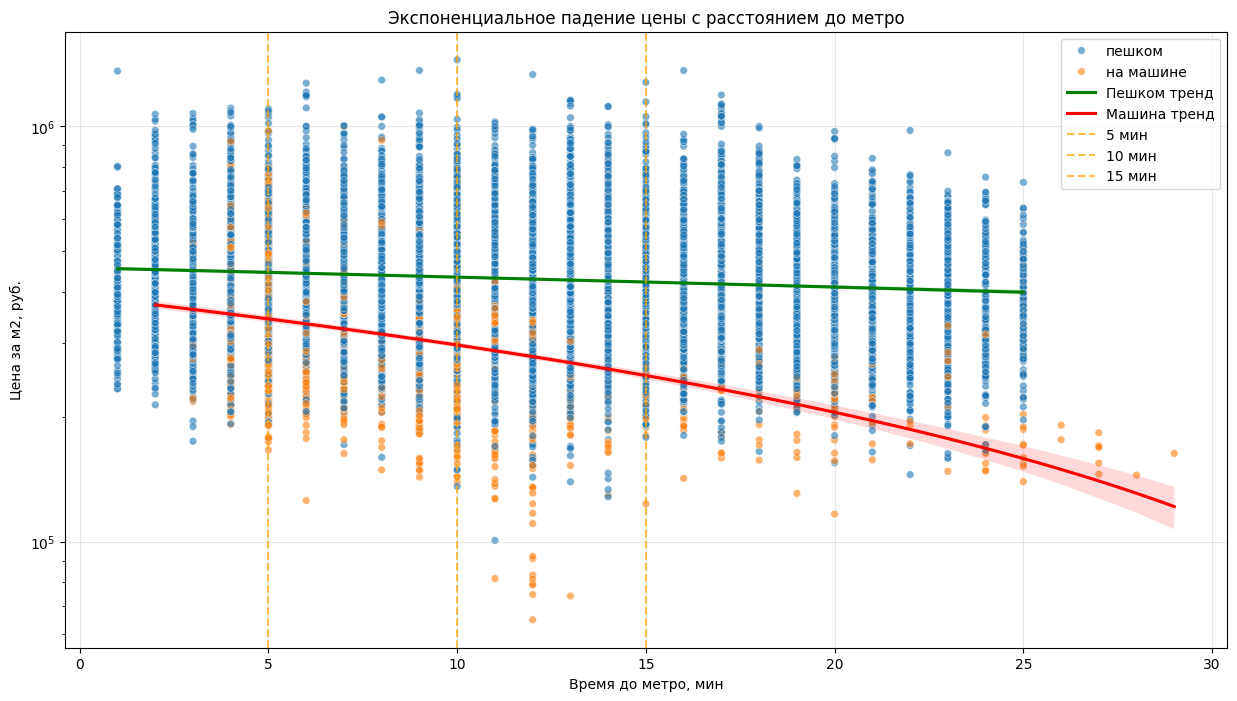

In [356]:
plt.figure(figsize=(15, 8))

# Базовый scatter по времени
sns.scatterplot(data=df_valid_metro, x='fastest_minutes', y='price_per_sqm',
                hue='fastest_mode', alpha=0.6, s=30)

# Нелинейный тренд отдельно для пешком/машина
sns.regplot(data=df_valid_metro[df_valid_metro['fastest_mode'] == 'пешком'],
            x='fastest_minutes', y='price_per_sqm',
            scatter=False, color='green', label='Пешком тренд')
sns.regplot(data=df_valid_metro[df_valid_metro['fastest_mode'] == 'на машине'],
            x='fastest_minutes', y='price_per_sqm',
            scatter=False, color='red', label='Машина тренд')

plt.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='5 мин')
plt.axvline(x=10, color='orange', linestyle='--', alpha=0.7, label='10 мин')
plt.axvline(x=15, color='orange', linestyle='--', alpha=0.7, label='15 мин')
plt.title('Экспоненциальное падение цены с расстоянием до метро')
plt.xlabel('Время до метро, мин')
plt.ylabel('Цена за м2, руб.')
plt.legend()
plt.yscale('log')  # Логарифмическая шкала для цены
plt.grid(True, alpha=0.3)
plt.show()


In [357]:
# База = 15-30мин пешком (валидные данные)
base_clean = df_valid_metro[
    (df_valid_metro['metro_time_cat'] == '15-30мин') &
    (df_valid_metro['fastest_mode'] == 'пешком')
]['price_per_sqm'].median()

for time_cat in df_valid_metro['metro_time_cat'].cat.categories:
    subset = df_valid_metro[(df_valid_metro['metro_time_cat'] == time_cat) & (df_valid_metro['fastest_mode'] == 'пешком')]
    median_clean = subset['price_per_sqm'].median()
    premium_clean = ((median_clean - base_clean) / base_clean * 100).round(1)
    print(f"{time_cat:10}: {median_clean:,.0f} руб/м2 ({premium_clean:+.1f}%) | n={len(subset):,}")

0-5мин    : 412,879 руб/м2 (+11.0%) | n=2,621
5-10мин   : 406,321 руб/м2 (+9.2%) | n=5,368
10-15мин  : 392,562 руб/м2 (+5.5%) | n=4,619
15-30мин  : 372,093 руб/м2 (+0.0%) | n=4,151
30-60мин  : nan руб/м2 (+nan%) | n=0


In [358]:
print("ДИСКОНТ 'НА МАШИНЕ' (только валидные данные):")
car_discount_clean = df_valid_metro.groupby('fastest_mode')['price_per_sqm'].median()
car_vs_walk_clean = ((car_discount_clean['на машине'] - car_discount_clean['пешком']) /
                     car_discount_clean['пешком'] * 100).round(1)
print(f"Машина vs Пешком: {car_vs_walk_clean:+.1f}%")

print(" ПО ПОРОГАМ ВРЕМЕНИ (очищенные данные):")
discount_by_time_clean = metro_stats_clean.pivot(index='metro_time_cat',
                                                columns='fastest_mode',
                                                values='median')
discount_by_time_clean['car_discount_pct'] = ((discount_by_time_clean['на машине'] -
                                             discount_by_time_clean['пешком']) /
                                            discount_by_time_clean['пешком'] * 100).round(1)
print(discount_by_time_clean[['car_discount_pct']].fillna('-'))

ДИСКОНТ 'НА МАШИНЕ' (только валидные данные):
Машина vs Пешком: -26.6%
 ПО ПОРОГАМ ВРЕМЕНИ (очищенные данные):
fastest_mode   car_discount_pct
metro_time_cat                 
0-5мин                      -21
5-10мин                     -29
10-15мин                    -35
15-30мин                    -38
30-60мин                      -


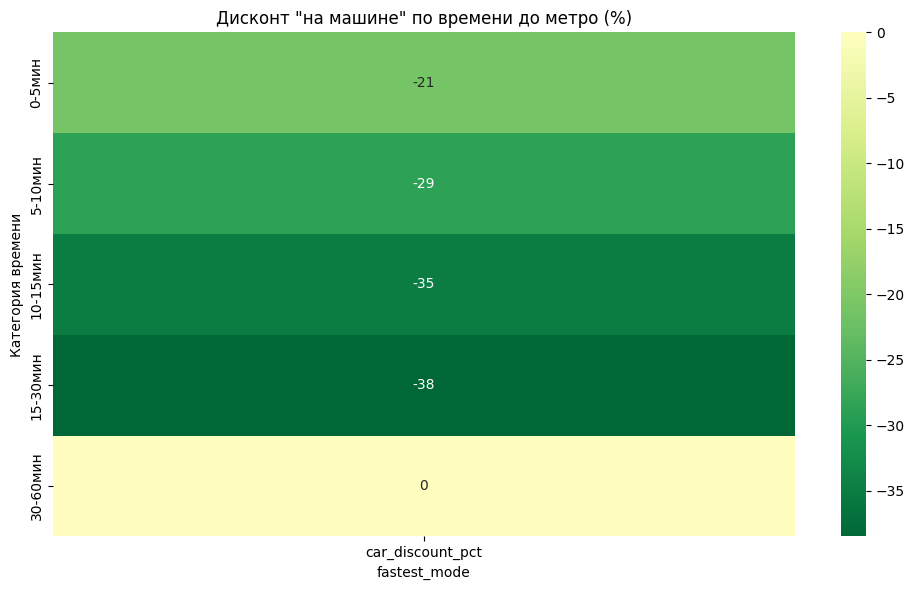

In [359]:
plt.figure(figsize=(10, 6))
sns.heatmap(discount_by_time_clean[['car_discount_pct']].fillna(0),
            annot=True, cmap='RdYlGn_r', center=0, fmt='.0f')
plt.title('Дисконт "на машине" по времени до метро (%)')
plt.ylabel('Категория времени')
plt.tight_layout()
plt.show()

Выводы: Квартиры в пешей доступности (до 10 минут) до метро стоят на 5-10% больше от более удалённых (15+ минут)  
Необходимость добираться на машине (даже до 5 минут) уменьшает цену на ~30%.
Возможно, выгоднее не указывать время до метро на машине в 5 минут, а указать время пешком 15 минут (коэффициент времени пешком для этой "зоны", судя по наблюдениям, примерно х3)  

## Вопрос 4: Как этаж (группа этажей) влияет на цену? Меняется ли это влияние с изменением типа дома (монолит/кирпич/панельный)?

In [360]:
# Относительная позиция этажа (0=1-й, 1=последний)
df_hyp['floor_position'] = df_hyp['floor'] / df_hyp['total_floors']
df_hyp['floor_category'] = pd.cut(df_hyp['floor_position'],
                                 bins=[0, 0.05, 0.2, 0.8, 0.95, 1.0],
                                 labels=['1-й этаж', '2-4 этаж', 'Средние', 'Предпоследний', 'Последний'])

# Проверка данных
print("Распределение по категориям этажей:")
print(df_hyp['floor_category'].value_counts())

Распределение по категориям этажей:
floor_category
Средние          17169
2-4 этаж          4844
Предпоследний     3712
Последний         2312
1-й этаж           146
Name: count, dtype: int64


In [361]:
# Медианная цена по категориям этажей
floor_stats = df_hyp.groupby('floor_category', observed=False)['price_per_sqm'].agg(
    ['median', 'count']
).round(0)

# База = средние этажи
base_floor = floor_stats.loc['Средние', 'median']
floor_premium = ((floor_stats['median'] - base_floor) / base_floor * 100).round(1)

print("Премия по этажам:")
for cat in floor_stats.index:
    prem = floor_premium[cat]
    print(f"{cat:<15}: {floor_stats.loc[cat, 'median']:,.0f} руб/м2 ({prem:+.1f}%) | n={floor_stats.loc[cat, 'count']:,}")

Премия по этажам:
1-й этаж       : 480,589 руб/м2 (+14.1%) | n=146
2-4 этаж       : 400,767 руб/м2 (-4.9%) | n=4,844
Средние        : 421,238 руб/м2 (+0.0%) | n=17,169
Предпоследний  : 417,974 руб/м2 (-0.8%) | n=3,712
Последний      : 375,900 руб/м2 (-10.8%) | n=2,312


In [362]:
# Статистика по типу дома × этажу
house_floor_stats = df_hyp.groupby(['house_type', 'floor_category'], observed=False)['price_per_sqm'].median().unstack().round(0)

print("Премия по типу дома:")
for house in house_floor_stats.index:
    if house not in ['деревянный', 'сталинский']: # исключаем, т.к. слишком мало данных
        print(f"\n{house}:")
        base_house = house_floor_stats.loc[house, 'Средние']
        for floor in house_floor_stats.columns:
            if pd.notna(base_house):
                prem = ((house_floor_stats.loc[house, floor] - base_house) / base_house * 100).round(1)
                print(f"  {floor:<15}: {prem:+.1f}%")

Премия по типу дома:

блочный:
  1-й этаж       : +nan%
  2-4 этаж       : -5.7%
  Средние        : +0.0%
  Предпоследний  : +4.1%
  Последний      : -6.9%

кирпичный:
  1-й этаж       : +nan%
  2-4 этаж       : -7.6%
  Средние        : +0.0%
  Предпоследний  : -0.4%
  Последний      : -7.1%

монолитно-кирпичный:
  1-й этаж       : +9.6%
  2-4 этаж       : -3.5%
  Средние        : +0.0%
  Предпоследний  : +3.9%
  Последний      : +8.2%

монолитный:
  1-й этаж       : +2.3%
  2-4 этаж       : -0.5%
  Средние        : +0.0%
  Предпоследний  : -1.0%
  Последний      : -10.8%

панельный:
  1-й этаж       : +17.9%
  2-4 этаж       : -3.4%
  Средние        : +0.0%
  Предпоследний  : -1.9%
  Последний      : -2.6%


Матрица премии по округам:
floor_category  1-й этаж  2-4 этаж  Средние  Предпоследний  Последний
okrug                                                                
вао                   27        -2        0              6         -6
другое                22        10        0              8         -0
зао                   -3        -1        0              2         -8
зелао                  0        -0        0              5         -2
нао                  -10        -2        0              1         -4
сао                   14        -4        0              2         -7
свао                  -7       -12        0             -2        -10
сзао                   7        -4        0              2         -6
тао                    0         5        0              1        -10
цао                  -16         3        0              1         -7
юао                   22       -12        0             -5        -17
ювао                  34        -8        0              1     

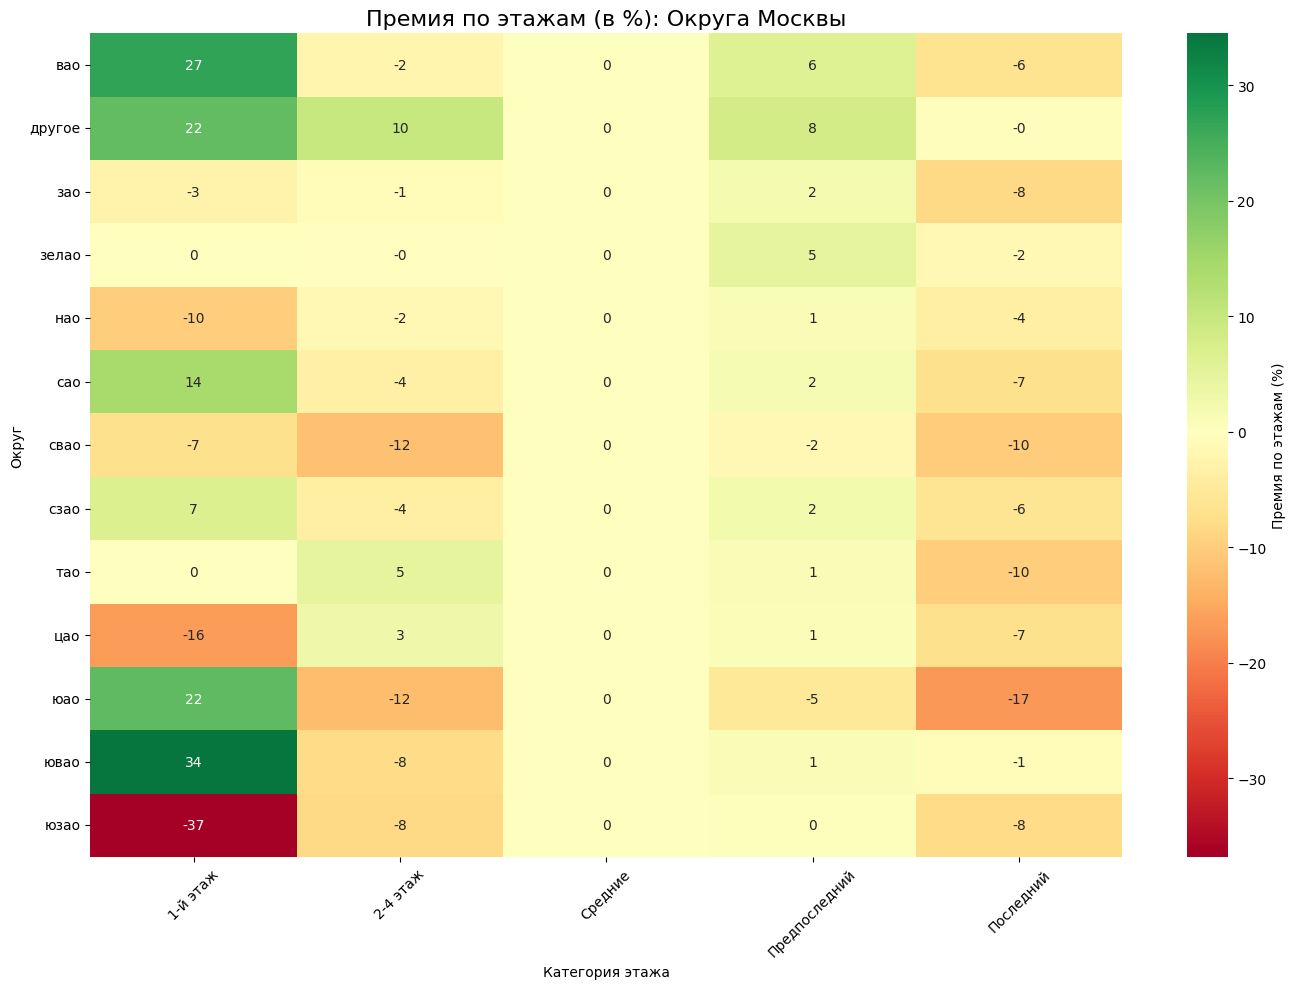

In [363]:
#  Статистика по округам × этажам
district_floor_stats = df_hyp.groupby(['okrug', 'floor_category'], observed=False)['price_per_sqm'].median().unstack().round(0)

# Премия относительно средних этажей внутри округа
pivot_premium = district_floor_stats.copy()
for okr in district_floor_stats.index:
    base = district_floor_stats.loc[okr, 'Средние']
    for floor in district_floor_stats.columns:
        if pd.notna(base):
            pivot_premium.loc[okr, floor] = ((district_floor_stats.loc[okr, floor] - base) / base * 100).round(1)

print("Матрица премии по округам:")
print(pivot_premium.fillna(0))

# Хитмап: Районы × Этажи
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_premium.fillna(0), annot=True, cmap='RdYlGn', center=0, fmt='.0f',
            cbar_kws={'label': 'Премия по этажам (%)'})
plt.title('Премия по этажам (в %): Округа Москвы', fontsize=16)
plt.xlabel('Категория этажа')
plt.ylabel('Округ')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Выводы:  
В разрезе этажей цена сильно зависит от типа дома и района. Например, в кирпичных домах ценятся только средние этажи, как и в ЦАО.
При этом почти по всем районам "не любят" 2-4 этажи и "любят" предпоследний. 1 этаж в разных районах даёт либо высокую премию, либо сильно проседает.

## Общие выводы

### Данные и ход работы
Изначальный набор данных содержал более 65 тысяч строк и 58 колонок-признаков.  
Ключевая для анализа переменная (таргет) – цена квартиры (поле `price`).  
Исследовательский анализ включил в себя:
- Изучение набора данных на предмет пропусков и выбросов, выбор и реализация оптимальной стратегии их обработки (п. 1, 4, 5);
- Приведение типов данных в соответствие с логикой (п. 2);
- Расчёт описательных статистик (п. 3);
- Построение матрицы корреляций, поиск наиболее коррелирующих с целевой переменной полей, выявление мультиколлинеарности (п. 6);
- Визуализация данных, в т.ч. структура по типам признаков и пропускам (п. 7);
- Изучение с точки зрения прикладных вопросов и гипотез (п. 8).  
В ходе EDA было изменено как количество строк (удаление дубликатов, обработка пропусков и выбросов), так и количество столбцов (некоторые признаки объединялись как схожие, некоторые удалялись из-за большой доли пропусков).  

### Описательные статистики
Если рассматривать в общем по набору данных, то средняя цена на квартиру в Москве составляет около 41 млн. руб., медиана при этом – 24 млн. руб.  
Общая площадь составляет около 65 кв.м. в среднем и 58 кв.м. медианно.  
При этом стоит отметить высокий коэффициент асимметрии (~5.6 ед.), что говорит о большом "хвосте" в распределении данных, что может искажать описательные статистики.  
Более подробно см. в соответствующем пункте.

### Качество данных

По типам данных распределение следующее: 18 количественных признаков, 18 категориальных, 10 бинарных, 2 имеют тип дата-время, 2 признака являются геоданными и 8 – текстовыми (смешанными).  
В ходе анализа было выявлено 12 признаков с очень высокой долей пропусков (>80%), 20 – с высокой (40-80%), 4 – со средней (20-40%), 5 – с низкой (0-20%), 17 – без пропусков.  
В целом набор данных изначально собирался "с запасом", т.е. с расчётом на то, что от некоторых признаков в ходе работ будем избавляться/объединять.  
Из-за выбросов важно было правильно выбрать стратегию их обработки: отсечение по IQR теоретически должно было избавлять нас от ~1.5% данных. В нашем же наборе при таком методе терялось порядка 12%. Удаление выбросов на основе z-score и percentile удаляют порядка 1.8% данных, что гораздо меньше.  
В результате был выбран метод percentile, т.к. рассматриваем порядка 98% рынка квартир Москвы, при этом метод не зависит от формы распределения.  
Помимо этого, удаление выбросов повлияло на расчёт корреляции: после обработки зафиксирован рост некоторых значений на 5-10%

Стоит также обратить внимание, что некоторые признаки присущи только новостройкам или только квартирам на вторичном рынке (их распределение примерно 40/60 по всему набору данных). Анализ проводился с учётом этого факта, т.к. это может повлиять как на пропуски, так и на описательные статистики.

### Ключевые зависимости

На основе данных о корреляции выделили следующие признаки, оказывающие наибольшее влияние на цену:
| Признак            | Корреляция    | Значение      |
| ------------------ | ------------- | ------------- |
| total_area         | 0.666         | Общая площадь – очевидно, основной драйвер цены |
| combined_bathroom  | 0.507         | Несколько санузлов часто в более просторных квартирах (мультиколлинеарность) или в квартирах комфорт/бизнес-класса |
| distance_from_mkad | -0.302        | Расстояние до ключевой магистрали города – удобство перемещения сказывается на цене |
| fastest_minutes    | -0.119        | Немного неочевидно по цифрам, но небольшое расстояние до метро даёт прибавку в цене до 20%. При этом необходимость добираться на машине очень негативно влияет на цену |

Признаки living_area и kitchen_area не включены, т.к. они мультиколлинеарны с total_area

### Гипотезы и инсайты

В ходе исследований были обнаружены следующие зависимости:
1. Квартиры без отделки стоят в среднем дороже, чем с отделкой. Вероятно, ключевая причина этому в классе жилья: застройщик строит "серый ключ" комфорт-класса и выше, делая упор на скорость строительства. Также возможная причина – некий ценовой потолок. Логика в том, что на квартиры без отделки можно завысить цену, её будут брать люди, которые планируют делать ремонт (дополнительные траты => деньги у них есть)
2. На вторичном рынке косметический ремонт немного выгоден лишь для старых квартир (годы постройки – 90е и раньше). Евроремонт не имеет смысла у квартир новее 2010, а дизайнерский почти всегда даёт премию в 20-30%
3. Апартаменты в новостройках до 40% дешевле, чем обычные квратиры из-за сниженных требований к расположению и инфраструктуре, а также из-за повышенного налога на имущество и платы за ЖКУ. На вторичном рынке цена варьируется от округа к округу
4. Близость к метро "поднимает" цену в плоть до 20%. Если на метро необходимо добираться на машине - стоимость такой квартиры может быть в 2 раза ниже, чем вблизи
5. В большинстве районов предпочитают средние этажи или ближе к последнему. Стоимость квартиры на первом этаже может сильно отличаться от района к району